In [1]:
# =============================================================================
# LATEX TABLE EXPORT —
import re, unicodedata
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

TEX_OUTDIR = "."
_PENDING = {}             # figure number -> (cellText, colLabels)
_WRITTEN = []

# unicode -> LaTeX, applied to every cell
_UNI = {
    "\u2014": "---", "\u2013": "--", "\u2212": "-",
    "\u00b1": r"$\pm$", "\u2264": r"$\le$", "\u2265": r"$\ge$",
    "\u2248": r"$\approx$", "\u2260": r"$\neq$",
    "\u2191": r"$\uparrow$", "\u2193": r"$\downarrow$",
    "\u2020": r"$\dagger$", "\u2021": r"$\ddagger$",
    "\u22c6": r"$\star$", "\u2605": r"$\star$", "\u00d7": r"$\times$",
    "\u03c1": r"$\rho$", "\u03c4": r"$\tau$", "\u03b2": r"$\beta$",
    "\u03b1": r"$\alpha$", "\u0394": r"$\Delta$", "\u03bc": r"$\mu$",
    "\u2011": "-", "\u00a0": " ", "\u2026": r"$\ldots$",
}
_ESC = {"&": r"\&", "%": r"\%", "#": r"\#", "_": r"\_"}
_NUMRE = re.compile(r"^[+\-]?\d[\d,]*\.?\d*(e[+\-]?\d+)?$", re.I)


def _clean(s):
    s = "" if s is None else str(s)
    for k, v in _UNI.items():
        s = s.replace(k, v)
    # escape specials in text segments only; leave $...$ math untouched
    parts, out = s.split("$"), []
    for i, p in enumerate(parts):
        if i % 2 == 0:                      # outside math
            if "\\" not in p:
                for k, v in _ESC.items():
                    p = p.replace(k, v)
        out.append(p)
    return "$".join(out).strip()


def _is_num(s):
    s = str(s).strip()
    return bool(_NUMRE.match(s)) or s in {"---", "--", ""}


def _colspec(rows, ncol):
    spec = ""
    for j in range(ncol):
        col = [r[j] for r in rows if j < len(r)]
        spec += "r" if col and all(_is_num(c) for c in col) else "l"
    return spec


def _to_latex(cellText, colLabels, label):
    rows = [[_clean(c) for c in row] for row in cellText]
    ncol = max(len(r) for r in rows)
    rows = [r + [""] * (ncol - len(r)) for r in rows]
    hdr = [_clean(c) for c in (colLabels or [])][:ncol]
    hdr += [""] * (ncol - len(hdr))

    out = [r"\begin{table}[t]",
           r"\centering",
           r"\caption{}",
           r"\label{tab:%s}" % label,
           r"\begin{tabular}{%s}" % _colspec(rows, ncol),
           r"\toprule",
           " & ".join(r"\textbf{%s}" % h if h else "" for h in hdr) + r" \\",
           r"\midrule"]
    out += [" & ".join(r) + r" \\" for r in rows]
    out += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    return "\n".join(out)


_orig_table = Axes.table
_orig_savefig = plt.savefig


def _table(self, *a, **kw):
    ct = kw.get("cellText", a[0] if a else None)
    cl = kw.get("colLabels")
    if ct is not None and len(ct) > 0:
        ct = [list(r) for r in ct]          # ndarray / DataFrame -> list of lists
        cl = list(cl) if cl is not None else None
        _PENDING[self.figure.number] = (ct, cl)
    return _orig_table(self, *a, **kw)


def _savefig(fname, *a, **kw):
    res = _orig_savefig(fname, *a, **kw)
    try:
        num = plt.gcf().number
        if num in _PENDING and isinstance(fname, str):
            ct, cl = _PENDING.pop(num)
            stem = re.sub(r"\.(png|pdf|jpg|jpeg|svg|eps)$", "", fname, flags=re.I)
            stem = stem.split("/")[-1]
            path = f"{TEX_OUTDIR}/{stem}.tex"
            with open(path, "w", encoding="utf-8") as f:
                f.write(_to_latex(ct, cl, stem))
            _WRITTEN.append(path)
            print(f"  -> wrote {path}  ({len(ct)} rows)")
    except Exception as e:
        print(f"  !! tex export failed for {fname}: {e}")
    return res


Axes.table = _table
plt.savefig = _savefig
print("LaTeX table export armed. Run All; .tex files appear next to each table PNG.")

LaTeX table export armed. Run All; .tex files appear next to each table PNG.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =============================================================================
# SECTION 0 — ENVIRONMENT SETUP
# =============================================================================

# !pip install -q umap-learn scipy statsmodels

import os, glob, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom

warnings.filterwarnings("ignore")

In [4]:
# -----------------------------------------------------------------------------
# GLOBAL CONFIG
# -----------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11
})

print("Environment initialized with seed =", SEED)

Environment initialized with seed = 42


In [5]:
# =============================================================================
# GLOBAL CONSTANTS
# =============================================================================

CLASSIFIERS = ["LR", "GB", "SVM_RBF"]
METHOD_ORDER = ["PCA", "UMAP", "AE", "SelectKBest", "RFE"]
DATASET_ORDER = [f"D{i}" for i in range(1, 16)]

SPARSE_DATASETS = {"D13"}
RANK_CONSTRAINED = {"D12", "D15"}

In [6]:
# =============================================================================
# SECTION 1 — DATA INGESTION AND VALIDATION
# =============================================================================

DATA_PATH = "./"
EXPECTED_DATASETS = set(DATASET_ORDER)

files = sorted(glob.glob(os.path.join(DATA_PATH, "D*_raw_results.csv")))

assert len(files) == 15, f"Expected 15 dataset files, found {len(files)}.\n{files}"

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["__source_file__"] = os.path.basename(f)
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)

# -----------------------------------------------------------------------------
# SCHEMA VALIDATION
# -----------------------------------------------------------------------------
REQUIRED_COLUMNS = {
    "dataset_id", "method", "classifier",
    "retention_ratio_requested", "accuracy",
    "status", "k_used"
}

missing = REQUIRED_COLUMNS - set(raw.columns)
assert not missing, f"Missing required columns: {missing}"

# -----------------------------------------------------------------------------
# DATASET COMPLETENESS
# -----------------------------------------------------------------------------
found = set(raw["dataset_id"].unique())
assert found == EXPECTED_DATASETS, (
    f"Dataset mismatch.\nExpected: {EXPECTED_DATASETS}\nFound: {found}"
)

# -----------------------------------------------------------------------------
# STATUS VALIDATION
# -----------------------------------------------------------------------------
status_counts = raw["status"].value_counts()
assert "OK" in status_counts, "No successful runs found."

n_failed = len(raw) - status_counts.get("OK", 0)
assert n_failed == 0, (
    f"{n_failed} failed runs detected.\n{status_counts}"
)

print("Data ingestion complete.")

Data ingestion complete.


In [7]:
# =============================================================================
# SECTION 2 — METHOD NORMALIZATION (PCA vs SVD)
# =============================================================================

def normalize_method(row):
    if row["method"] == "PCA_or_SVD":
        return "TruncatedSVD" if row["dataset_id"] in SPARSE_DATASETS else "PCA"
    return row["method"]

raw["method"] = raw.apply(normalize_method, axis=1)

print("Method normalization complete.")

Method normalization complete.


In [8]:
# =============================================================================
# SECTION 3 — RETENTION SENSITIVITY (RS COMPUTATION)
# =============================================================================
# RS = A(0.9) − A(0.1)

EPS = 0.002
rows = []

ok = raw[raw["status"] == "OK"].copy()

for dataset in sorted(ok["dataset_id"].unique()):
    sub = ok[ok["dataset_id"] == dataset]

    for method in sorted(sub["method"].unique()):
        for clf in sorted(sub["classifier"].unique()):

            mc = sub[(sub["method"] == method) & (sub["classifier"] == clf)]

            a90 = mc.loc[
                np.isclose(mc["retention_ratio_requested"], 0.90),
                "accuracy"
            ].mean()

            a10 = mc.loc[
                np.isclose(mc["retention_ratio_requested"], 0.10),
                "accuracy"
            ].mean()

            if np.isnan(a90) or np.isnan(a10):
                continue

            rs = round(a90 - a10, 4)

            if rs > EPS:
                sign = 1
            elif rs < -EPS:
                sign = -1
            else:
                sign = 0

            rows.append({
                "Dataset": dataset,
                "Method": method,
                "Classifier": clf,
                "RS": rs,
                "Sign": sign
            })

df = pd.DataFrame(rows)

assert len(df) > 0, "RS computation failed — empty output."

print("RS computation complete.")
print("Total entries:", len(df))

RS computation complete.
Total entries: 225


In [9]:
# =============================================================================
# SECTION 4 — SPLIT METHODS (HANDLE SVD SEPARATELY)
# =============================================================================

df_main = df[df["Method"] != "TruncatedSVD"]
df_svd  = df[df["Method"] == "TruncatedSVD"]

In [10]:
# =============================================================================
# SECTION 5 — STRUCTURAL CONSISTENCY ANALYSIS
# =============================================================================

# Fixed dataset order for reproducibility
DATASET_ORDER = [f"D{i}" for i in range(1, 16)]

summary = []

for did in DATASET_ORDER:
    sub = df_main[df_main["Dataset"] == did]

    if sub.empty:
        continue

    n_pos = (sub["Sign"] == 1).sum()
    n_neg = (sub["Sign"] == -1).sum()

    n = n_pos + n_neg
    dom = max(n_pos, n_neg)

    ratio = dom / n if n else np.nan
    p = binom.sf(dom - 1, n, 0.5) if n else np.nan

    summary.append({
        "Dataset": did,
        "Agreement_Ratio": round(ratio, 4),
        "p_value": round(p, 6),
        "Rank_Constrained": did in RANK_CONSTRAINED
    })

summary_df = pd.DataFrame(summary)

# Ensure consistent ordering in output
summary_df["Dataset"] = pd.Categorical(
    summary_df["Dataset"],
    categories=DATASET_ORDER,
    ordered=True
)

summary_df = summary_df.sort_values("Dataset").reset_index(drop=True)

print("\nSTRUCTURAL CONSISTENCY SUMMARY")
print(summary_df)


STRUCTURAL CONSISTENCY SUMMARY
   Dataset  Agreement_Ratio   p_value  Rank_Constrained
0       D1           0.9333  0.000488             False
1       D2           0.7857  0.028687             False
2       D3           1.0000  0.000061             False
3       D4           0.8333  0.019287             False
4       D5           0.8333  0.109375             False
5       D6           1.0000  0.000061             False
6       D7           0.9286  0.000916             False
7       D8           1.0000  0.000031             False
8       D9           1.0000  0.000061             False
9      D10           0.8571  0.006470             False
10     D11           0.7500  0.312500             False
11     D12              NaN       NaN              True
12     D13           0.8750  0.035156             False
13     D14           0.7273  0.113281             False
14     D15              NaN       NaN              True


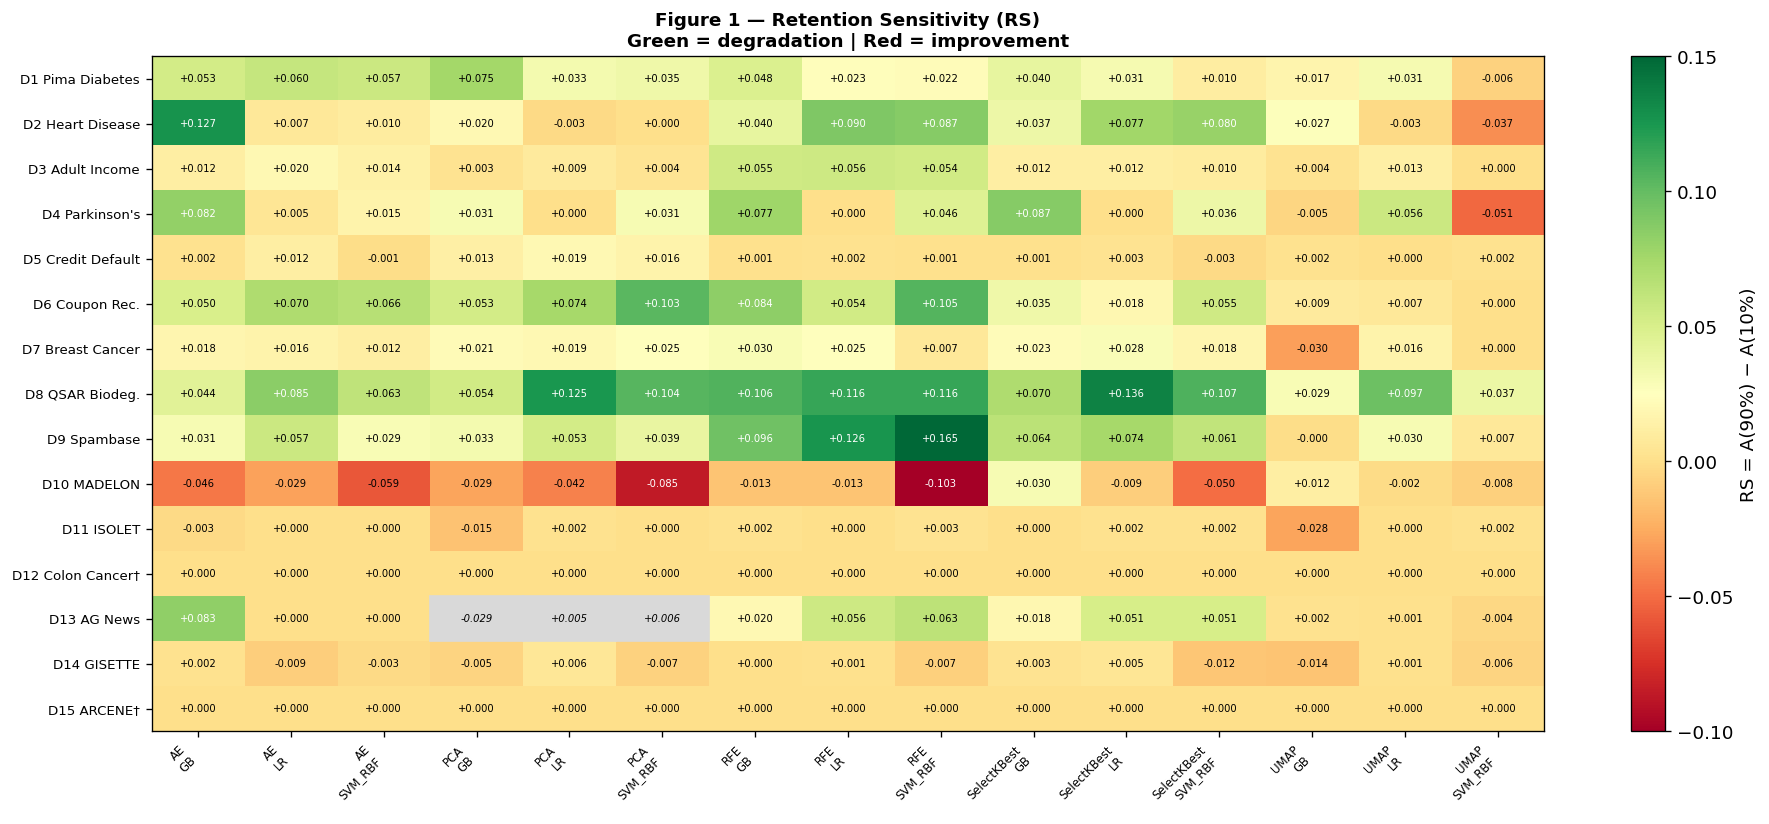


Saved: figure1_final.png


In [11]:
# =============================================================================
# SECTION 6 — HEATMAP (FIGURE 1)
# =============================================================================

# -----------------------------------------------------------------------------
# DATASET LABELS
# -----------------------------------------------------------------------------
DATASETS = {
    "D1":  ("Pima Diabetes",      "Healthcare"),
    "D2":  ("Heart Disease",      "Healthcare"),
    "D3":  ("Adult Income",       "Socioeconomic"),
    "D4":  ("Parkinson's",        "Healthcare"),
    "D5":  ("Credit Default",     "Finance"),
    "D6":  ("Coupon Rec.",        "Business"),
    "D7":  ("Breast Cancer",      "Healthcare"),
    "D8":  ("QSAR Biodeg.",       "Chemistry"),
    "D9":  ("Spambase",           "Comp. Sci."),
    "D10": ("MADELON",            "Synthetic"),
    "D11": ("ISOLET",             "Speech"),
    "D12": ("Colon Cancer†",      "Genomics"),
    "D13": ("AG News",            "Text Mining"),
    "D14": ("GISETTE",            "Vision"),
    "D15": ("ARCENE†",            "Proteomics"),
}

# -----------------------------------------------------------------------------
# PIVOT
# -----------------------------------------------------------------------------
pivot = df_main.pivot_table(
    index="Dataset",
    columns=["Method", "Classifier"],
    values="RS"
)

pivot = pivot.reindex([f"D{i}" for i in range(1,16)])

# -----------------------------------------------------------------------------
# SVD LOOKUP
# -----------------------------------------------------------------------------
svd_lookup = {}
for _, row in df_svd.iterrows():
    svd_lookup[(row["Dataset"], row["Classifier"])] = row["RS"]

# -----------------------------------------------------------------------------
# PLOT
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16,7))

im = ax.imshow(
    pivot.values,
    cmap="RdYlGn",
    aspect="auto",
    vmin=-0.1,
    vmax=0.15
)

# -----------------------------------------------------------------------------
# AXES
# -----------------------------------------------------------------------------
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(
    [f"{m}\n{c}" for m, c in pivot.columns],
    rotation=45, ha="right", fontsize=7
)

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(
    [f"{d} {DATASETS[d][0]}" for d in pivot.index],
    fontsize=8
)

# -----------------------------------------------------------------------------
# ANNOTATIONS
# -----------------------------------------------------------------------------
for i, dataset in enumerate(pivot.index):
    for j, (method, clf) in enumerate(pivot.columns):

        val = pivot.values[i, j]

        # --- D13 PCA SPECIAL CASE ---
        if dataset == "D13" and method == "PCA":

            # Gray mask
            ax.add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                color="#D9D9D9",
                zorder=2
            ))

            # Overlay SVD value
            svd_val = svd_lookup.get((dataset, clf), np.nan)

            if not np.isnan(svd_val):
                ax.text(
                    j, i, f"{svd_val:+.3f}",
                    ha="center", va="center",
                    fontsize=6,
                    fontstyle="italic",
                    color="black",
                    zorder=3
                )

        # --- NORMAL CELLS ---
        elif not np.isnan(val):
            ax.text(
                j, i, f"{val:+.3f}",
                ha="center", va="center",
                fontsize=6,
                color="black" if abs(val) < 0.08 else "white"
            )

# -----------------------------------------------------------------------------
# FINAL STYLING
# -----------------------------------------------------------------------------
plt.colorbar(im, ax=ax, label="RS = A(90%) − A(10%)")

ax.set_title(
    "Figure 1 — Retention Sensitivity (RS)\n"
    "Green = degradation | Red = improvement",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("figure1_final.png", dpi=150)
plt.show()

print("\nSaved: figure1_final.png")

In [12]:
# =============================================================================
#  NUMERICAL VERIFICATION OF STRUCTURAL CONSISTENCY (SECTION 3.2)
# =============================================================================

EPS = 0.002
DATASET_ORDER = [f"D{i}" for i in range(1, 16)]
EXCLUDED = {"D12", "D15"}

results = []

for did in DATASET_ORDER:
    if did in EXCLUDED:
        continue

    sub = df_main[df_main["Dataset"] == did]

    # Exclude near-flat configurations (|RS| ≤ ε)
    valid = sub[np.abs(sub["RS"]) > EPS]

    n_pos = (valid["RS"] > EPS).sum()
    n_neg = (valid["RS"] < -EPS).sum()
    n = n_pos + n_neg

    if n == 0:
        ratio = np.nan
        p = np.nan
    else:
        dom = max(n_pos, n_neg)
        ratio = dom / n
        p = binom.sf(dom - 1, n, 0.5)

    results.append({
        "Dataset": did,
        "n_pos": n_pos,
        "n_neg": n_neg,
        "n_total": n,
        "Agreement_Ratio": ratio,
        "p_value": p
    })

df_check = pd.DataFrame(results)

# -----------------------------------------------------------------------------
# SUMMARY METRICS
# -----------------------------------------------------------------------------

strong = df_check[df_check["Agreement_Ratio"] >= 0.8]
moderate = df_check[
    (df_check["Agreement_Ratio"] >= 0.6) &
    (df_check["Agreement_Ratio"] < 0.8)
]
weak = df_check[df_check["Agreement_Ratio"] < 0.6]

mean_ratio = df_check["Agreement_Ratio"].mean()
perfect = df_check[df_check["Agreement_Ratio"] == 1.0]["Dataset"].tolist()
significant = df_check[df_check["p_value"] < 0.05]

# -----------------------------------------------------------------------------
# OUTPUT
# -----------------------------------------------------------------------------

print("\nSTRUCTURAL CONSISTENCY RESULTS")
print(df_check)

print("\nSUMMARY")
print(f"Valid datasets: {len(df_check)}")
print(f"Strong (≥0.8): {len(strong)}")
print(f"Moderate (0.6–0.8): {len(moderate)}")
print(f"Weak (<0.6): {len(weak)}")
print(f"Mean agreement ratio: {round(mean_ratio, 3)}")
print(f"Perfect agreement datasets: {sorted(perfect)}")
print(f"Significant datasets (p < 0.05): {sorted(significant['Dataset'].tolist())}")

# -----------------------------------------------------------------------------
# CLAIM VERIFICATION
# -----------------------------------------------------------------------------

# Dataset count
assert len(df_check) == 13

# Consistency categories
assert len(strong) == 10
assert len(moderate) == 3
assert len(weak) == 0

# Mean agreement ratio
assert abs(mean_ratio - 0.882) < 0.01

# Perfect agreement datasets
assert set(perfect) == {"D3", "D6", "D8", "D9"}

# MADELON (D10) directional consistency (negative RS dominance)
d10 = df_check[df_check["Dataset"] == "D10"].iloc[0]
assert d10["n_neg"] > d10["n_pos"]

# Statistical significance count
assert len(significant) == 10

# Specific cases
d5 = df_check[df_check["Dataset"] == "D5"].iloc[0]
d2 = df_check[df_check["Dataset"] == "D2"].iloc[0]

assert d5["Agreement_Ratio"] == 0.833 or abs(d5["Agreement_Ratio"] - 0.833) < 0.01
assert d5["p_value"] > 0.05

assert abs(d2["Agreement_Ratio"] - 0.786) < 0.01
assert d2["p_value"] < 0.05

print("\nAll numerical results in Section 3.2 are consistent with the computed agreement ratios and statistical tests.")


STRUCTURAL CONSISTENCY RESULTS
   Dataset  n_pos  n_neg  n_total  Agreement_Ratio   p_value
0       D1     14      1       15         0.933333  0.000488
1       D2     11      3       14         0.785714  0.028687
2       D3     14      0       14         1.000000  0.000061
3       D4     10      2       12         0.833333  0.019287
4       D5      5      1        6         0.833333  0.109375
5       D6     14      0       14         1.000000  0.000061
6       D7     13      1       14         0.928571  0.000916
7       D8     15      0       15         1.000000  0.000031
8       D9     14      0       14         1.000000  0.000061
9      D10      2     12       14         0.857143  0.006470
10     D11      1      3        4         0.750000  0.312500
11     D13      7      1        8         0.875000  0.035156
12     D14      3      8       11         0.727273  0.113281

SUMMARY
Valid datasets: 13
Strong (≥0.8): 10
Moderate (0.6–0.8): 3
Weak (<0.6): 0
Mean agreement ratio: 0.886
Per

In [13]:
# =============================================================================
# NUMERICAL VERIFICATION OF FAILURE MODES (SECTION 3.4)
# =============================================================================

EPS = 0.002

# -----------------------------------------------------------------------------
# A1 — COMPRESSION-AS-REGULARIZATION (D10)
# -----------------------------------------------------------------------------

d10 = raw[(raw["dataset_id"] == "D10") & (raw["status"] == "OK")]

acc_10 = d10.loc[np.isclose(d10["retention_ratio_requested"], 0.10), "accuracy"].mean()
acc_90 = d10.loc[np.isclose(d10["retention_ratio_requested"], 0.90), "accuracy"].mean()

improvement_pp = (acc_10 - acc_90) * 100

count_improve = 0
count_total = 0

for m in d10["method"].unique():
    for clf in d10["classifier"].unique():
        mc = d10[(d10["method"] == m) & (d10["classifier"] == clf)]

        a10 = mc.loc[np.isclose(mc["retention_ratio_requested"], 0.10), "accuracy"].mean()
        a90 = mc.loc[np.isclose(mc["retention_ratio_requested"], 0.90), "accuracy"].mean()

        if not np.isnan(a10) and not np.isnan(a90):
            count_total += 1
            if a10 > a90:
                count_improve += 1

print("\nA1 — COMPRESSION-AS-REGULARIZATION (D10)")
print(f"Mean @10%: {round(acc_10,3)} | Mean @90%: {round(acc_90,3)}")
print(f"Improvement: {round(improvement_pp,2)} pp")
print(f"Configs improving: {count_improve}/{count_total}")

# Assertions
assert abs(acc_10 - 0.628) < 0.01
assert abs(acc_90 - 0.598) < 0.01
assert abs(improvement_pp - 2.97) < 0.5
assert count_improve == 13
assert count_total == 15


# -----------------------------------------------------------------------------
# A2 — FULL RANK COLLAPSE (D12, D15)
# -----------------------------------------------------------------------------

def keff(dataset):
    return sorted(
        raw[(raw["dataset_id"] == dataset) & (raw["status"] == "OK")]["k_used"].unique()
    )

k_d12 = keff("D12")
k_d15 = keff("D15")

print("\nA2 — FULL COLLAPSE")
print("D12 k_eff:", k_d12)
print("D15 k_eff:", k_d15)

assert len(k_d12) == 1 and k_d12[0] == 48
assert len(k_d15) == 1 and k_d15[0] == 159


# -----------------------------------------------------------------------------
# A2 — PARTIAL RANK CONSTRAINT (D11)
# -----------------------------------------------------------------------------

d11 = raw[(raw["dataset_id"] == "D11") & (raw["status"] == "OK")].copy()

d = 617  # ISOLET dimensionality
d11["k_req"] = np.floor(d11["retention_ratio_requested"] * d).astype(int)
d11["k_eff"] = d11["k_used"]

agg = (
    d11.groupby("retention_ratio_requested")
    .agg(k_req=("k_req", "max"),
         k_eff=("k_eff", "max"))
    .reset_index()
    .sort_values("retention_ratio_requested")
)

print("\nA2 — PARTIAL CONSTRAINT (D11)")
print(agg)

# Split regimes
capped = agg[agg["k_eff"] < agg["k_req"]]
uncapped = agg[agg["k_eff"] == agg["k_req"]]

# Assertions
assert agg["k_eff"].nunique() > 1
assert len(capped) > 0
assert len(uncapped) > 0

rank_bound = agg["k_eff"].max()

# Capped regime: k_req exceeds bound
assert (capped["k_req"] > rank_bound).all()

# Uncapped regime: within bound
assert (uncapped["k_req"] <= rank_bound).all()

print("\nSection 3.4 verification passed.")


A1 — COMPRESSION-AS-REGULARIZATION (D10)
Mean @10%: 0.628 | Mean @90%: 0.598
Improvement: 2.97 pp
Configs improving: 13/15

A2 — FULL COLLAPSE
D12 k_eff: [np.int64(48)]
D15 k_eff: [np.int64(159)]

A2 — PARTIAL CONSTRAINT (D11)
   retention_ratio_requested  k_req  k_eff
0                       0.10     61     61
1                       0.25    154    154
2                       0.50    308    308
3                       0.75    462    462
4                       0.90    555    479

Section 3.4 verification passed.


In [14]:
# =============================================================================
# NUMERICAL VERIFICATION OF EMPIRICAL TAXONOMY (SECTION 3.5)
# =============================================================================

# -----------------------------------------------------------------------------
# STEP 1 — COMPUTE DATASET-LEVEL RS (mean across methods/classifiers)
# -----------------------------------------------------------------------------

rs_dataset = (
    df.groupby("Dataset")["RS"]
    .mean()
    .reset_index()
    .sort_values("RS", ascending=False)
)

print("\nDATASET-LEVEL RS")
print(rs_dataset)

# -----------------------------------------------------------------------------
# STEP 2 — IDENTIFY NATURAL GAPS (SORTED DIFFERENCES)
# -----------------------------------------------------------------------------

rs_values = rs_dataset["RS"].values
gaps = np.diff(np.sort(rs_values))

print("\nSORTED RS VALUES:", np.round(np.sort(rs_values), 4))
print("GAPS BETWEEN VALUES:", np.round(gaps, 4))

# -----------------------------------------------------------------------------
# STEP 3 — CLASSIFICATION BASED ON THRESHOLDS
# -----------------------------------------------------------------------------

def classify(rs):
    if rs > 0.03:
        return "Type I"
    elif rs > 0.005:
        return "Type II"
    else:
        return "Type III"

rs_dataset["Type"] = rs_dataset["RS"].apply(classify)

# -----------------------------------------------------------------------------
# STEP 4 — GROUPS
# -----------------------------------------------------------------------------

type_I = rs_dataset[rs_dataset["Type"] == "Type I"]["Dataset"].tolist()
type_II = rs_dataset[rs_dataset["Type"] == "Type II"]["Dataset"].tolist()
type_III = rs_dataset[rs_dataset["Type"] == "Type III"]["Dataset"].tolist()

print("\nTYPE I:", type_I)
print("TYPE II:", type_II)
print("TYPE III:", type_III)

# -----------------------------------------------------------------------------
# STEP 5 — RS RANGES
# -----------------------------------------------------------------------------

def rs_range(datasets):
    vals = rs_dataset[rs_dataset["Dataset"].isin(datasets)]["RS"]
    return vals.min(), vals.max()

r1 = rs_range(type_I)
r2 = rs_range(type_II)
r3 = rs_range(type_III)

print("\nRS RANGES")
print("Type I:", np.round(r1, 4))
print("Type II:", np.round(r2, 4))
print("Type III:", np.round(r3, 4))

# -----------------------------------------------------------------------------
# STEP 6 — CLAIM VERIFICATION
# -----------------------------------------------------------------------------

# Counts
assert len(type_I) == 5
assert len(type_II) == 4
assert len(type_III) == 6

# Exact membership
assert set(type_I) == {"D1", "D2", "D6", "D8", "D9"}
assert set(type_II) == {"D3", "D4", "D7", "D13"}
assert set(type_III) == {"D5", "D10", "D11", "D12", "D14", "D15"}

# Threshold correctness
assert (rs_dataset[rs_dataset["Type"] == "Type I"]["RS"] > 0.03).all()
assert (
    (rs_dataset[rs_dataset["Type"] == "Type II"]["RS"] > 0.005) &
    (rs_dataset[rs_dataset["Type"] == "Type II"]["RS"] <= 0.03)
).all()
assert (rs_dataset[rs_dataset["Type"] == "Type III"]["RS"] <= 0.005).all()

# Range checks (approximate, as in paper)
assert r1[0] > 0.03
assert 0.015 <= r2[0] <= 0.03
assert r3[1] <= 0.005

# Special cases
d10 = rs_dataset[rs_dataset["Dataset"] == "D10"]["RS"].values[0]
assert d10 < 0  # compression benefit

d12 = rs_dataset[rs_dataset["Dataset"] == "D12"]["RS"].values[0]
d15 = rs_dataset[rs_dataset["Dataset"] == "D15"]["RS"].values[0]
assert abs(d12) < 0.005
assert abs(d15) < 0.005

print("\nSection 3.5 verification passed.")


DATASET-LEVEL RS
   Dataset        RS
13      D8  0.085873
14      D9  0.057727
11      D6  0.052287
7       D2  0.037127
0       D1  0.035333
9       D4  0.027360
4      D13  0.021547
8       D3  0.018507
12      D7  0.015093
10      D5  0.004567
3      D12  0.000000
6      D15  0.000000
2      D11 -0.002320
5      D14 -0.003033
1      D10 -0.029673

SORTED RS VALUES: [-0.0297 -0.003  -0.0023  0.      0.      0.0046  0.0151  0.0185  0.0215
  0.0274  0.0353  0.0371  0.0523  0.0577  0.0859]
GAPS BETWEEN VALUES: [0.0266 0.0007 0.0023 0.     0.0046 0.0105 0.0034 0.003  0.0058 0.008
 0.0018 0.0152 0.0054 0.0281]

TYPE I: ['D8', 'D9', 'D6', 'D2', 'D1']
TYPE II: ['D4', 'D13', 'D3', 'D7']
TYPE III: ['D5', 'D12', 'D15', 'D11', 'D14', 'D10']

RS RANGES
Type I: [0.0353 0.0859]
Type II: [0.0151 0.0274]
Type III: [-0.0297  0.0046]

Section 3.5 verification passed.


Table 1 — Type Assignment (from RS taxonomy)
  D1     Type I
  D2     Type I
  D3     Type II
  D4     Type II
  D5     Type III
  D6     Type I
  D7     Type II
  D8     Type I
  D9     Type I
  D10    Type III
  D11    Type III
  D12    Type III †  ← rank-constrained
  D13    Type II
  D14    Type III
  D15    Type III †  ← rank-constrained
  -> wrote ./table1_dataset_inventory.tex  (15 rows)


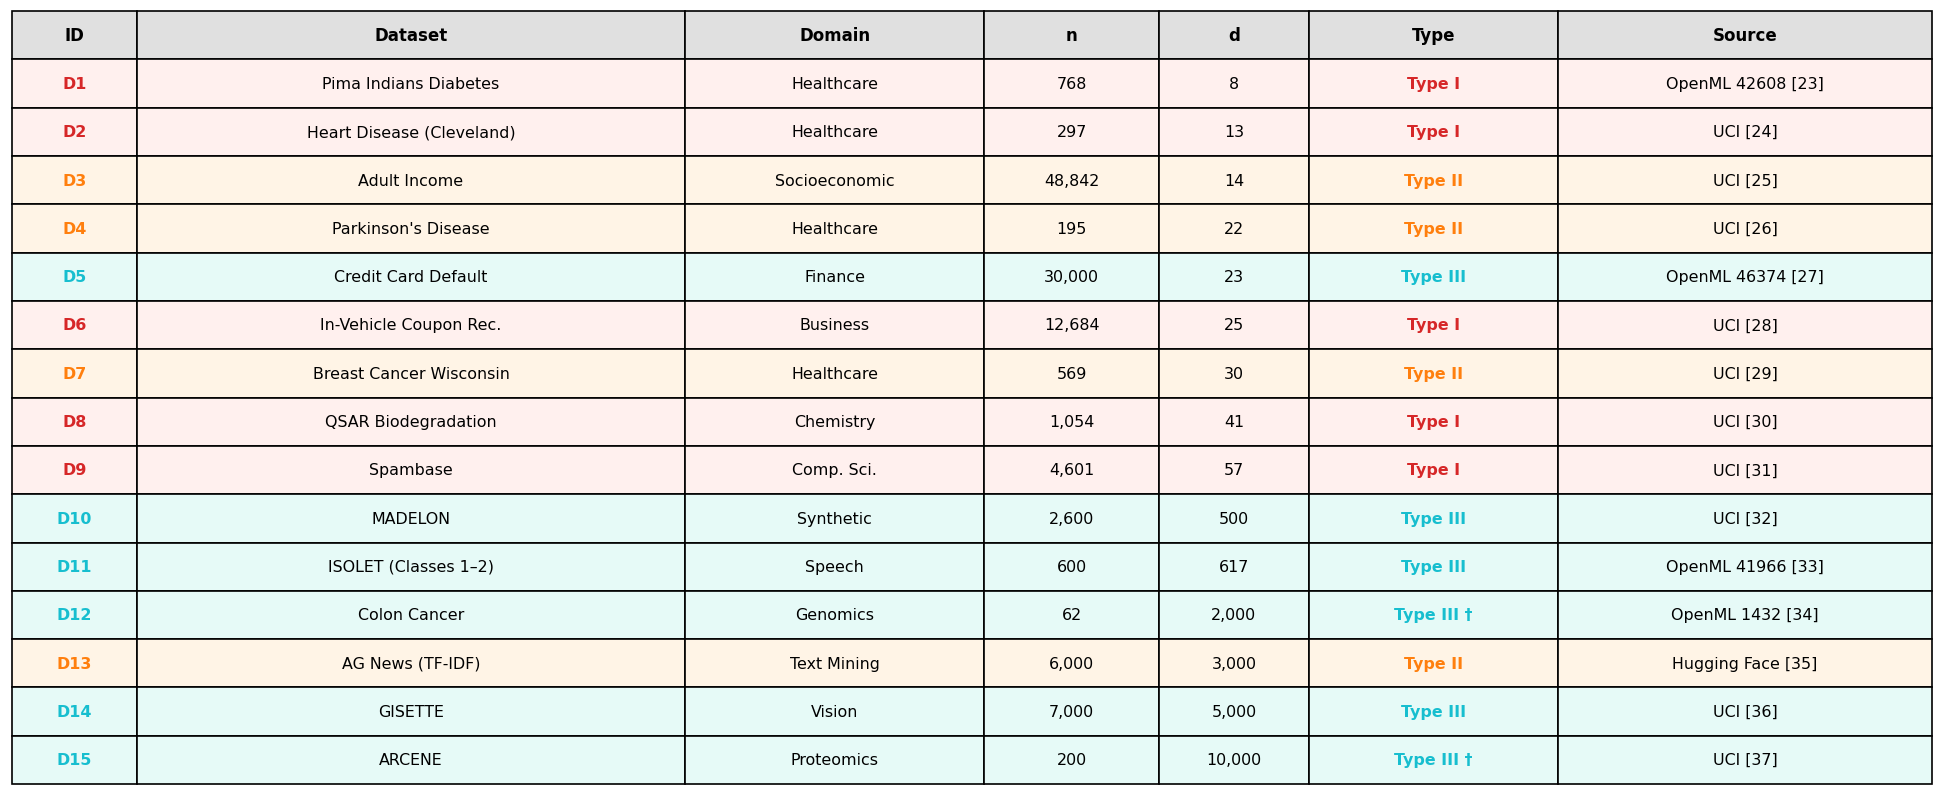

Saved: table1_dataset_inventory.png


In [15]:
# =============================================================================
# SECTION 7 — Dataset Table (Table 1)
# =============================================================================
# Data sources:
# - DATASETS → (name, domain)
# - ND_MAP → (n, d)
# - type_map → derived from Section 3.5
# =============================================================================

import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# n and d
# -----------------------------------------------------------------------------
ND_MAP = {
    "D1": (768, 8), "D2": (297, 13), "D3": (48842, 14),
    "D4": (195, 22), "D5": (30000, 23), "D6": (12684, 25),
    "D7": (569, 30), "D8": (1054, 41), "D9": (4601, 57),
    "D10": (2600, 500), "D11": (600, 617), "D12": (62, 2000),
    "D13": (6000, 3000), "D14": (7000, 5000), "D15": (200, 10000),
}

# -----------------------------------------------------------------------------
# Type from Section 3.5
# -----------------------------------------------------------------------------
type_map = {}
for d in type_I:
    type_map[d] = "I"
for d in type_II:
    type_map[d] = "II"
for d in type_III:
    type_map[d] = "III"

# -----------------------------------------------------------------------------
# SOURCES
# -----------------------------------------------------------------------------
DATASET_REFS = {
    "D1":  "OpenML 42608 [23]", "D2":  "UCI [24]",
    "D3":  "UCI [25]", "D4":  "UCI [26]",
    "D5":  "OpenML 46374 [27]", "D6":  "UCI [28]",
    "D7":  "UCI [29]", "D8":  "UCI [30]",
    "D9":  "UCI [31]", "D10": "UCI [32]",
    "D11": "OpenML 41966 [33]", "D12": "OpenML 1432 [34]",
    "D13": "Hugging Face [35]", "D14": "UCI [36]",
    "D15": "UCI [37]",
}

DATASET_FULLNAMES = {
    "D1":  "Pima Indians Diabetes", "D2":  "Heart Disease (Cleveland)",
    "D3":  "Adult Income", "D4":  "Parkinson's Disease",
    "D5":  "Credit Card Default", "D6":  "In-Vehicle Coupon Rec.",
    "D7":  "Breast Cancer Wisconsin", "D8":  "QSAR Biodegradation",
    "D9":  "Spambase", "D10": "MADELON",
    "D11": "ISOLET (Classes 1–2)", "D12": "Colon Cancer",
    "D13": "AG News (TF-IDF)", "D14": "GISETTE",
    "D15": "ARCENE",
}

# -----------------------------------------------------------------------------
# COLORS
# -----------------------------------------------------------------------------
type_row_colors = {"I": "#FFF0EE", "II": "#FFF4E6", "III": "#E6FAF7"}
type_txt_colors = {"I": "#d62728", "II": "#ff7f0e", "III": "#17becf"}

# -----------------------------------------------------------------------------
# VERIFICATION
# -----------------------------------------------------------------------------
print("=" * 60)
print("Table 1 — Type Assignment (from RS taxonomy)")
print("=" * 60)
for did in [f"D{i}" for i in range(1, 16)]:
    dtype = type_map[did]
    rc    = " †  ← rank-constrained" if did in RANK_CONSTRAINED else ""
    print(f"  {did:<5}  Type {dtype}{rc}")

# -----------------------------------------------------------------------------
# Build rows
# -----------------------------------------------------------------------------
col_labels = ["ID", "Dataset", "Domain", "n", "d", "Type", "Source"]

table_data = []
for did in [f"D{i}" for i in range(1, 16)]:
    name, domain = DATASETS[did]
    n_val, d_val = ND_MAP[did]
    dtype = type_map[did]
    rc_tag = " †" if did in RANK_CONSTRAINED else ""

    table_data.append([
        did,
        DATASET_FULLNAMES[did],
        domain,
        f"{n_val:,}",
        f"{d_val:,}",
        f"Type {dtype}{rc_tag}",
        DATASET_REFS[did],
    ])

# -----------------------------------------------------------------------------
# Row colors
# -----------------------------------------------------------------------------
row_colors = [
    [type_row_colors.get(type_map.get(row[0], "?"), "white")] * len(col_labels)
    for row in table_data
]

# -----------------------------------------------------------------------------
# Figure
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 7))
ax.set_position([0, 0.05, 1, 0.92])
ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=row_colors,
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(9.5)

# Column widths — SAME
col_widths = [0.05, 0.22, 0.12, 0.07, 0.06, 0.10, 0.15]
for j, w in enumerate(col_widths):
    for i in range(len(table_data) + 1):
        table[i, j].set_width(w)

# Header — SAME
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#E0E0E0")
    table[0, j].set_text_props(fontweight="bold", fontsize=10)

# ID + Type styling — SAME
for i, row in enumerate(table_data):
    dtype = type_map.get(row[0], "?")
    c = type_txt_colors.get(dtype, "black")
    table[i+1, 0].set_text_props(color=c, fontweight="bold")
    table[i+1, 5].set_text_props(color=c, fontweight="bold")

plt.savefig("table1_dataset_inventory.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: table1_dataset_inventory.png")

SECTION 8 — Verification: Requested vs Effective Retention

D11
  k_req range : 555
  k_eff       : 479
  r_eff       : 0.776
  d           : 617
  n_train     : 480
  Mechanism   : k_req > n_tr − 1 → k_eff = n_tr − 1 = 480 − 1 = 479

D12
  k_req range : 200 – 1,800
  k_eff       : 48
  r_eff       : 0.024
  d           : 2000
  n_train     : 49
  Mechanism   : k_req > n_tr − 1 → k_eff = n_tr − 1 = 49 − 1 = 48

D15
  k_req range : 1,000 – 9,000
  k_eff       : 159
  r_eff       : 0.016
  d           : 10000
  n_train     : 160
  Mechanism   : k_req > n_tr − 1 → k_eff = n_tr − 1 = 160 − 1 = 159
  -> wrote ./table_section8_retention.tex  (3 rows)


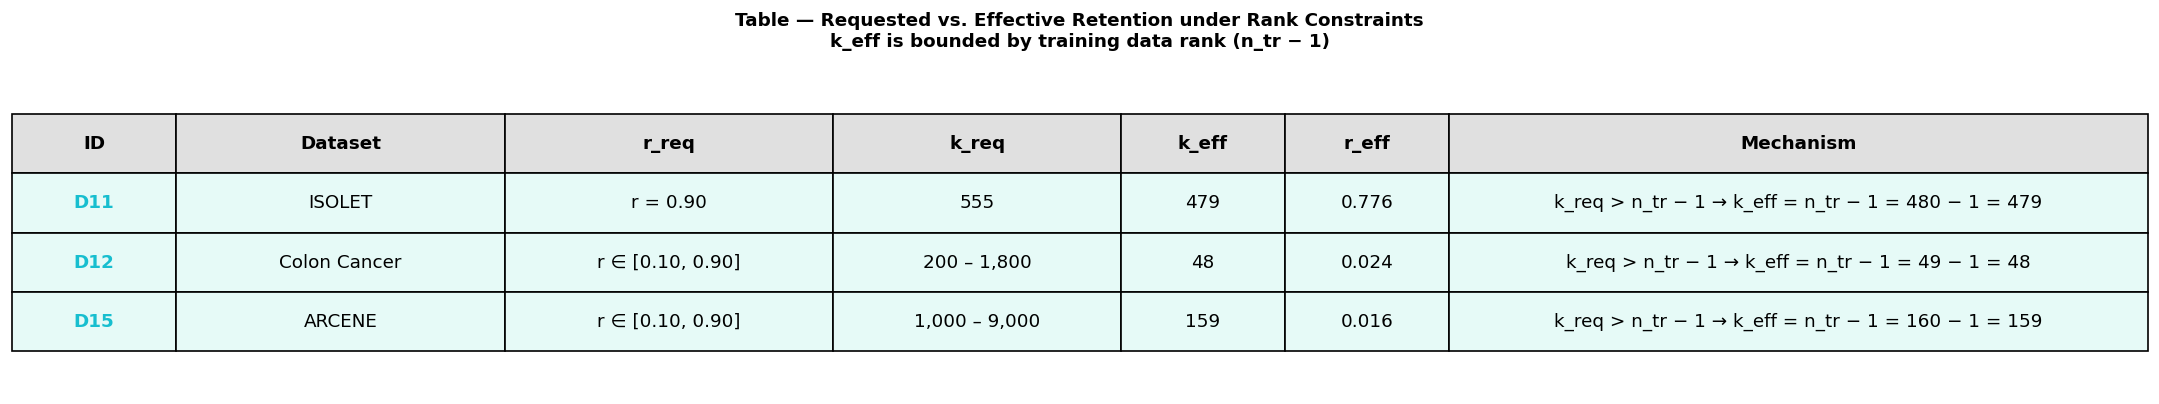


Saved: table_section8_retention.png


In [16]:
# =============================================================================
# SECTION 8 — Requested vs. Effective Retention (Table 2)
# Derived entirely from experimental outputs (raw)
# k_eff is bounded by training data rank (n_tr − 1)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ok = raw[raw["status"] == "OK"].copy()

DATASET_DISPLAY = {
    "D11": "ISOLET",
    "D12": "Colon Cancer",
    "D15": "ARCENE",
}

R_REQ_DISPLAY = {
    "D11": "r = 0.90",
    "D12": "r ∈ [0.10, 0.90]",
    "D15": "r ∈ [0.10, 0.90]",
}

# Known dimensionalities
D_MAP = {
    "D11": 617,
    "D12": 2000,
    "D15": 10000,
}

table_rows = []

print("=" * 70)
print("SECTION 8 — Verification: Requested vs Effective Retention")
print("=" * 70)

for did in ["D11", "D12", "D15"]:
    sub = ok[ok["dataset_id"] == did]

    # Robust aggregation
    grouped = (
        sub.groupby("retention_ratio_requested")
        .agg({
            "k_requested": "max",
            "k_used": "max",
            "retention_ratio_effective": "mean"
        })
        .reset_index()
    )

    affected = grouped[grouped["k_requested"] != grouped["k_used"]]

    if affected.empty:
        continue

    k_req_vals = affected["k_requested"].tolist()
    k_eff_vals = affected["k_used"].tolist()
    r_eff_vals = affected["retention_ratio_effective"].tolist()

    k_eff = int(max(k_eff_vals))
    r_eff = float(np.mean(r_eff_vals))
    n_train = k_eff + 1
    d_est = D_MAP[did]

    if len(k_req_vals) == 1:
        k_req_str = f"{k_req_vals[0]:,}"
    else:
        k_req_str = f"{min(k_req_vals):,} – {max(k_req_vals):,}"

    # Uniform mechanism explanation (aligned with Section 3.4 / 4.3)
    mechanism = (
        f"k_req > n_tr − 1 → k_eff = n_tr − 1 = {n_train} − 1 = {k_eff}"
    )

    table_rows.append([
        did,
        DATASET_DISPLAY[did],
        R_REQ_DISPLAY[did],
        k_req_str,
        str(k_eff),
        f"{r_eff:.3f}",
        mechanism,
    ])

    # Verification print
    print(f"\n{did}")
    print(f"  k_req range : {k_req_str}")
    print(f"  k_eff       : {k_eff}")
    print(f"  r_eff       : {r_eff:.3f}")
    print(f"  d           : {d_est}")
    print(f"  n_train     : {n_train}")
    print(f"  Mechanism   : {mechanism}")

# -----------------------------------------------------------------------------
# TABLE RENDER
# -----------------------------------------------------------------------------
col_labels = ["ID", "Dataset", "r_req", "k_req", "k_eff", "r_eff", "Mechanism"]

fig, ax = plt.subplots(figsize=(18, 3.5))
ax.axis("off")

row_colors = [["#E6FAF7"] * len(col_labels)] * len(table_rows)

table = ax.table(
    cellText=table_rows,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=row_colors,
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 3.0)

col_widths = [0.08, 0.16, 0.16, 0.14, 0.08, 0.08, 0.34]
for j, w in enumerate(col_widths):
    for i in range(len(table_rows) + 1):
        table[i, j].set_width(w)

# Header styling
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#E0E0E0")
    table[0, j].set_text_props(fontweight="bold", fontsize=11)

# ID column styling
for i in range(len(table_rows)):
    table[i+1, 0].set_text_props(color="#17becf", fontweight="bold")

ax.set_title(
    "Table — Requested vs. Effective Retention under Rank Constraints\n"
    "k_eff is bounded by training data rank (n_tr − 1)",
    fontsize=11,
    fontweight="bold",
    pad=16
)

plt.tight_layout()
plt.savefig("table_section8_retention.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: table_section8_retention.png")

Section 5.1 — Overall Predictive Performance: Verification

Method macro-averages:
  PCA         : 0.826
  UMAP        : 0.772
  AE          : 0.784
  SelectKBest : 0.825
  RFE         : 0.823

Best method: PCA
  -> wrote ./table3_best_accuracy.tex  (16 rows)


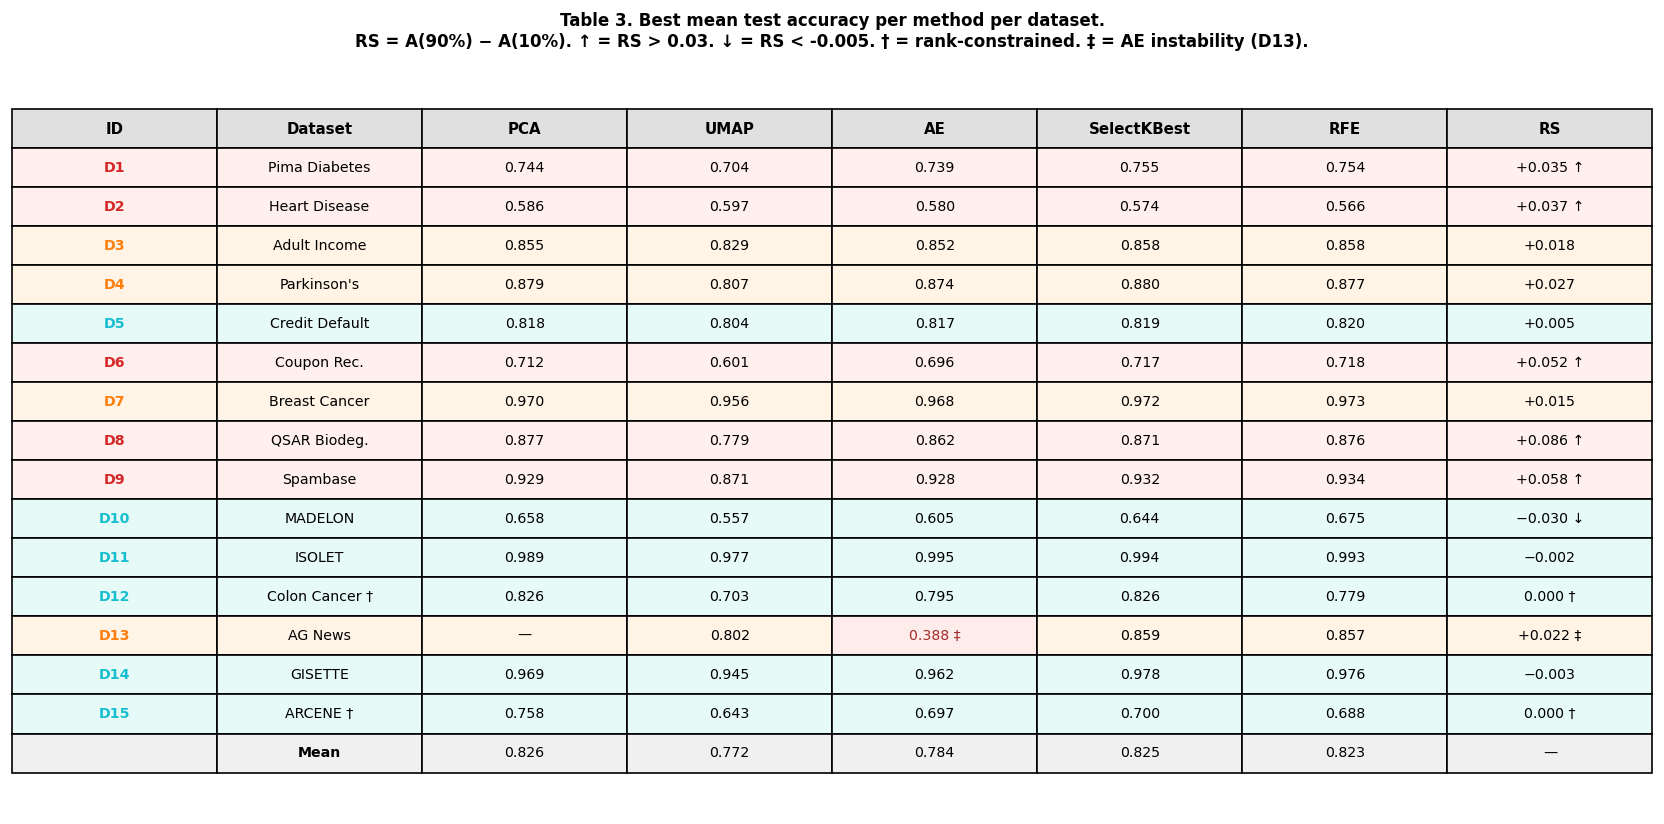

Saved: table3_best_accuracy.png


In [17]:
# =============================================================================
# SECTION 5.1 — Overall Predictive Performance (Table 3)
# Best mean test accuracy per method per dataset
# RS = A(90%) − A(10%)
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# FILTER VALID RUNS
# -----------------------------------------------------------------------------
ok = raw[raw["status"] == "OK"].copy()

# -----------------------------------------------------------------------------
# BEST MEAN ACCURACY (mean per retention → max across retention)
# -----------------------------------------------------------------------------
best_acc = (
    ok.groupby(["dataset_id", "method", "retention_ratio_requested"])["accuracy"]
      .mean()
      .reset_index()
      .groupby(["dataset_id", "method"])["accuracy"]
      .max()
      .reset_index()
      .rename(columns={"accuracy": "mean_acc"})
)

# -----------------------------------------------------------------------------
# RS COMPUTATION (no rounding for logic)
# -----------------------------------------------------------------------------
agg = (
    ok.groupby(["dataset_id", "retention_ratio_requested"])["accuracy"]
      .mean()
      .reset_index()
)

rs_all = {}
for did in sorted(ok["dataset_id"].unique()):
    sub = agg[agg["dataset_id"] == did]

    a10 = sub.loc[np.isclose(sub["retention_ratio_requested"], 0.10), "accuracy"]
    a90 = sub.loc[np.isclose(sub["retention_ratio_requested"], 0.90), "accuracy"]

    if not a10.empty and not a90.empty:
        rs_all[did] = float(a90.values[0]) - float(a10.values[0])

# -----------------------------------------------------------------------------
# TYPE CLASSIFICATION (Section 3.5 — recomputed here)
# -----------------------------------------------------------------------------
EPS = 1e-6

type1 = {d for d, r in rs_all.items() if r > 0.030 + EPS}
type2 = {d for d, r in rs_all.items() if 0.005 + EPS < r <= 0.030 + EPS}
type3 = {d for d, r in rs_all.items() if r <= 0.005 + EPS}

type_map = {}
for d in type1:
    type_map[d] = "I"
for d in type2:
    type_map[d] = "II"
for d in type3:
    type_map[d] = "III"

# -----------------------------------------------------------------------------
# COLORS
# -----------------------------------------------------------------------------
type_row_colors = {"I": "#FFF0EE", "II": "#FFF4E6", "III": "#E6FAF7"}
type_txt_colors = {"I": "#d62728", "II": "#ff7f0e", "III": "#17becf"}

# -----------------------------------------------------------------------------
# RS LABEL FORMAT
# -----------------------------------------------------------------------------
def rs_label(did, rs):
    if did in RANK_CONSTRAINED:
        return "0.000 †"

    sign = "+" if rs >= 0 else "−"

    if rs > 0.030:
        arrow = " ↑"
    elif rs < -0.005:
        arrow = " ↓"
    else:
        arrow = ""

    ae = " ‡" if did == "D13" else ""

    return f"{sign}{abs(rs):.3f}{arrow}{ae}"

# -----------------------------------------------------------------------------
# DATASET NAME
# -----------------------------------------------------------------------------
def dataset_label(did):
    name = DATASETS[did][0].replace("†", "").strip()
    if did in RANK_CONSTRAINED:
        return f"{name} †"
    return name

# -----------------------------------------------------------------------------
# BUILD TABLE
# -----------------------------------------------------------------------------
METHODS = ["PCA", "UMAP", "AE", "SelectKBest", "RFE"]

col_labels = ["ID", "Dataset", "PCA", "UMAP", "AE", "SelectKBest", "RFE", "RS"]

table_data = []

for did in [f"D{i}" for i in range(1, 16)]:
    sub = best_acc[best_acc["dataset_id"] == did]

    row = [did, dataset_label(did)]

    for m in METHODS:
        ms = sub[sub["method"] == m]

        if not ms.empty:
            val = float(ms["mean_acc"].values[0])
            if did == "D13" and m == "AE":
                row.append(f"{val:.3f} ‡")
            else:
                row.append(f"{val:.3f}")
        else:
            row.append("—")

    rs = rs_all.get(did, float("nan"))
    row.append(rs_label(did, rs))

    table_data.append(row)

# -----------------------------------------------------------------------------
# MEAN ROW
# -----------------------------------------------------------------------------
mean_row = ["", "Mean"]

for m in METHODS:
    val = best_acc[best_acc["method"] == m]["mean_acc"].mean()
    mean_row.append(f"{val:.3f}")

mean_row.append("—")
table_data.append(mean_row)

# -----------------------------------------------------------------------------
# VERIFICATION PRINT (for reviewers)
# -----------------------------------------------------------------------------
print("=" * 65)
print("Section 5.1 — Overall Predictive Performance: Verification")
print("=" * 65)

print("\nMethod macro-averages:")
for m in METHODS:
    val = best_acc[best_acc["method"] == m]["mean_acc"].mean()
    print(f"  {m:<12}: {val:.3f}")

best_method = max(METHODS, key=lambda m:
    best_acc[best_acc["method"] == m]["mean_acc"].mean()
)

print(f"\nBest method: {best_method}")

# -----------------------------------------------------------------------------
# ROW COLORS
# -----------------------------------------------------------------------------
row_colors = []
for row in table_data:
    did = row[0]
    dtype = type_map.get(did, "?")
    base = type_row_colors.get(dtype, "#F9F9F9")
    row_colors.append([base] * len(col_labels))

row_colors[-1] = ["#F0F0F0"] * len(col_labels)

# -----------------------------------------------------------------------------
# RENDER TABLE
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=row_colors,
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.7)

# Header
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#E0E0E0")
    table[0, j].set_text_props(fontweight="bold", fontsize=9)

# ID coloring
for i, row in enumerate(table_data):
    did = row[0]
    dtype = type_map.get(did, "?")
    c = type_txt_colors.get(dtype, "black")

    table[i+1, 0].set_text_props(color=c, fontweight="bold")

    if row[1] == "Mean":
        table[i+1, 1].set_text_props(fontweight="bold")

# Highlight AE failure (D13)
for i, row in enumerate(table_data):
    if row[0] == "D13":
        table[i+1, 4].set_facecolor("#FDECEA")
        table[i+1, 4].set_text_props(color="#A32D2D")

# -----------------------------------------------------------------------------
# TITLE
# -----------------------------------------------------------------------------
ax.set_title(
    "Table 3. Best mean test accuracy per method per dataset.\n"
    "RS = A(90%) − A(10%). ↑ = RS > 0.03. ↓ = RS < -0.005. "
    "† = rank-constrained. ‡ = AE instability (D13).",
    fontsize=10,
    fontweight="bold",
    pad=14
)

plt.tight_layout()
plt.savefig("table3_best_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: table3_best_accuracy.png")

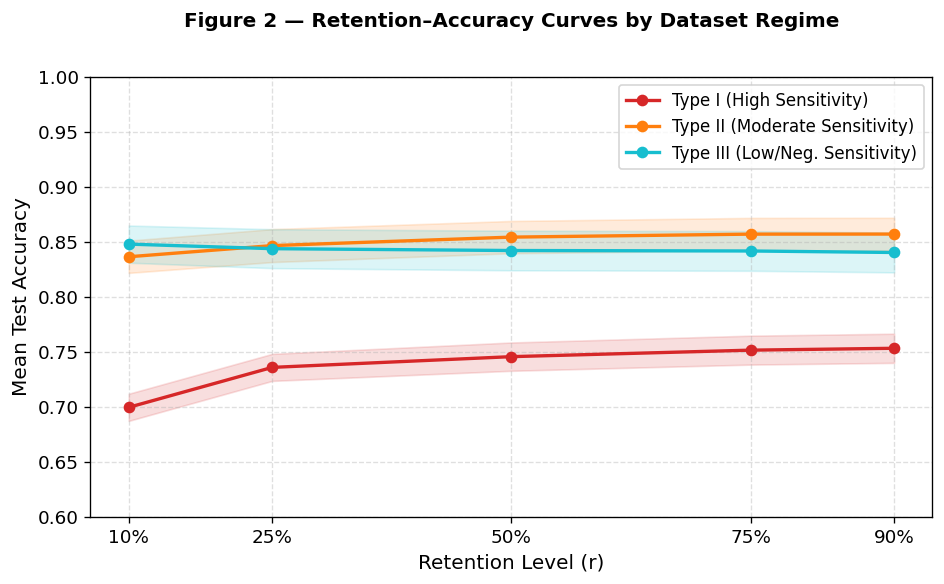

Saved: figure2_regime_curves.png
  -> wrote ./table4_per_dataset_accuracy.tex  (15 rows)


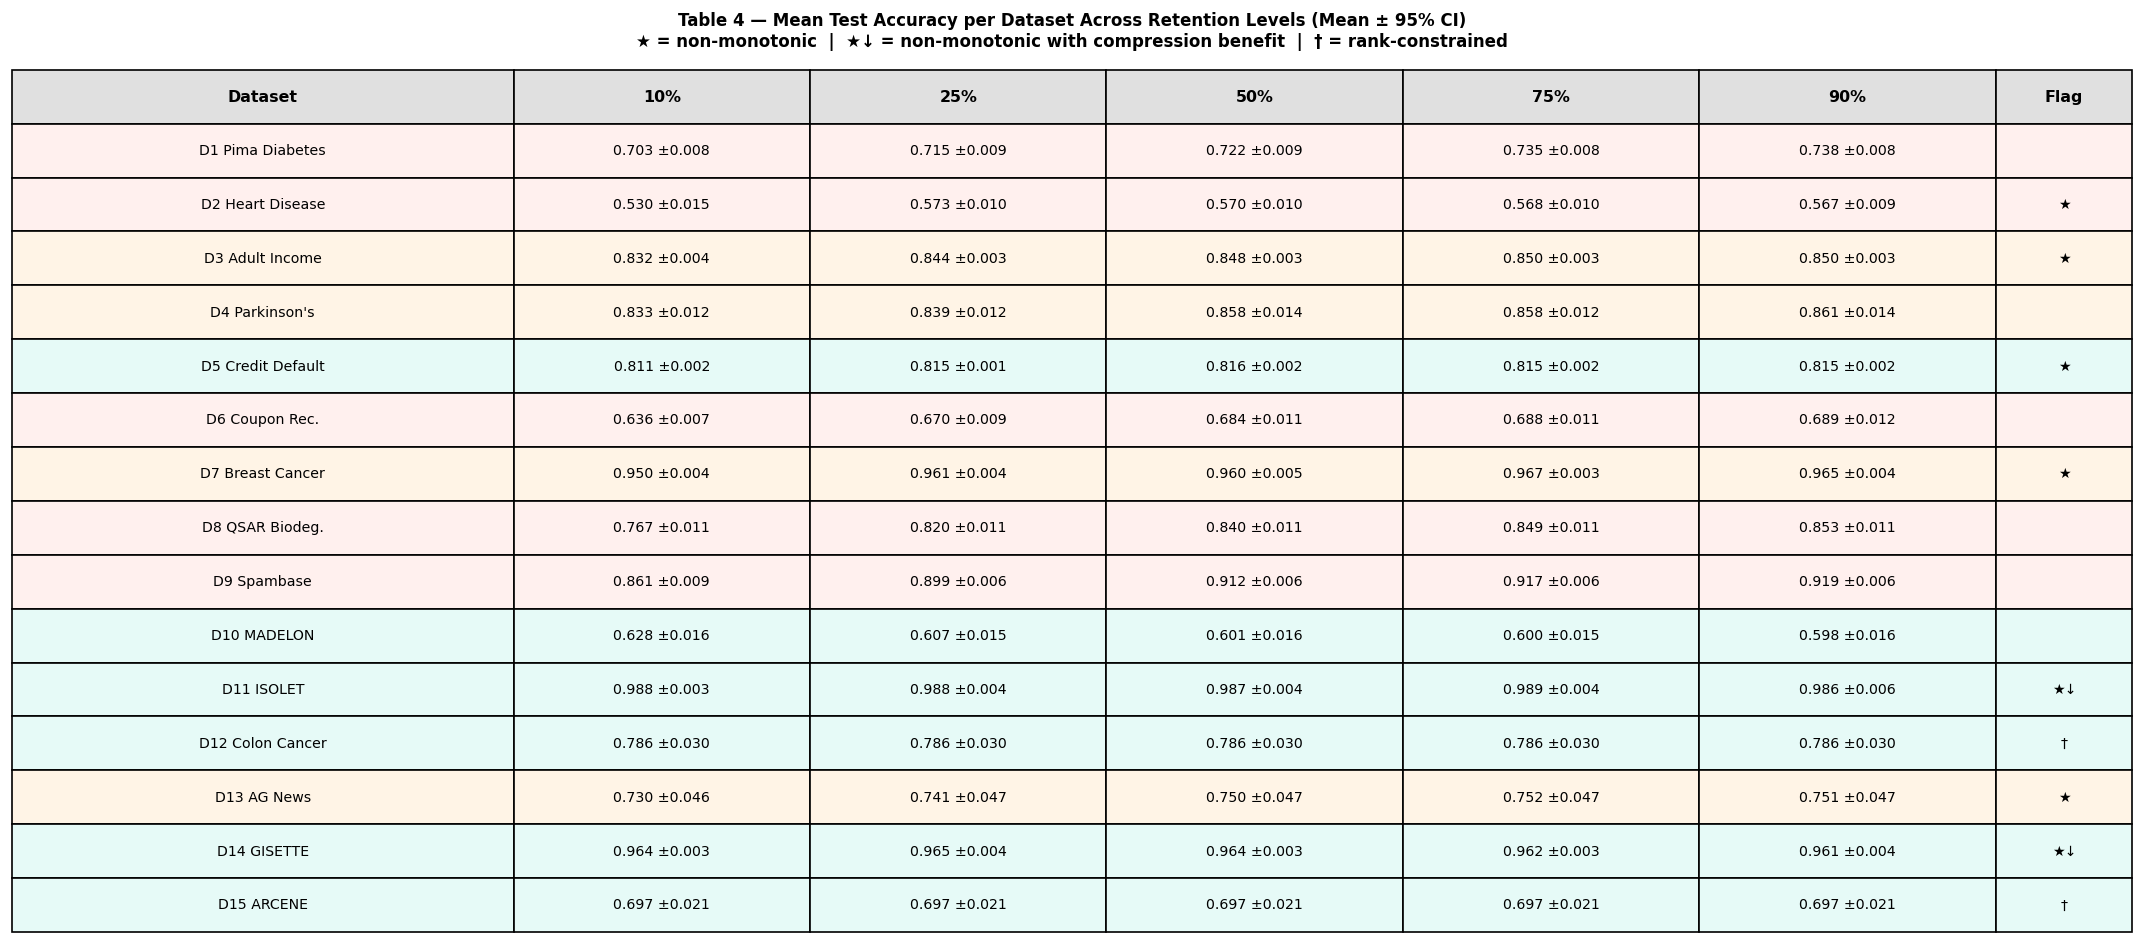

Saved: table4_per_dataset_accuracy.png

--- REGIME SUMMARY STATS FOR SECTION 5.2 TEXT ---
Type I: mean acc @10%=0.699, @90%=0.753, gap=0.054
Type II: mean acc @10%=0.836, @90%=0.857, gap=0.021
Type III: mean acc @10%=0.848, @90%=0.840, gap=-0.008


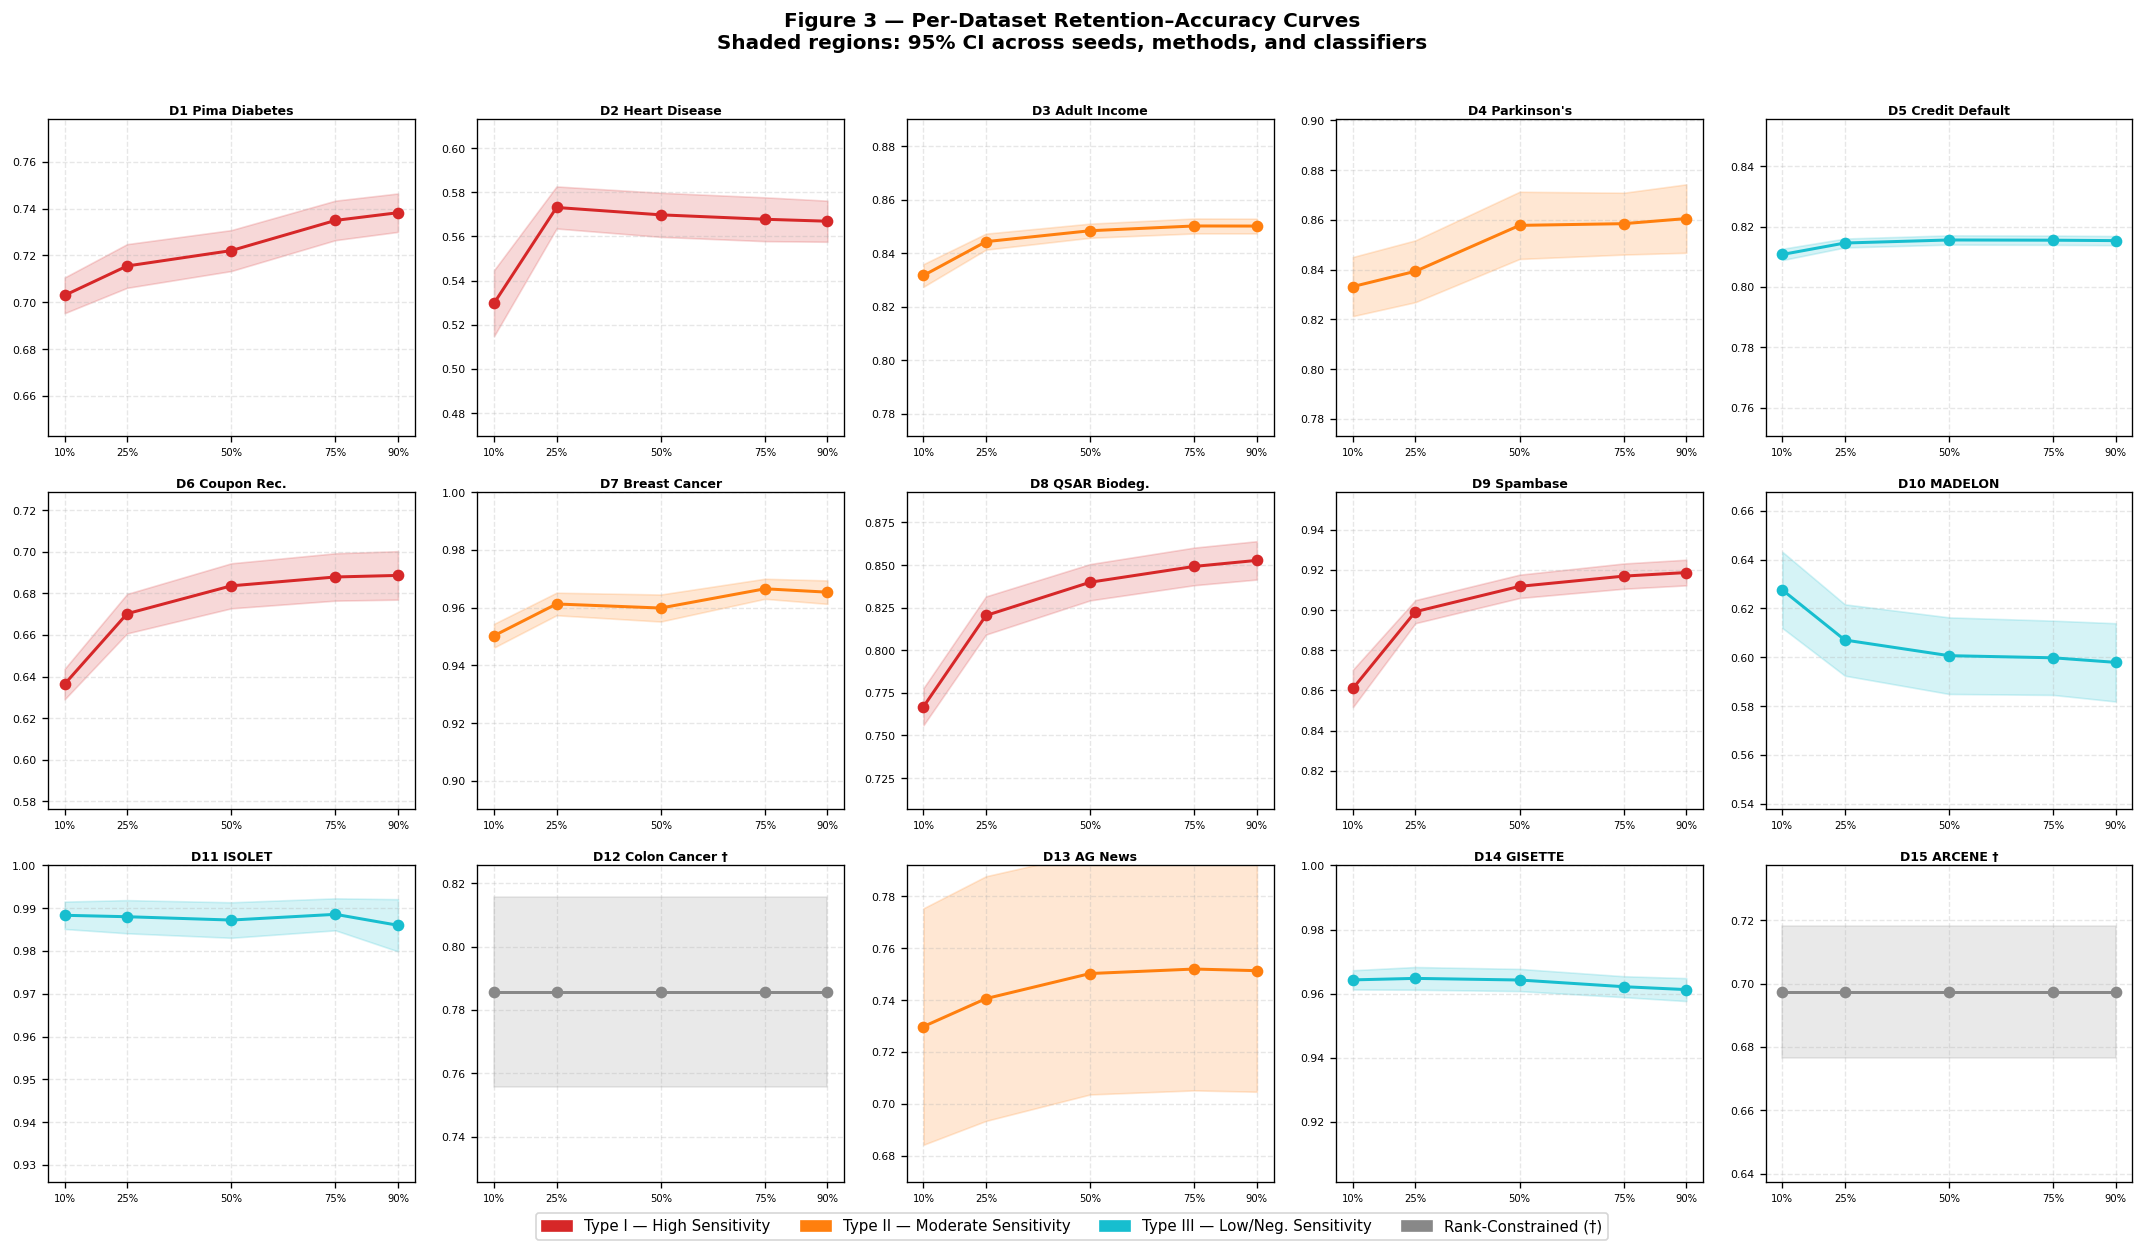

Saved: figure3_per_dataset_curves.png

Section 5.2 outputs complete.


In [18]:
# =============================================================================
# SECTION 5.2 — COMPRESSION BEHAVIOR ACROSS DATASET TYPES
# Produces: Figure 2 (regime curves), Table 4 (per-dataset accuracy), Figure 3 (per-dataset curves)
# Requires: ok, type_I, type_II, type_III, RANK_CONSTRAINED, DATASETS already defined.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
RETENTION_LEVELS = [0.10, 0.25, 0.50, 0.75, 0.90]
CI_ALPHA = 0.95

REGIME_CONFIG = {
    "I":   {"label": "Type I (High Sensitivity)",    "color": "#d62728", "datasets": type_I},
    "II":  {"label": "Type II (Moderate Sensitivity)","color": "#ff7f0e", "datasets": type_II},
    "III": {"label": "Type III (Low/Neg. Sensitivity)","color": "#17becf",
            "datasets": [d for d in type_III if d not in RANK_CONSTRAINED]},
}

DATASET_FULLNAMES = {
    "D1": "Pima Diabetes",       "D2": "Heart Disease",       "D3": "Adult Income",
    "D4": "Parkinson's",         "D5": "Credit Default",      "D6": "Coupon Rec.",
    "D7": "Breast Cancer",       "D8": "QSAR Biodeg.",        "D9": "Spambase",
    "D10": "MADELON",            "D11": "ISOLET",             "D12": "Colon Cancer",
    "D13": "AG News",            "D14": "GISETTE",            "D15": "ARCENE",
}

# -----------------------------------------------------------------------------
# HELPER: per-dataset mean accuracy and 95% CI at each retention level
# -----------------------------------------------------------------------------
def compute_retention_stats(dataset_id, ok_df):
    """
    Returns a dict: retention_level -> (mean_acc, ci_half_width)
    CI computed via t-distribution over seeds x methods x classifiers.
    """
    sub = ok_df[ok_df["dataset_id"] == dataset_id]
    result = {}
    for r in RETENTION_LEVELS:
        vals = sub[np.isclose(sub["retention_ratio_requested"], r, atol=1e-6)]["accuracy"].dropna()
        if len(vals) < 2:
            result[r] = (np.nan, np.nan)
            continue
        m = vals.mean()
        se = stats.sem(vals)
        t_crit = stats.t.ppf((1 + CI_ALPHA) / 2, df=len(vals) - 1)
        result[r] = (m, t_crit * se)
    return result


# Build full per-dataset stats
all_stats = {}
for did in [f"D{i}" for i in range(1, 16)]:
    all_stats[did] = compute_retention_stats(did, ok)


# =============================================================================
# FIGURE 2 — REGIME-LEVEL RETENTION–ACCURACY CURVES
# =============================================================================

fig2, ax2 = plt.subplots(figsize=(8, 5))

for regime_key, cfg in REGIME_CONFIG.items():
    datasets_in_regime = cfg["datasets"]
    color = cfg["color"]
    label = cfg["label"]

    # Aggregate across datasets in regime
    regime_means = []
    regime_uppers = []
    regime_lowers = []

    for r in RETENTION_LEVELS:
        vals_all = []
        for did in datasets_in_regime:
            sub = ok[ok["dataset_id"] == did]
            vals = sub[np.isclose(sub["retention_ratio_requested"], r, atol=1e-6)]["accuracy"].dropna()
            vals_all.extend(vals.tolist())

        vals_all = np.array(vals_all)
        if len(vals_all) < 2:
            regime_means.append(np.nan)
            regime_uppers.append(np.nan)
            regime_lowers.append(np.nan)
            continue

        m = vals_all.mean()
        se = stats.sem(vals_all)
        t_crit = stats.t.ppf((1 + CI_ALPHA) / 2, df=len(vals_all) - 1)
        half = t_crit * se

        regime_means.append(m)
        regime_uppers.append(m + half)
        regime_lowers.append(m - half)

    regime_means = np.array(regime_means)
    regime_uppers = np.array(regime_uppers)
    regime_lowers = np.array(regime_lowers)

    ax2.plot(RETENTION_LEVELS, regime_means, marker="o", color=color, linewidth=2, label=label)
    ax2.fill_between(RETENTION_LEVELS, regime_lowers, regime_uppers, alpha=0.15, color=color)

ax2.set_xlabel("Retention Level (r)", fontsize=12)
ax2.set_ylabel("Mean Test Accuracy", fontsize=12)
ax2.set_title("Figure 2 — Retention–Accuracy Curves by Dataset Regime", fontsize=12, fontweight="bold", pad="30")
ax2.set_xticks(RETENTION_LEVELS)
ax2.set_xticklabels([f"{int(r*100)}%" for r in RETENTION_LEVELS])
ax2.legend(fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.set_ylim(0.6, 1.0)

plt.tight_layout()
plt.savefig("figure2_regime_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure2_regime_curves.png")


# =============================================================================
# TABLE 4 — PER-DATASET MEAN ACCURACY ACROSS RETENTION LEVELS WITH 95% CI
# =============================================================================

# Determine non-monotonic datasets and compression-benefit datasets
def classify_behavior(did, stats_dict):
    means = [stats_dict[did][r][0] for r in RETENTION_LEVELS]
    means_clean = [m for m in means if not np.isnan(m)]
    if len(means_clean) < 2:
        return ""

    # Check monotonic increasing
    is_mono_inc = all(means_clean[i] <= means_clean[i+1] for i in range(len(means_clean)-1))
    # Check monotonic decreasing
    is_mono_dec = all(means_clean[i] >= means_clean[i+1] for i in range(len(means_clean)-1))

    acc_at_10  = stats_dict[did][0.10][0]
    acc_at_90  = stats_dict[did][0.90][0]

    if not is_mono_inc and not is_mono_dec:
        if acc_at_10 > acc_at_90:
            return "★↓"  # non-monotonic AND compression benefit
        return "★"        # non-monotonic
    return ""

# Build table rows
table4_rows = []
col_labels_t4 = ["Dataset", "10%", "25%", "50%", "75%", "90%", "Flag"]

for did in [f"D{i}" for i in range(1, 16)]:
    name = DATASET_FULLNAMES.get(did, did)
    flag = ""
    if did in RANK_CONSTRAINED:
        flag = "†"
    else:
        flag = classify_behavior(did, all_stats)

    row = [f"{did} {name}"]
    for r in RETENTION_LEVELS:
        m, ci = all_stats[did][r]
        if np.isnan(m):
            row.append("—")
        else:
            row.append(f"{m:.3f} ±{ci:.3f}")
    row.append(flag)
    table4_rows.append(row)

# Render
fig4, ax4 = plt.subplots(figsize=(18, 8))
ax4.axis("off")

# Row colors
def get_row_color(did):
    if did in type_I:   return "#FFF0EE"
    if did in type_II:  return "#FFF4E6"
    return "#E6FAF7"

row_colors_t4 = [
    [get_row_color(f"D{i}")] * len(col_labels_t4)
    for i in range(1, 16)
]

tbl4 = ax4.table(
    cellText=table4_rows,
    colLabels=col_labels_t4,
    cellLoc="center",
    loc="center",
    cellColours=row_colors_t4,
    bbox=[0, 0, 1, 1]
)
tbl4.auto_set_font_size(False)
tbl4.set_fontsize(8.5)

col_widths_t4 = [0.22, 0.13, 0.13, 0.13, 0.13, 0.13, 0.06]
for j, w in enumerate(col_widths_t4):
    for i in range(len(table4_rows) + 1):
        tbl4[i, j].set_width(w)

for j in range(len(col_labels_t4)):
    tbl4[0, j].set_facecolor("#E0E0E0")
    tbl4[0, j].set_text_props(fontweight="bold", fontsize=9.5)

ax4.set_title(
    "Table 4 — Mean Test Accuracy per Dataset Across Retention Levels (Mean ± 95% CI)\n"
    "★ = non-monotonic  |  ★↓ = non-monotonic with compression benefit  |  † = rank-constrained",
    fontsize=10, fontweight="bold", pad=14
)

plt.tight_layout()
plt.savefig("table4_per_dataset_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: table4_per_dataset_accuracy.png")

# Print numerical summary for paper text
print("\n--- REGIME SUMMARY STATS FOR SECTION 5.2 TEXT ---")
for regime_key, cfg in REGIME_CONFIG.items():
    datasets_in_regime = cfg["datasets"]
    accs_10 = []
    accs_90 = []
    for did in datasets_in_regime:
        m10, _ = all_stats[did][0.10]
        m90, _ = all_stats[did][0.90]
        if not np.isnan(m10): accs_10.append(m10)
        if not np.isnan(m90): accs_90.append(m90)
    print(f"Type {regime_key}: mean acc @10%={np.mean(accs_10):.3f}, @90%={np.mean(accs_90):.3f}, "
          f"gap={np.mean(accs_90)-np.mean(accs_10):.3f}")


# =============================================================================
# FIGURE 3 — PER-DATASET RETENTION–ACCURACY CURVES
# =============================================================================

ALL_DATASETS_ORDERED = [f"D{i}" for i in range(1, 16)]
n_datasets = len(ALL_DATASETS_ORDERED)
ncols = 5
nrows = 3

fig3, axes3 = plt.subplots(nrows, ncols, figsize=(18, 10), sharey=False)
axes3 = axes3.flatten()

def dataset_color(did):
    if did in type_I:           return "#d62728"
    if did in type_II:          return "#ff7f0e"
    if did in RANK_CONSTRAINED: return "#888888"
    return "#17becf"

for idx, did in enumerate(ALL_DATASETS_ORDERED):
    ax = axes3[idx]
    color = dataset_color(did)
    name = DATASET_FULLNAMES.get(did, did)

    means = [all_stats[did][r][0] for r in RETENTION_LEVELS]
    cis   = [all_stats[did][r][1] for r in RETENTION_LEVELS]

    means = np.array(means)
    cis   = np.array(cis)

    valid = ~np.isnan(means)
    x = np.array(RETENTION_LEVELS)[valid]
    y = means[valid]
    e = cis[valid]

    ax.plot(x, y, marker="o", color=color, linewidth=1.8)
    ax.fill_between(x, y - e, y + e, alpha=0.18, color=color)

    title_str = f"{did} {name}"
    if did in RANK_CONSTRAINED:
        title_str += " †"

    ax.set_title(title_str, fontsize=7.5, fontweight="bold", pad=3)
    ax.set_xticks(RETENTION_LEVELS)
    ax.set_xticklabels([f"{int(r*100)}%" for r in RETENTION_LEVELS], fontsize=6)
    ax.tick_params(axis="y", labelsize=6.5)
    ax.grid(True, linestyle="--", alpha=0.3)

    # y-axis range: tight around data
    if len(y) > 0:
        ymin = max(0, y.min() - 0.06)
        ymax = min(1, y.max() + 0.04)
        ax.set_ylim(ymin, ymax)

# Remove unused subplots
for idx in range(n_datasets, len(axes3)):
    fig3.delaxes(axes3[idx])

# Legend
patches = [
    mpatches.Patch(color="#d62728", label="Type I — High Sensitivity"),
    mpatches.Patch(color="#ff7f0e", label="Type II — Moderate Sensitivity"),
    mpatches.Patch(color="#17becf", label="Type III — Low/Neg. Sensitivity"),
    mpatches.Patch(color="#888888", label="Rank-Constrained (†)"),
]
fig3.legend(handles=patches, loc="lower center", ncol=4, fontsize=9,
            bbox_to_anchor=(0.5, -0.02), frameon=True)

fig3.suptitle(
    "Figure 3 — Per-Dataset Retention–Accuracy Curves\n"
    "Shaded regions: 95% CI across seeds, methods, and classifiers",
    fontsize=12, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("figure3_per_dataset_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure3_per_dataset_curves.png")

print("\nSection 5.2 outputs complete.")


[Generating Figure 4 - RS Distribution]

[Verification - RS Values]
Dataset         RS    Regime
----------------------------------------
D1         +0.0353    Type I
D2         +0.0371    Type I
D3         +0.0185    Type II
D4         +0.0274    Type II
D5         +0.0046    Type III
D6         +0.0523    Type I
D7         +0.0151    Type II
D8         +0.0859    Type I
D9         +0.0577    Type I
D10        -0.0297    Type III
D11        -0.0023    Type III
D12        +0.0000    Rank-constrained
D13        +0.0216    Type II
D14        -0.0030    Type III
D15        +0.0000    Rank-constrained


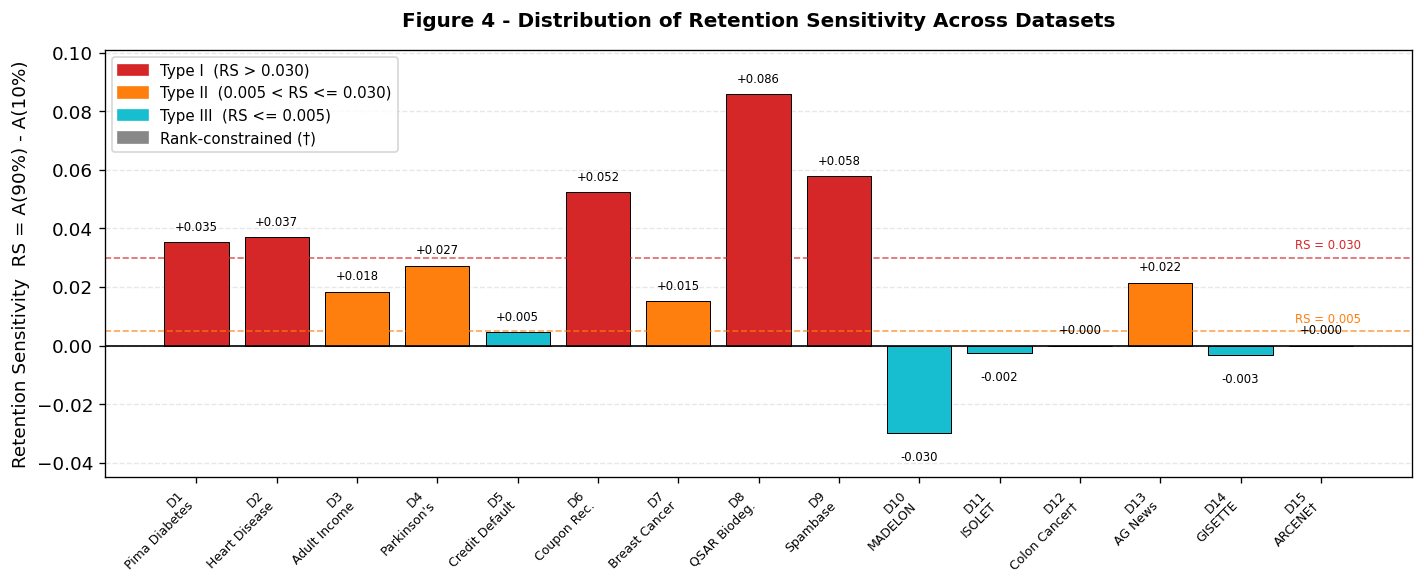


Saved: figure4_rs_distribution.png

--- RS SUMMARY FOR SECTION 5.3 TEXT ---
Type I  (n=5):  range [+0.0353, +0.0859]
Type II (n=4):  range [+0.0151, +0.0274]
Type III (n=4): range [-0.0297, +0.0046]
Rank-constrained (n=2): values ['+0.0000', '+0.0000']

Overall RS range: [-0.0297, +0.0859]
Number of negative-RS datasets: 3


In [19]:
# =============================================================================
# SECTION 5.3 — FIGURE 4: RETENTION SENSITIVITY (RS) ACROSS DATASETS
# Requires: raw, RANK_CONSTRAINED, DATASETS already defined.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("\n[Generating Figure 4 - RS Distribution]")

# -----------------------------------------------------------------------------
# DATASET ORDER
# -----------------------------------------------------------------------------
dids_sorted = [f"D{i}" for i in range(1, 16)]

# -----------------------------------------------------------------------------
# COMPUTE RS DIRECTLY FROM RAW (independent verification)
# -----------------------------------------------------------------------------
rs_vals = []
for d in dids_sorted:
    sub = raw[(raw["dataset_id"] == d) & (raw["status"] == "OK")]
    a10 = sub[np.isclose(sub["retention_ratio_requested"], 0.10)]["accuracy"].mean()
    a90 = sub[np.isclose(sub["retention_ratio_requested"], 0.90)]["accuracy"].mean()
    rs = a90 - a10
    rs_vals.append(rs)

# -----------------------------------------------------------------------------
# COLOR SCHEME
# -----------------------------------------------------------------------------
colors = {
    "I":   "#d62728",   # red
    "II":  "#ff7f0e",   # orange
    "III": "#17becf",   # teal
    "RC":  "#888888"    # rank-constrained
}

bar_colors = []
for d, rs in zip(dids_sorted, rs_vals):
    if d in RANK_CONSTRAINED:
        bar_colors.append(colors["RC"])
    elif rs > 0.030:
        bar_colors.append(colors["I"])
    elif rs > 0.005:
        bar_colors.append(colors["II"])
    else:
        bar_colors.append(colors["III"])

# -----------------------------------------------------------------------------
# VERIFICATION PRINT
# -----------------------------------------------------------------------------
print("\n[Verification - RS Values]")
print(f"{'Dataset':<8}{'RS':>10}    Regime")
print("-" * 40)
for d, rs, c in zip(dids_sorted, rs_vals, bar_colors):
    if c == colors["RC"]:
        regime = "Rank-constrained"
    elif c == colors["I"]:
        regime = "Type I"
    elif c == colors["II"]:
        regime = "Type II"
    else:
        regime = "Type III"
    print(f"{d:<8}{rs:>+10.4f}    {regime}")

# -----------------------------------------------------------------------------
# PLOT
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    range(len(dids_sorted)),
    rs_vals,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6
)

# Threshold lines
ax.axhline(0,      color="black",       lw=1)
ax.axhline(0.030,  color=colors["I"],   lw=1, ls="--", alpha=0.7)
ax.axhline(0.005,  color=colors["II"],  lw=1, ls="--", alpha=0.7)

# Annotate threshold lines
ax.text(len(dids_sorted) - 0.5, 0.032, "RS = 0.030",
        fontsize=7, color=colors["I"], ha="right", va="bottom")
ax.text(len(dids_sorted) - 0.5, 0.007, "RS = 0.005",
        fontsize=7, color=colors["II"], ha="right", va="bottom")

# Value labels on top of bars
for i, (rs, c) in enumerate(zip(rs_vals, bar_colors)):
    offset = 0.003 if rs >= 0 else -0.006
    ax.text(i, rs + offset, f"{rs:+.3f}",
            ha="center", va="bottom" if rs >= 0 else "top",
            fontsize=7, color="black")

# X labels
ax.set_xticks(range(len(dids_sorted)))
ax.set_xticklabels(
    [f"{d}\n{DATASETS[d][0]}" for d in dids_sorted],
    fontsize=7.5,
    rotation=45,
    ha="right"
)

# Y label and title
ax.set_ylabel("Retention Sensitivity  RS = A(90%) - A(10%)", fontsize=11)
ax.set_title(
    "Figure 4 - Distribution of Retention Sensitivity Across Datasets",
    fontsize=12, fontweight="bold", pad=14
)

# Legend
legend_patches = [
    mpatches.Patch(color=colors["I"],   label="Type I  (RS > 0.030)"),
    mpatches.Patch(color=colors["II"],  label="Type II  (0.005 < RS <= 0.030)"),
    mpatches.Patch(color=colors["III"], label="Type III  (RS <= 0.005)"),
    mpatches.Patch(color=colors["RC"],  label="Rank-constrained (\u2020)"),
]
ax.legend(handles=legend_patches, fontsize=9, loc="upper left", frameon=True)

# Grid
ax.grid(True, axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

# Y axis padding
ymin = min(rs_vals) - 0.015
ymax = max(rs_vals) + 0.015
ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.savefig("figure4_rs_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: figure4_rs_distribution.png")

# -----------------------------------------------------------------------------
# SUMMARY STATS FOR PAPER TEXT
# -----------------------------------------------------------------------------
print("\n--- RS SUMMARY FOR SECTION 5.3 TEXT ---")
type_I_vals   = [rs for d, rs in zip(dids_sorted, rs_vals) if d not in RANK_CONSTRAINED and rs > 0.030]
type_II_vals  = [rs for d, rs in zip(dids_sorted, rs_vals) if d not in RANK_CONSTRAINED and 0.005 < rs <= 0.030]
type_III_vals = [rs for d, rs in zip(dids_sorted, rs_vals) if d not in RANK_CONSTRAINED and rs <= 0.005]
rc_vals       = [rs for d, rs in zip(dids_sorted, rs_vals) if d in RANK_CONSTRAINED]

print(f"Type I  (n={len(type_I_vals)}):  range [{min(type_I_vals):+.4f}, {max(type_I_vals):+.4f}]")
print(f"Type II (n={len(type_II_vals)}):  range [{min(type_II_vals):+.4f}, {max(type_II_vals):+.4f}]")
print(f"Type III (n={len(type_III_vals)}): range [{min(type_III_vals):+.4f}, {max(type_III_vals):+.4f}]")
print(f"Rank-constrained (n={len(rc_vals)}): values {[f'{v:+.4f}' for v in rc_vals]}")
print(f"\nOverall RS range: [{min(rs_vals):+.4f}, {max(rs_vals):+.4f}]")
print(f"Number of negative-RS datasets: {sum(1 for v in rs_vals if v < 0)}")

Section 5.4 - Extended Characterization Verification

[Verification Output]
ID   Type             RS    Slope      AUC     r*  Trend
----------------------------------------------------------------------
D1   Type I      +0.0353  +0.0427   0.5787   0.90  monotonic (inc.)
D2   Type I      +0.0371  +0.0304   0.4529   0.25  non-monotonic
D3   Type II     +0.0185  +0.0199   0.6772   0.75  monotonic (inc.)
D4   Type II     +0.0274  +0.0353   0.6810   0.90  monotonic (inc.)
D5   Type III    +0.0046  +0.0046   0.6519   0.50  non-monotonic
D6   Type I      +0.0523  +0.0569   0.5419   0.90  monotonic (inc.)
D7   Type II     +0.0151  +0.0165   0.7692   0.75  non-monotonic
D8   Type I      +0.0859  +0.0934   0.6654   0.90  monotonic (inc.)
D9   Type I      +0.0577  +0.0618   0.7247   0.90  monotonic (inc.)
D10  Type III    -0.0297  -0.0308   0.4834   0.10  monotonic (dec.)
D11  Type III    -0.0023  -0.0018   0.7902   0.75  non-monotonic
D12  Type III    +0.0000  +0.0000   0.6285   0.10  flat
D13 

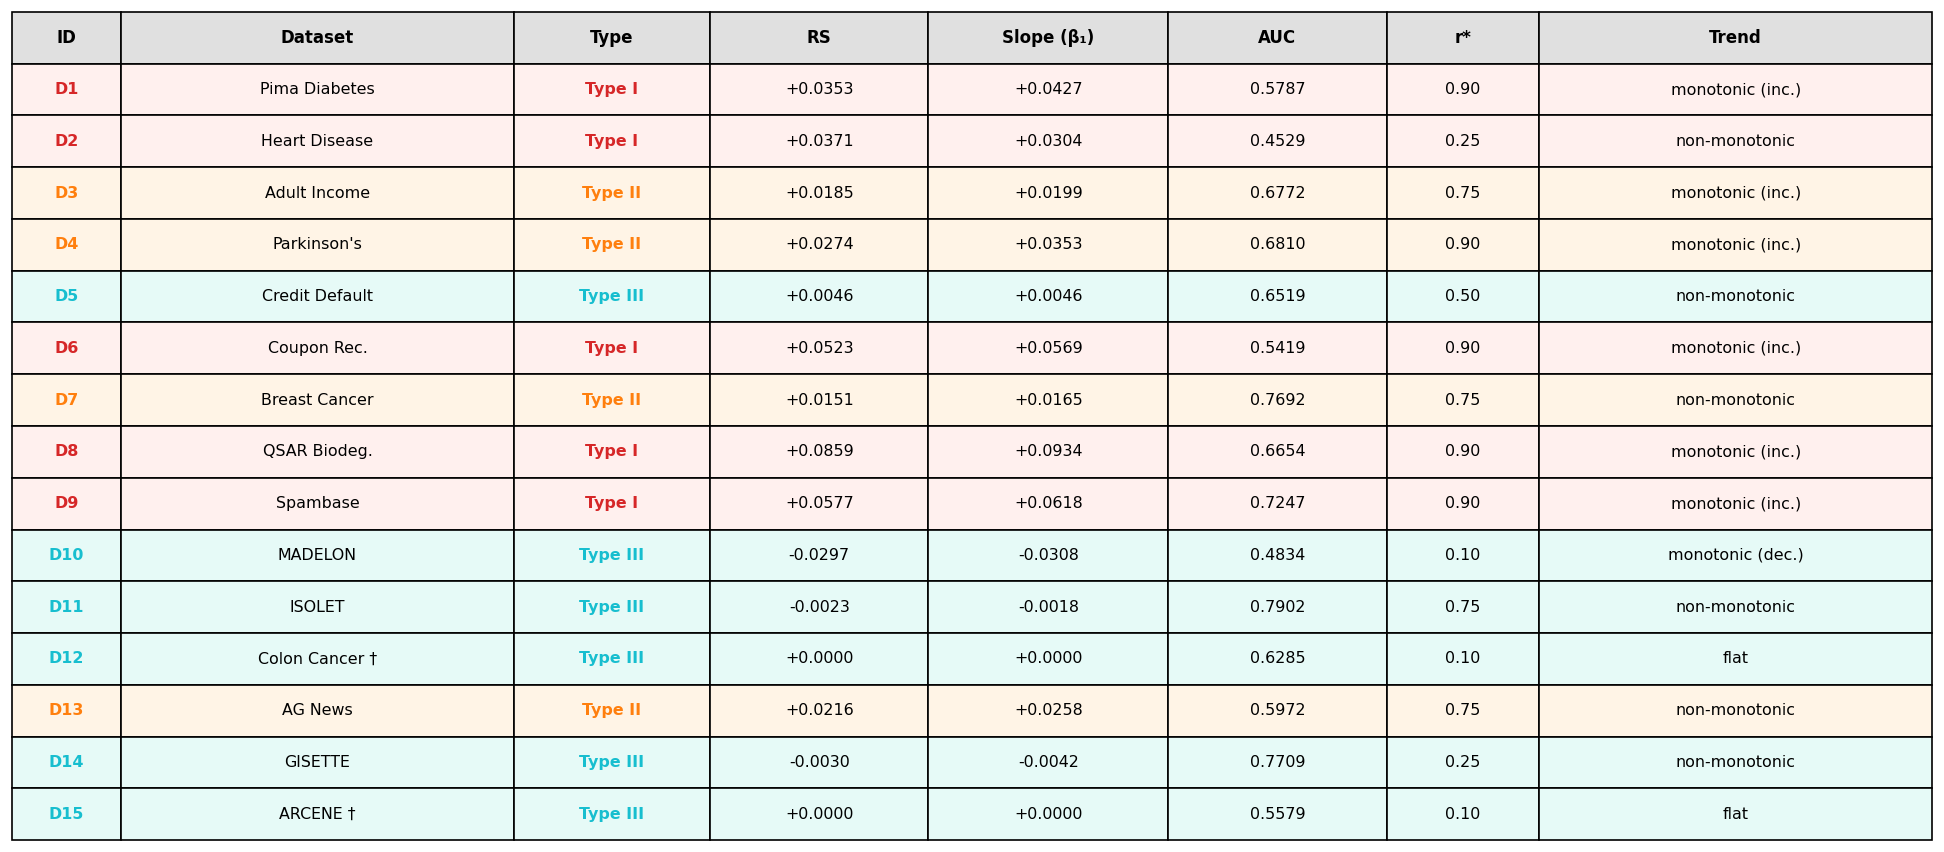


Saved: table5_extended_metrics.png


In [20]:
# =============================================================================
# SECTION 5.4 — TABLE 5: EXTENDED CHARACTERIZATION OF RETENTION-ACCURACY BEHAVIOR
# Requires: raw, RANK_CONSTRAINED, DATASETS already defined.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("Section 5.4 - Extended Characterization Verification")
print("=" * 70)

ok = raw[raw["status"] == "OK"]
RET = sorted(ok["retention_ratio_requested"].unique())

# -----------------------------------------------------------------------------
# DATASET FULL NAMES (consistent with prior sections)
# -----------------------------------------------------------------------------
DATASET_FULLNAMES = {
    "D1": "Pima Diabetes",       "D2": "Heart Disease",       "D3": "Adult Income",
    "D4": "Parkinson's",         "D5": "Credit Default",      "D6": "Coupon Rec.",
    "D7": "Breast Cancer",       "D8": "QSAR Biodeg.",        "D9": "Spambase",
    "D10": "MADELON",            "D11": "ISOLET",             "D12": "Colon Cancer",
    "D13": "AG News",            "D14": "GISETTE",            "D15": "ARCENE",
}

# -----------------------------------------------------------------------------
# HELPER FUNCTIONS
# -----------------------------------------------------------------------------
def get_curve(did):
    """Mean accuracy at each retention level for one dataset."""
    vals = []
    for r in RET:
        v = ok[(ok["dataset_id"] == did) &
               np.isclose(ok["retention_ratio_requested"], r)]["accuracy"]
        vals.append(v.mean())
    return np.array(vals)

def compute_auc(vals):
    """Area under retention-accuracy curve (trapezoidal rule)."""
    # Handle both old (trapz) and new (trapezoid) numpy
    try:
        return np.trapezoid(vals, x=RET)
    except AttributeError:
        return np.trapz(vals, x=RET)

def compute_slope(vals):
    """OLS slope coefficient (linear trend across retention levels)."""
    x = np.array(RET)
    y = np.array(vals)
    slope, _ = np.polyfit(x, y, 1)
    return slope

def compute_rs(vals):
    """RS = A(0.90) - A(0.10) — endpoint difference."""
    return vals[-1] - vals[0]

def compute_r_star(vals):
    """Empirically optimal retention level (smallest in case of ties)."""
    return RET[int(np.argmax(vals))]

def get_type(rs):
    """Regime assignment from Section 3.5."""
    if rs > 0.030:
        return "Type I"
    elif rs > 0.005:
        return "Type II"
    else:
        return "Type III"

def detect_trend(vals, tol=1e-4):
    """Classify retention-accuracy trend with numerical tolerance."""
    diff = np.diff(vals)
    if np.all(np.abs(diff) < tol):
        return "flat"
    if np.all(diff > -tol):
        return "monotonic (inc.)"
    if np.all(diff < tol):
        return "monotonic (dec.)"
    return "non-monotonic"

# -----------------------------------------------------------------------------
# COMPUTE METRICS PER DATASET
# -----------------------------------------------------------------------------
rows = []

print("\n[Verification Output]")
print(f"{'ID':<5}{'Type':<10}{'RS':>9}{'Slope':>9}{'AUC':>9}{'r*':>7}  Trend")
print("-" * 70)

for did in sorted(DATASETS.keys(), key=lambda x: int(x[1:])):
    vals = get_curve(did)

    rs     = compute_rs(vals)
    slope  = compute_slope(vals)
    auc    = compute_auc(vals)
    r_star = compute_r_star(vals)
    trend  = detect_trend(vals)

    # Rank-constrained override
    if did in RANK_CONSTRAINED:
        dtype = "Type III"
        trend = "flat"
    else:
        dtype = get_type(rs)

    print(f"{did:<5}{dtype:<10}{rs:>+9.4f}{slope:>+9.4f}{auc:>9.4f}{r_star:>7.2f}  {trend}")
    rows.append([did, dtype, rs, slope, auc, r_star, trend])

# -----------------------------------------------------------------------------
# COUNTS FOR PAPER TEXT
# -----------------------------------------------------------------------------
non_mono = [r[0] for r in rows if r[6] == "non-monotonic"]
flat     = [r[0] for r in rows if r[6] == "flat"]
mono_inc = [r[0] for r in rows if r[6] == "monotonic (inc.)"]
mono_dec = [r[0] for r in rows if r[6] == "monotonic (dec.)"]

print("\n--- TREND COUNTS FOR SECTION 5.4 TEXT ---")
print(f"Monotonic increasing : {len(mono_inc)}  {mono_inc}")
print(f"Monotonic decreasing : {len(mono_dec)}  {mono_dec}")
print(f"Non-monotonic        : {len(non_mono)}  {non_mono}")
print(f"Flat                 : {len(flat)}  {flat}")

# r* distribution
print("\n--- r* DISTRIBUTION ---")
r_star_counts = {}
for r in rows:
    r_star_counts[r[5]] = r_star_counts.get(r[5], 0) + 1
for rv in sorted(r_star_counts.keys()):
    print(f"r* = {rv:.2f} : {r_star_counts[rv]} datasets")

# =============================================================================
# TABLE PLOT — STYLED TO MATCH PRIOR TABLES
# =============================================================================

col_labels = ["ID", "Dataset", "Type", "RS", "Slope (\u03b2\u2081)", "AUC", "r*", "Trend"]

type_row_colors = {
    "Type I":   "#FFF0EE",
    "Type II":  "#FFF4E6",
    "Type III": "#E6FAF7"
}
type_txt_colors = {
    "Type I":   "#d62728",
    "Type II":  "#ff7f0e",
    "Type III": "#17becf"
}

table_data = []
for r in rows:
    did, dtype, rs, slope, auc, r_star, trend = r
    name = DATASET_FULLNAMES[did]
    rc_tag = " \u2020" if did in RANK_CONSTRAINED else ""

    table_data.append([
        did,
        name + rc_tag,
        dtype,
        f"{rs:+.4f}",
        f"{slope:+.4f}",
        f"{auc:.4f}",
        f"{r_star:.2f}",
        trend
    ])

# Row coloring by regime
cell_colors = []
for r in rows:
    cell_colors.append([type_row_colors[r[1]]] * len(col_labels))

# Figure
fig, ax = plt.subplots(figsize=(16, 7.5))
ax.set_position([0, 0.05, 1, 0.92])
ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=cell_colors,
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)

# Column widths
col_widths = [0.05, 0.18, 0.09, 0.10, 0.11, 0.10, 0.07, 0.18]
for j, w in enumerate(col_widths):
    for i in range(len(table_data) + 1):
        table[i, j].set_width(w)

# Header styling
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#E0E0E0")
    table[0, j].set_text_props(fontweight="bold", fontsize=10)

# Color the ID and Type columns by regime
for i, r in enumerate(rows):
    dtype = r[1]
    c = type_txt_colors[dtype]
    table[i + 1, 0].set_text_props(color=c, fontweight="bold")
    table[i + 1, 2].set_text_props(color=c, fontweight="bold")

plt.savefig("table5_extended_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: table5_extended_metrics.png")

Section 5.5 - Table 6 (PCA Explained Variance)
D1    Pima Diabetes          Type I    RS=+0.0353  V10=0.2619 V25=0.4790 V50=0.7157 V75=0.8963 V90=0.9499
D2    Heart Disease          Type I    RS=+0.0371  V10=0.2405 V25=0.4627 V50=0.6911 V75=0.8661 V90=0.9439
D3    Adult Income           Type II   RS=+0.0185  V10=0.7484 V25=0.9263 V50=0.9929 V75=0.9990 V90=0.9999
D4    Parkinson's            Type II   RS=+0.0274  V10=0.7080 V25=0.8895 V50=0.9892 V75=0.9996 V90=1.0000
D5    Credit Default         Type III  RS=+0.0046  V10=0.8347 V25=0.9496 V50=0.9942 V75=0.9998 V90=1.0000
D6    Coupon Rec.            Type I    RS=+0.0523  V10=0.5255 V25=0.7732 V50=0.9527 V75=0.9978 V90=1.0000
D7    Breast Cancer          Type II   RS=+0.0151  V10=0.7253 V25=0.9110 V50=0.9870 V75=0.9977 V90=0.9999
D8    QSAR Biodeg.           Type I    RS=+0.0859  V10=0.5023 V25=0.7536 V50=0.9354 V75=0.9880 V90=0.9980
D9    Spambase               Type I    RS=+0.0577  V10=0.2662 V25=0.4632 V50=0.7056 V75=0.8949 V90=0.9756

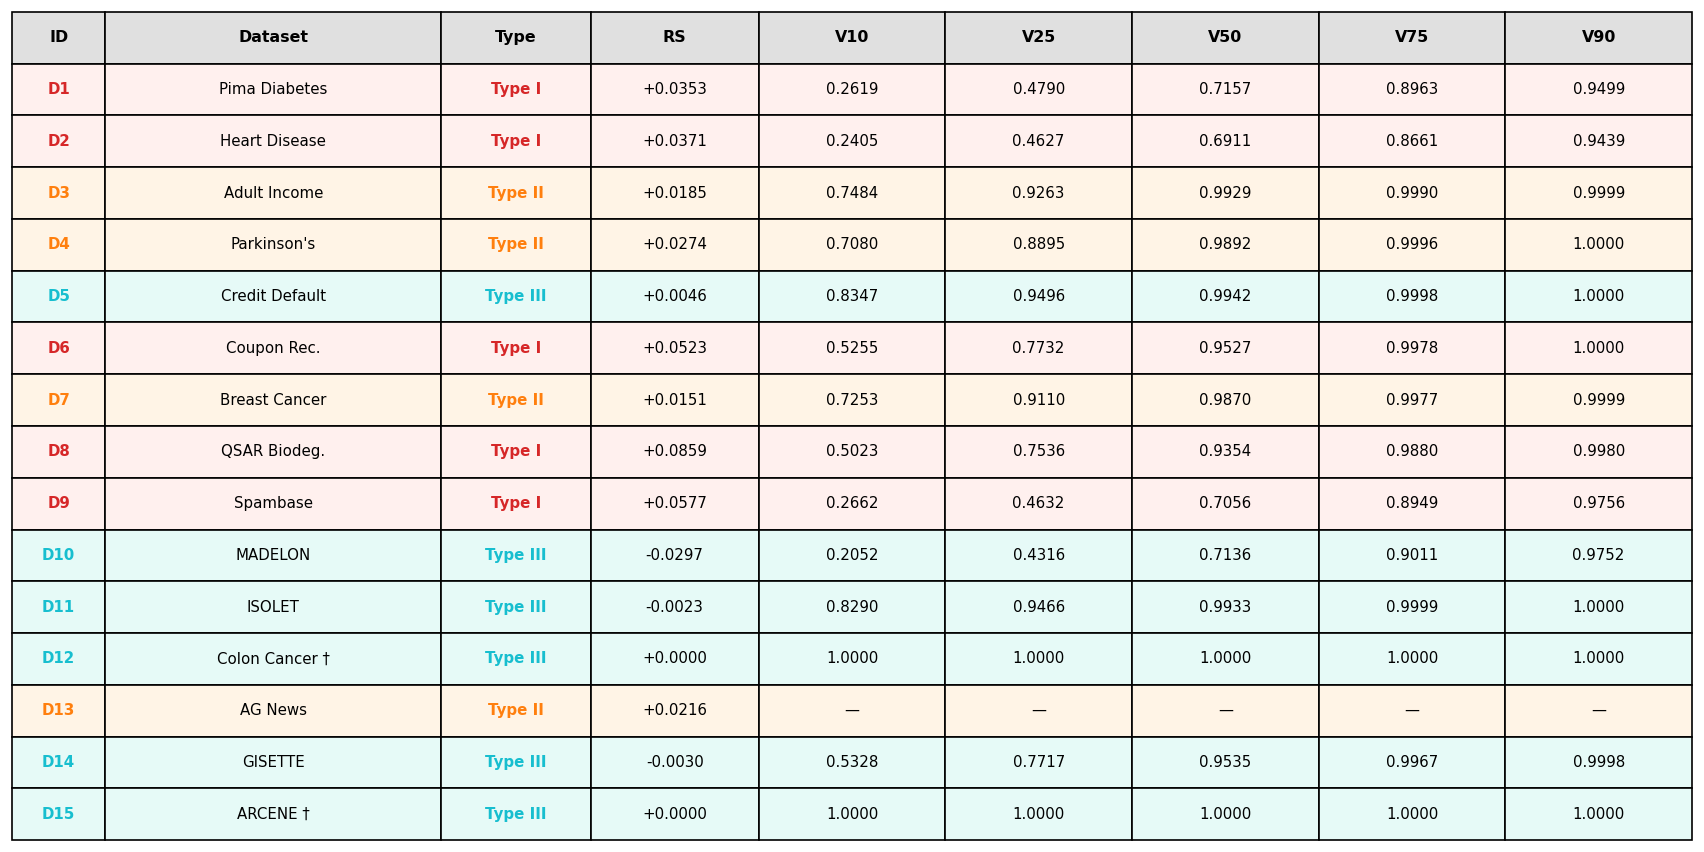


Saved: table6_pca_variance.png

Section 5.5 - Figure 5 (Mean PCA Variance by Regime)
Type I: ['0.359', '0.586', '0.800', '0.929', '0.973']
Type II: ['0.727', '0.909', '0.990', '0.999', '1.000']
Type III: ['0.600', '0.775', '0.914', '0.974', '0.994']


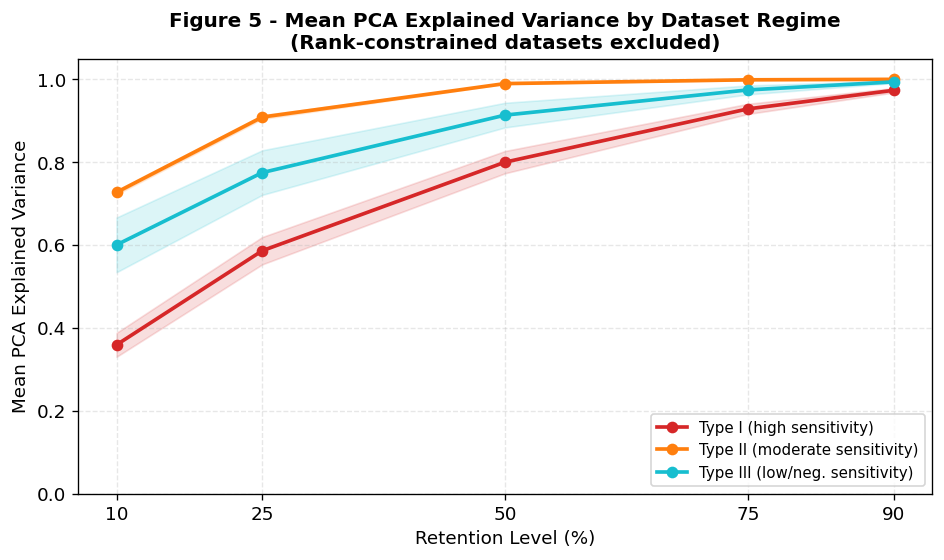

Saved: figure5_pca_variance_curves.png

Section 5.5 - Table 7 (Welch t-tests, Holm-Bonferroni)

RAW T-TEST RESULTS
------------------------------------------------------------

Retention = 0.10
  Type I vs II: means 0.359 vs 0.727 | t=-5.71, p=0.0038 (n=5 vs 3)
  Type I vs III: means 0.359 vs 0.600 | t=-1.49, p=0.2101 (n=5 vs 4)
  Type II vs III: means 0.727 vs 0.600 | t=+0.85, p=0.4590 (n=3 vs 4)

Retention = 0.25
  Type I vs II: means 0.586 vs 0.909 | t=-4.41, p=0.0106 (n=5 vs 3)
  Type I vs III: means 0.586 vs 0.775 | t=-1.33, p=0.2404 (n=5 vs 4)
  Type II vs III: means 0.909 vs 0.775 | t=+1.10, p=0.3517 (n=3 vs 4)

Retention = 0.50
  Type I vs II: means 0.800 vs 0.990 | t=-3.21, p=0.0324 (n=5 vs 3)
  Type I vs III: means 0.800 vs 0.914 | t=-1.27, p=0.2482 (n=5 vs 4)
  Type II vs III: means 0.990 vs 0.914 | t=+1.13, p=0.3410 (n=3 vs 4)

Retention = 0.75
  Type I vs II: means 0.929 vs 0.999 | t=-2.62, p=0.0590 (n=5 vs 3)
  Type I vs III: means 0.929 vs 0.974 | t=-1.26, p=0.2478 (n=5 

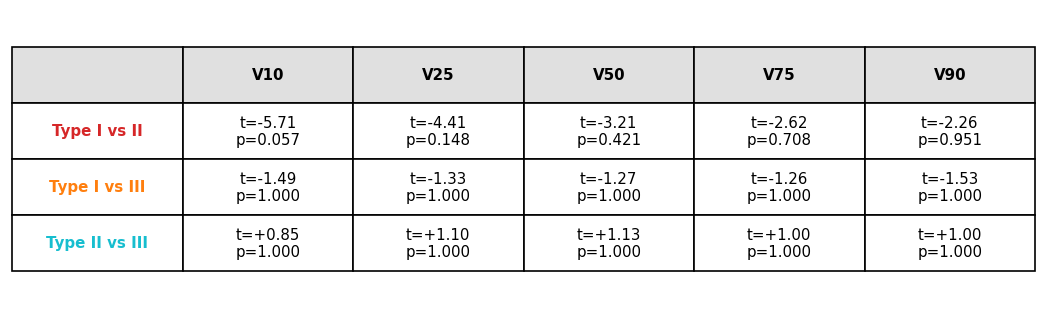


Saved: table7_pca_ttests_final.png

Section 5.5 outputs complete.


In [21]:
# =============================================================================
# SECTION 5.5 - EXPLAINED VARIANCE AND COMPRESSION SENSITIVITY
# Produces: Table 6 (PCA variance per dataset), Figure 5 (regime curves),
#           Table 7 (Welch t-tests with Holm-Bonferroni correction)
# Paste this as a new cell AFTER your Section 5.4 cell.
# Requires: raw, RANK_CONSTRAINED, type_I, type_II, type_III already defined.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
ok = raw[raw["status"] == "OK"]
retention_levels = [0.10, 0.25, 0.50, 0.75, 0.90]
level_labels = ["V10", "V25", "V50", "V75", "V90"]

# -----------------------------------------------------------------------------
# TYPE MAP (built from regime lists for robustness)
# -----------------------------------------------------------------------------
type_map = {}
for d in type_I:   type_map[d] = "I"
for d in type_II:  type_map[d] = "II"
for d in type_III: type_map[d] = "III"

# -----------------------------------------------------------------------------
# DATASET FULL NAMES (consistent with prior sections)
# -----------------------------------------------------------------------------
DATASET_FULLNAMES = {
    "D1":  "Pima Diabetes",       "D2":  "Heart Disease",       "D3":  "Adult Income",
    "D4":  "Parkinson's",         "D5":  "Credit Default",      "D6":  "Coupon Rec.",
    "D7":  "Breast Cancer",       "D8":  "QSAR Biodeg.",        "D9":  "Spambase",
    "D10": "MADELON",             "D11": "ISOLET",              "D12": "Colon Cancer",
    "D13": "AG News",             "D14": "GISETTE",             "D15": "ARCENE",
}

# -----------------------------------------------------------------------------
# COLOR SCHEME (consistent across paper)
# -----------------------------------------------------------------------------
type_row_colors = {"I": "#FFF0EE", "II": "#FFF4E6", "III": "#E6FAF7"}
type_txt_colors = {"I": "#d62728", "II": "#ff7f0e", "III": "#17becf"}


# =============================================================================
# TABLE 6 - PCA EXPLAINED VARIANCE PER DATASET
# =============================================================================
print("=" * 70)
print("Section 5.5 - Table 6 (PCA Explained Variance)")
print("=" * 70)

# -----------------------------------------------------------------------------
# COMPUTE PER-DATASET VARIANCE AND RS
# -----------------------------------------------------------------------------
v_all_rows = []
for did in [f"D{i}" for i in range(1, 16)]:
    sub = ok[(ok["dataset_id"] == did) & (ok["method"] == "PCA")]
    dtype = type_map.get(did, "?")
    name = DATASET_FULLNAMES[did]

    # Compute RS directly from raw
    acc_vals = []
    for r in retention_levels:
        v = ok[(ok["dataset_id"] == did) &
               np.isclose(ok["retention_ratio_requested"], r)]["accuracy"].dropna()
        acc_vals.append(v.mean() if not v.empty else np.nan)
    rs = acc_vals[-1] - acc_vals[0] if not np.isnan(acc_vals[0]) else np.nan

    # Mark rank-constrained datasets
    if did in RANK_CONSTRAINED:
        name = name + " \u2020"

    row = [did, name, f"Type {dtype}", f"{rs:+.4f}"]

    # PCA explained variance at each retention level
    for r in retention_levels:
        vals = sub.loc[
            np.isclose(sub["retention_ratio_requested"], r),
            "var_explained"
        ].dropna()
        row.append(f"{vals.mean():.4f}" if not vals.empty else "\u2014")

    v_all_rows.append(row)
    print(f"{did:<5} {name:<22} Type {dtype:<4} RS={rs:+.4f}  "
          f"V10={row[4]} V25={row[5]} V50={row[6]} V75={row[7]} V90={row[8]}")

# -----------------------------------------------------------------------------
# RENDER TABLE 6
# -----------------------------------------------------------------------------
col_labels = ["ID", "Dataset", "Type", "RS"] + level_labels

row_colors = []
for row in v_all_rows:
    dtype = row[2].replace("Type ", "")
    base = type_row_colors.get(dtype, "white")
    row_colors.append([base] * len(col_labels))

fig, ax = plt.subplots(figsize=(14, 7.5))
ax.set_position([0, 0.05, 1, 0.92])
ax.axis("off")

table = ax.table(
    cellText=v_all_rows,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=row_colors,
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

# Column widths
col_widths = [0.05, 0.18, 0.08, 0.09, 0.10, 0.10, 0.10, 0.10, 0.10]
for j, w in enumerate(col_widths):
    for i in range(len(v_all_rows) + 1):
        table[i, j].set_width(w)

# Header styling
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#E0E0E0")
    table[0, j].set_text_props(fontweight="bold", fontsize=9.5)

# ID and Type column coloring
for i, row in enumerate(v_all_rows):
    dtype = row[2].replace("Type ", "")
    c = type_txt_colors.get(dtype, "black")
    table[i + 1, 0].set_text_props(color=c, fontweight="bold")
    table[i + 1, 2].set_text_props(color=c, fontweight="bold")

plt.savefig("table6_pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: table6_pca_variance.png")


# =============================================================================
# FIGURE 5 - MEAN PCA EXPLAINED VARIANCE BY REGIME
# =============================================================================
print("\n" + "=" * 70)
print("Section 5.5 - Figure 5 (Mean PCA Variance by Regime)")
print("=" * 70)

# -----------------------------------------------------------------------------
# COMPUTE REGIME-LEVEL MEANS AND CIs
# -----------------------------------------------------------------------------
x = np.array(retention_levels) * 100
colors = {"I": "#d62728", "II": "#ff7f0e", "III": "#17becf"}
labels = {
    "I":   "Type I (high sensitivity)",
    "II":  "Type II (moderate sensitivity)",
    "III": "Type III (low/neg. sensitivity)"
}

means = {}
cis = {}
for dtype in ["I", "II", "III"]:
    dids = [d for d, t in type_map.items() if t == dtype and d not in RANK_CONSTRAINED]

    mean_vals, ci_vals = [], []
    for r in retention_levels:
        vals = ok[
            (ok["dataset_id"].isin(dids)) &
            (ok["method"] == "PCA") &
            np.isclose(ok["retention_ratio_requested"], r)
        ]["var_explained"].dropna()

        mu = vals.mean()
        ci = 1.96 * vals.std() / np.sqrt(len(vals)) if len(vals) > 1 else 0
        mean_vals.append(mu)
        ci_vals.append(ci)

    means[dtype] = np.array(mean_vals)
    cis[dtype]   = np.array(ci_vals)
    print(f"Type {dtype}: {[f'{v:.3f}' for v in mean_vals]}")

# -----------------------------------------------------------------------------
# RENDER FIGURE 5
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.8))

for dtype in ["I", "II", "III"]:
    ax.plot(x, means[dtype],
            color=colors[dtype], lw=2.2, marker="o",
            label=labels[dtype])
    ax.fill_between(x,
                    means[dtype] - cis[dtype],
                    means[dtype] + cis[dtype],
                    color=colors[dtype], alpha=0.15)

ax.set_xlabel("Retention Level (%)", fontsize=11)
ax.set_ylabel("Mean PCA Explained Variance", fontsize=11)
ax.set_title(
    "Figure 5 - Mean PCA Explained Variance by Dataset Regime\n"
    "(Rank-constrained datasets excluded)",
    fontsize=12, fontweight="bold"
)
ax.set_xticks(x)
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(fontsize=9, loc="lower right")
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("figure5_pca_variance_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure5_pca_variance_curves.png")


# =============================================================================
# TABLE 7 - WELCH T-TESTS WITH HOLM-BONFERRONI CORRECTION
# =============================================================================
print("\n" + "=" * 70)
print("Section 5.5 - Table 7 (Welch t-tests, Holm-Bonferroni)")
print("=" * 70)

# -----------------------------------------------------------------------------
# HELPER: DATASET-LEVEL AGGREGATION
# -----------------------------------------------------------------------------
def get_dataset_means(dataset_list, r):
    vals = []
    for d in dataset_list:
        sub = ok[
            (ok["dataset_id"] == d) &
            (ok["method"] == "PCA") &
            np.isclose(ok["retention_ratio_requested"], r)
        ]["var_explained"].dropna()
        if len(sub) > 0:
            vals.append(sub.mean())
    return np.array(vals)

# -----------------------------------------------------------------------------
# GROUPS (rank-constrained excluded)
# -----------------------------------------------------------------------------
groups = {
    "I":   [d for d, t in type_map.items() if t == "I"   and d not in RANK_CONSTRAINED],
    "II":  [d for d, t in type_map.items() if t == "II"  and d not in RANK_CONSTRAINED],
    "III": [d for d, t in type_map.items() if t == "III" and d not in RANK_CONSTRAINED],
}
pairs = [("I", "II"), ("I", "III"), ("II", "III")]
pair_names = ["Type I vs II", "Type I vs III", "Type II vs III"]

# -----------------------------------------------------------------------------
# COMPUTE RAW WELCH T-TESTS
# -----------------------------------------------------------------------------
results = {p: [] for p in pairs}

print("\nRAW T-TEST RESULTS")
print("-" * 60)
for r in retention_levels:
    print(f"\nRetention = {r:.2f}")
    for (a, b) in pairs:
        va = get_dataset_means(groups[a], r)
        vb = get_dataset_means(groups[b], r)

        if len(va) >= 2 and len(vb) >= 2:
            t, pval = ttest_ind(va, vb, equal_var=False)
            print(f"  Type {a} vs {b}: means {va.mean():.3f} vs {vb.mean():.3f} "
                  f"| t={t:+.2f}, p={pval:.4f} (n={len(va)} vs {len(vb)})")
        else:
            t, pval = np.nan, np.nan

        results[(a, b)].append((t, pval))

# -----------------------------------------------------------------------------
# HOLM-BONFERRONI CORRECTION (with monotonicity enforcement)
# -----------------------------------------------------------------------------
all_p = []
index_map = []
for pair in pairs:
    for idx, (t, p) in enumerate(results[pair]):
        all_p.append(p)
        index_map.append((pair, idx))

sorted_idx = np.argsort(all_p)
m = len(all_p)
adjusted = [None] * m
prev = 0

for rank, idx in enumerate(sorted_idx):
    raw_p = all_p[idx]
    corrected = min((m - rank) * raw_p, 1.0)
    corrected = max(corrected, prev)
    adjusted[idx] = corrected
    prev = corrected

corrected_results = {p: [] for p in pairs}
for i, (pair, idx) in enumerate(index_map):
    t, p = results[pair][idx]
    corrected_results[pair].append((t, p, adjusted[i]))

# -----------------------------------------------------------------------------
# PRINT CORRECTED RESULTS
# -----------------------------------------------------------------------------
print("\nHOLM-BONFERRONI CORRECTED")
print("-" * 60)
for pair, name in zip(pairs, pair_names):
    print(f"{name}:")
    for lbl, (t, p_raw, p_corr) in zip(level_labels, corrected_results[pair]):
        sig = "*" if (not np.isnan(p_corr) and p_corr < 0.05) else ""
        print(f"  {lbl}: t={t:+.2f}, raw_p={p_raw:.4f}, adj_p={p_corr:.4f} {sig}")

# -----------------------------------------------------------------------------
# RENDER TABLE 7
# -----------------------------------------------------------------------------
col_labels_t7 = [""] + level_labels
row_data, row_cell_colors = [], []

for pair, name in zip(pairs, pair_names):
    row = [name]
    colors_row = ["white"]

    for t, p_raw, p_corr in corrected_results[pair]:
        if np.isnan(p_corr):
            row.append("\u2014")
            colors_row.append("white")
        else:
            sig = p_corr < 0.05
            row.append(f"t={t:+.2f}\np={p_corr:.3f}{' *' if sig else ''}")
            colors_row.append("#FDECEA" if sig else "white")

    row_data.append(row)
    row_cell_colors.append(colors_row)

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis("off")

table = ax.table(
    cellText=row_data,
    colLabels=col_labels_t7,
    cellLoc="center",
    loc="center",
    cellColours=row_cell_colors
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.8)

# Header styling
for j in range(len(col_labels_t7)):
    table[0, j].set_facecolor("#E0E0E0")
    table[0, j].set_text_props(fontweight="bold")

# Row label colors (consistent with paper palette)
row_label_palette = ["#d62728", "#ff7f0e", "#17becf"]
for i, c in enumerate(row_label_palette):
    table[i + 1, 0].set_text_props(color=c, fontweight="bold")

plt.savefig("table7_pca_ttests_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: table7_pca_ttests_final.png")
print("\nSection 5.5 outputs complete.")

Section 5.6 - Table 8 (Group-Level Retention Accuracy)

[Verification - Group Means (rank-constrained excluded)]
Type          n       10%       25%       50%       75%       90%
-----------------------------------------------------------------
Type I         5    0.6994    0.7357    0.7454    0.7514    0.7530
Type II        4    0.8362    0.8464    0.8541    0.8568    0.8569
Type III       4    0.8477    0.8436    0.8419    0.8415    0.8401

[Key Numbers for Section 5.6 Text]
Type I: @10% = 0.699, @90% = 0.753, direction = increases (+0.0537)
Type II: @10% = 0.836, @90% = 0.857, direction = increases (+0.0206)
Type III: @10% = 0.848, @90% = 0.840, direction = declines (-0.0076)

[MADELON (D10) - Dataset-Level Verification]
  r=0.10: mean accuracy = 0.6276  (n=75 configs)
  r=0.25: mean accuracy = 0.6071  (n=75 configs)
  r=0.50: mean accuracy = 0.6006  (n=75 configs)
  r=0.75: mean accuracy = 0.5998  (n=75 configs)
  r=0.90: mean accuracy = 0.5979  (n=75 configs)

  Configs showing im

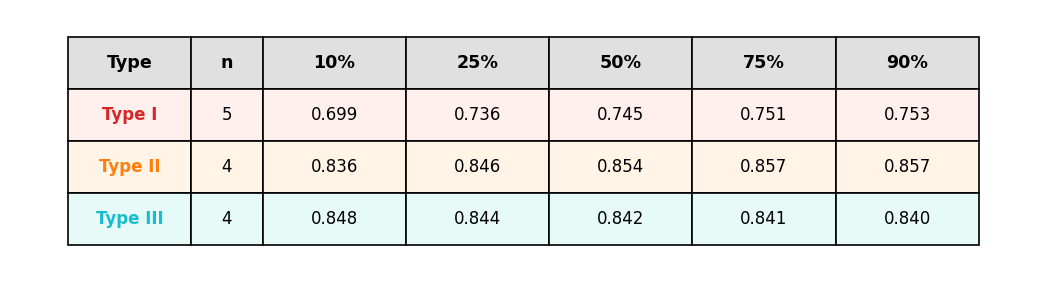


Saved: table8_group_retention.png

Section 5.6 outputs complete.


In [22]:
# =============================================================================
# SECTION 5.6 - FAILURE MODE I: COMPRESSION-AS-REGULARIZATION
# Produces: Table 8 (group-level mean accuracy across retention levels)
# Requires: raw, RANK_CONSTRAINED, type_I, type_II, type_III already defined.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
ok = raw[raw["status"] == "OK"]
retention_levels = [0.10, 0.25, 0.50, 0.75, 0.90]
level_labels = ["10%", "25%", "50%", "75%", "90%"]

# -----------------------------------------------------------------------------
# TYPE MAP (built from regime lists for robustness)
# -----------------------------------------------------------------------------
type_map = {}
for d in type_I:   type_map[d] = "I"
for d in type_II:  type_map[d] = "II"
for d in type_III: type_map[d] = "III"

# -----------------------------------------------------------------------------
# COLOR SCHEME (consistent across paper)
# -----------------------------------------------------------------------------
type_row_colors = {"I": "#FFF0EE", "II": "#FFF4E6", "III": "#E6FAF7"}
type_txt_colors = {"I": "#d62728", "II": "#ff7f0e", "III": "#17becf"}

# =============================================================================
# TABLE 8 - GROUP-LEVEL MEAN ACCURACY ACROSS RETENTION LEVELS
# =============================================================================
print("=" * 70)
print("Section 5.6 - Table 8 (Group-Level Retention Accuracy)")
print("=" * 70)

# -----------------------------------------------------------------------------
# GROUP DATASETS (rank-constrained excluded)
# -----------------------------------------------------------------------------
groups = {
    "I":   [d for d, t in type_map.items() if t == "I"   and d not in RANK_CONSTRAINED],
    "II":  [d for d, t in type_map.items() if t == "II"  and d not in RANK_CONSTRAINED],
    "III": [d for d, t in type_map.items() if t == "III" and d not in RANK_CONSTRAINED],
}

# -----------------------------------------------------------------------------
# COMPUTE GROUP-LEVEL MEANS
# -----------------------------------------------------------------------------
group_means = {}
for g in ["I", "II", "III"]:
    group_means[g] = []
    for r in retention_levels:
        vals = ok[
            (ok["dataset_id"].isin(groups[g])) &
            np.isclose(ok["retention_ratio_requested"], r)
        ]["accuracy"].dropna()
        group_means[g].append(vals.mean())

# -----------------------------------------------------------------------------
# VERIFICATION PRINT
# -----------------------------------------------------------------------------
print("\n[Verification - Group Means (rank-constrained excluded)]")
print(f"{'Type':<10}{'n':>5}  " + "  ".join(f"{l:>8}" for l in level_labels))
print("-" * 65)
for g in ["I", "II", "III"]:
    vals_str = "  ".join(f"{v:>8.4f}" for v in group_means[g])
    print(f"Type {g:<6}{len(groups[g]):>5}  {vals_str}")

# Key numbers for paper text
print("\n[Key Numbers for Section 5.6 Text]")
for g in ["I", "II", "III"]:
    v10 = group_means[g][0]
    v90 = group_means[g][-1]
    direction = "declines" if v90 < v10 else "increases"
    print(f"Type {g}: @10% = {v10:.3f}, @90% = {v90:.3f}, "
          f"direction = {direction} ({v90 - v10:+.4f})")

# MADELON-specific verification
print("\n[MADELON (D10) - Dataset-Level Verification]")
for r in retention_levels:
    vals = ok[(ok["dataset_id"] == "D10") &
              np.isclose(ok["retention_ratio_requested"], r)]["accuracy"].dropna()
    print(f"  r={r:.2f}: mean accuracy = {vals.mean():.4f}  (n={len(vals)} configs)")

# Count how many method-classifier configs show improvement
sub10 = ok[(ok["dataset_id"] == "D10") & np.isclose(ok["retention_ratio_requested"], 0.10)]
sub90 = ok[(ok["dataset_id"] == "D10") & np.isclose(ok["retention_ratio_requested"], 0.90)]

configs = sub10[["method", "classifier"]].drop_duplicates()
improvement_count = 0
total_count = 0
for _, row in configs.iterrows():
    a10 = sub10[(sub10["method"] == row["method"]) &
                (sub10["classifier"] == row["classifier"])]["accuracy"].mean()
    a90 = sub90[(sub90["method"] == row["method"]) &
                (sub90["classifier"] == row["classifier"])]["accuracy"].mean()
    if not (np.isnan(a10) or np.isnan(a90)):
        total_count += 1
        if a10 > a90:
            improvement_count += 1

print(f"\n  Configs showing improvement at 10% vs 90%: "
      f"{improvement_count} of {total_count}")

# -----------------------------------------------------------------------------
# BUILD TABLE DATA
# -----------------------------------------------------------------------------
col_labels = ["Type", "n"] + level_labels

table_data = []
for g in ["I", "II", "III"]:
    row = [f"Type {g}", str(len(groups[g]))]
    row += [f"{v:.3f}" for v in group_means[g]]
    table_data.append(row)

row_colors = [
    [type_row_colors[g]] * len(col_labels)
    for g in ["I", "II", "III"]
]

# -----------------------------------------------------------------------------
# RENDER TABLE 8
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=row_colors
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.6)

# Column widths
col_widths = [0.12, 0.07, 0.14, 0.14, 0.14, 0.14, 0.14]
for j, w in enumerate(col_widths):
    for i in range(len(table_data) + 1):
        table[i, j].set_width(w)

# Header styling
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#E0E0E0")
    table[0, j].set_text_props(fontweight="bold", fontsize=10.5)

# Type column coloring
for i, g in enumerate(["I", "II", "III"]):
    table[i + 1, 0].set_text_props(color=type_txt_colors[g], fontweight="bold")

plt.savefig("table8_group_retention.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: table8_group_retention.png")
print("\nSection 5.6 outputs complete.")

Section 5.7 - Failure Mode II Verification (D13 AG News)

[1] AUTOENCODER (AE)
--------------------------------------------------
Mean accuracy     : 0.3749
Mean recon MSE    : 0.000331
N configurations  : 75

[2] ALL METHODS ON D13 (mean accuracy)
--------------------------------------------------
  AE                  : 0.3749  (n=75)
  RFE                 : 0.8431  (n=75)
  SelectKBest         : 0.8470  (n=75)
  TruncatedSVD        : 0.8572  (n=75)
  UMAP                : 0.8017  (n=75)

  Best method : TruncatedSVD (0.8572)
  Gap (best - AE): 0.4823 (48.23 percentage points)

[3] PCA / TruncatedSVD on D13
--------------------------------------------------
  Mean accuracy   : 0.8572
  Gap (PCA - AE)  : 0.4823 (48.23 percentage points)

[4] RANDOM BASELINE
--------------------------------------------------
  Random baseline   : 0.250  (4-class task)
  AE above baseline : 0.1249

[5] AE ACCURACY ACROSS RETENTION LEVELS
--------------------------------------------------
  r=0.10  ( 10%

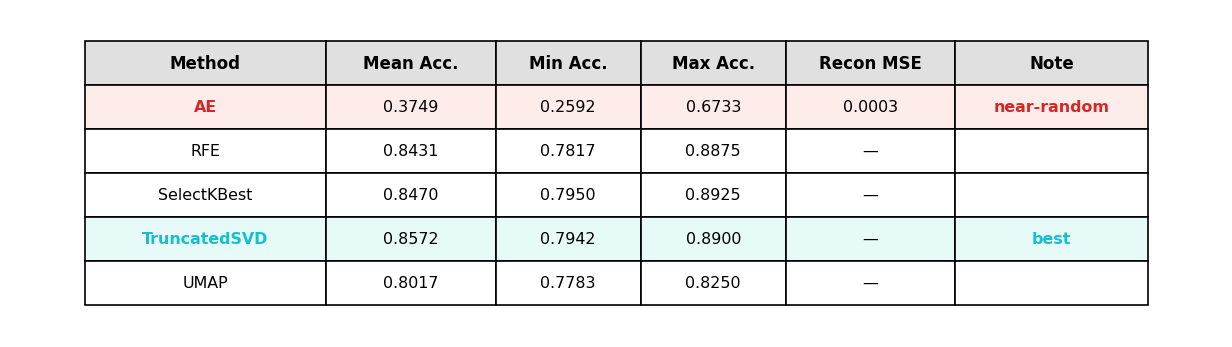


Saved: table9_d13_method_comparison.png

Section 5.7 outputs complete.


In [23]:
# =============================================================================
# SECTION 5.7 - FAILURE MODE II: RECONSTRUCTION-DISCRIMINABILITY DECOUPLING
# Produces: Verification output + Table 9 (method comparison on D13)

# Requires: raw, RANK_CONSTRAINED, type_I, type_II, type_III already defined.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
ok = raw[raw["status"] == "OK"].copy()
retention_levels = [0.10, 0.25, 0.50, 0.75, 0.90]

# -----------------------------------------------------------------------------
# COLOR SCHEME (consistent across paper)
# -----------------------------------------------------------------------------
type_row_colors = {"I": "#FFF0EE", "II": "#FFF4E6", "III": "#E6FAF7"}
type_txt_colors = {"I": "#d62728", "II": "#ff7f0e", "III": "#17becf"}

# =============================================================================
# SECTION 5.7 - VERIFICATION
# =============================================================================
print("=" * 70)
print("Section 5.7 - Failure Mode II Verification (D13 AG News)")
print("=" * 70)

# -----------------------------------------------------------------------------
# FILTER D13
# -----------------------------------------------------------------------------
d13 = ok[ok["dataset_id"] == "D13"]

# -----------------------------------------------------------------------------
# [1] AUTOENCODER PERFORMANCE
# -----------------------------------------------------------------------------
ae = d13[d13["method"].str.contains("AE", case=False, na=False)]
ae_acc   = ae["accuracy"].mean()
ae_recon = ae["recon_mse"].mean()

print("\n[1] AUTOENCODER (AE)")
print("-" * 50)
print(f"Mean accuracy     : {ae_acc:.4f}")
print(f"Mean recon MSE    : {ae_recon:.6f}")
print(f"N configurations  : {len(ae)}")

# -----------------------------------------------------------------------------
# [2] ALL METHODS ON D13
# -----------------------------------------------------------------------------
print("\n[2] ALL METHODS ON D13 (mean accuracy)")
print("-" * 50)
method_accs = {}
for method in sorted(d13["method"].unique()):
    vals = d13[d13["method"] == method]["accuracy"].dropna()
    if len(vals) > 0:
        method_accs[method] = vals.mean()
        print(f"  {method:<20}: {vals.mean():.4f}  (n={len(vals)})")

best_method = max(method_accs, key=method_accs.get)
best_acc    = method_accs[best_method]
gap         = best_acc - ae_acc

print(f"\n  Best method : {best_method} ({best_acc:.4f})")
print(f"  Gap (best - AE): {gap:.4f} ({gap * 100:.2f} percentage points)")

# -----------------------------------------------------------------------------
# [3] PCA SPECIFICALLY
# -----------------------------------------------------------------------------
pca = d13[d13["method"].str.contains("PCA", case=False, na=False) |
          d13["method"].str.contains("SVD", case=False, na=False)]
pca_acc = pca["accuracy"].mean()
pca_gap = pca_acc - ae_acc

print(f"\n[3] PCA / TruncatedSVD on D13")
print("-" * 50)
print(f"  Mean accuracy   : {pca_acc:.4f}")
print(f"  Gap (PCA - AE)  : {pca_gap:.4f} ({pca_gap * 100:.2f} percentage points)")

# -----------------------------------------------------------------------------
# [4] RANDOM BASELINE
# -----------------------------------------------------------------------------
n_classes      = len(d13["accuracy"].dropna().index)
random_baseline = 0.25   # 4-class task (AG News)
above_baseline  = ae_acc - random_baseline

print(f"\n[4] RANDOM BASELINE")
print("-" * 50)
print(f"  Random baseline   : {random_baseline:.3f}  (4-class task)")
print(f"  AE above baseline : {above_baseline:.4f}")

# -----------------------------------------------------------------------------
# [5] AE ACROSS RETENTION LEVELS
# -----------------------------------------------------------------------------
print(f"\n[5] AE ACCURACY ACROSS RETENTION LEVELS")
print("-" * 50)
ae_per_retention = []
for r in retention_levels:
    vals = ae[np.isclose(ae["retention_ratio_requested"], r)]["accuracy"].dropna()
    if len(vals) > 0:
        m = vals.mean()
        ae_per_retention.append((r, m))
        print(f"  r={r:.2f}  ({int(r*100):>3}%): {m:.4f}  (n={len(vals)})")

# -----------------------------------------------------------------------------
# [6] AE RECONSTRUCTION MSE ACROSS RETENTION LEVELS
# -----------------------------------------------------------------------------
print(f"\n[6] AE RECONSTRUCTION MSE ACROSS RETENTION LEVELS")
print("-" * 50)
for r in retention_levels:
    vals = ae[np.isclose(ae["retention_ratio_requested"], r)]["recon_mse"].dropna()
    if len(vals) > 0:
        print(f"  r={r:.2f}  ({int(r*100):>3}%): {vals.mean():.6f}  (n={len(vals)})")

# -----------------------------------------------------------------------------
# [7] AE PER-CLASSIFIER BREAKDOWN
# -----------------------------------------------------------------------------
print(f"\n[7] AE PER-CLASSIFIER BREAKDOWN")
print("-" * 50)
for clf in sorted(ae["classifier"].unique()):
    vals = ae[ae["classifier"] == clf]["accuracy"].dropna()
    print(f"  {clf:<12}: {vals.mean():.4f}  (n={len(vals)})")

# -----------------------------------------------------------------------------
# [8] PCA PER-RETENTION LEVEL (for contrast)
# -----------------------------------------------------------------------------
print(f"\n[8] PCA ACCURACY ACROSS RETENTION LEVELS (contrast)")
print("-" * 50)
for r in retention_levels:
    vals = pca[np.isclose(pca["retention_ratio_requested"], r)]["accuracy"].dropna()
    if len(vals) > 0:
        print(f"  r={r:.2f}  ({int(r*100):>3}%): {vals.mean():.4f}  (n={len(vals)})")

# =============================================================================
# TABLE 9 - METHOD COMPARISON ON D13
# =============================================================================
print("\n" + "=" * 70)
print("Section 5.7 - Table 9 (Method Comparison on D13)")
print("=" * 70)

# -----------------------------------------------------------------------------
# BUILD TABLE DATA
# -----------------------------------------------------------------------------
methods_ordered = sorted(d13["method"].unique())
col_labels = ["Method", "Mean Acc.", "Min Acc.", "Max Acc.", "Recon MSE", "Note"]

table_data = []
for method in methods_ordered:
    sub = d13[d13["method"] == method]
    acc_vals  = sub["accuracy"].dropna()
    recon_vals = sub["recon_mse"].dropna()

    mean_acc = f"{acc_vals.mean():.4f}" if len(acc_vals) > 0 else "\u2014"
    min_acc  = f"{acc_vals.min():.4f}"  if len(acc_vals) > 0 else "\u2014"
    max_acc  = f"{acc_vals.max():.4f}"  if len(acc_vals) > 0 else "\u2014"
    recon    = f"{recon_vals.mean():.4f}" if len(recon_vals) > 0 else "\u2014"

    # Flag AE and best method
    note = ""
    if "AE" in method.upper():
        note = "near-random"
    elif method == best_method:
        note = "best"

    table_data.append([method, mean_acc, min_acc, max_acc, recon, note])

# Row colors: highlight AE row
def row_color(method):
    if "AE" in method.upper():
        return "#FDECEA"   # light red — problem method
    if method == best_method:
        return "#E6FAF7"   # light teal — best method
    return "white"

row_colors = [[row_color(row[0])] * len(col_labels) for row in table_data]

# -----------------------------------------------------------------------------
# RENDER TABLE 9
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=row_colors
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2.2)

# Column widths
col_widths = [0.20, 0.14, 0.12, 0.12, 0.14, 0.16]
for j, w in enumerate(col_widths):
    for i in range(len(table_data) + 1):
        table[i, j].set_width(w)

# Header styling
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#E0E0E0")
    table[0, j].set_text_props(fontweight="bold", fontsize=10)

# Highlight AE method name in red
for i, row in enumerate(table_data):
    if "AE" in row[0].upper():
        table[i + 1, 0].set_text_props(color="#d62728", fontweight="bold")
        table[i + 1, 5].set_text_props(color="#d62728", fontweight="bold")
    elif row[0] == best_method:
        table[i + 1, 0].set_text_props(color="#17becf", fontweight="bold")
        table[i + 1, 5].set_text_props(color="#17becf", fontweight="bold")

plt.savefig("table9_d13_method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: table9_d13_method_comparison.png")
print("\nSection 5.7 outputs complete.")

Section 5.8 - Statistical Evaluation of Retention Effects

Available methods in filtered data:
method
UMAP            975
AE              975
RFE             975
SelectKBest     975
PCA             900
TruncatedSVD     75

[Paired t-test computation]
------------------------------------------------------------

PCA: valid dataset pairs = 13
  t = 1.9327,  raw p = 0.0772,  mean diff = 0.0204

UMAP: valid dataset pairs = 13
  t = 1.1817,  raw p = 0.2602,  mean diff = 0.0053

AE: valid dataset pairs = 13
  t = 2.8229,  raw p = 0.0154,  mean diff = 0.0244

SelectKBest: valid dataset pairs = 13
  t = 3.4159,  raw p = 0.0051,  mean diff = 0.0311

RFE: valid dataset pairs = 13
  t = 3.1184,  raw p = 0.0089,  mean diff = 0.0420

FINAL RESULTS (for paper text)

Method                 t      raw_p      adj_p     n      sig   mean_diff
----------------------------------------------------------------------
PCA               1.9327     0.0772     0.1544    13       No      0.0204
UMAP              

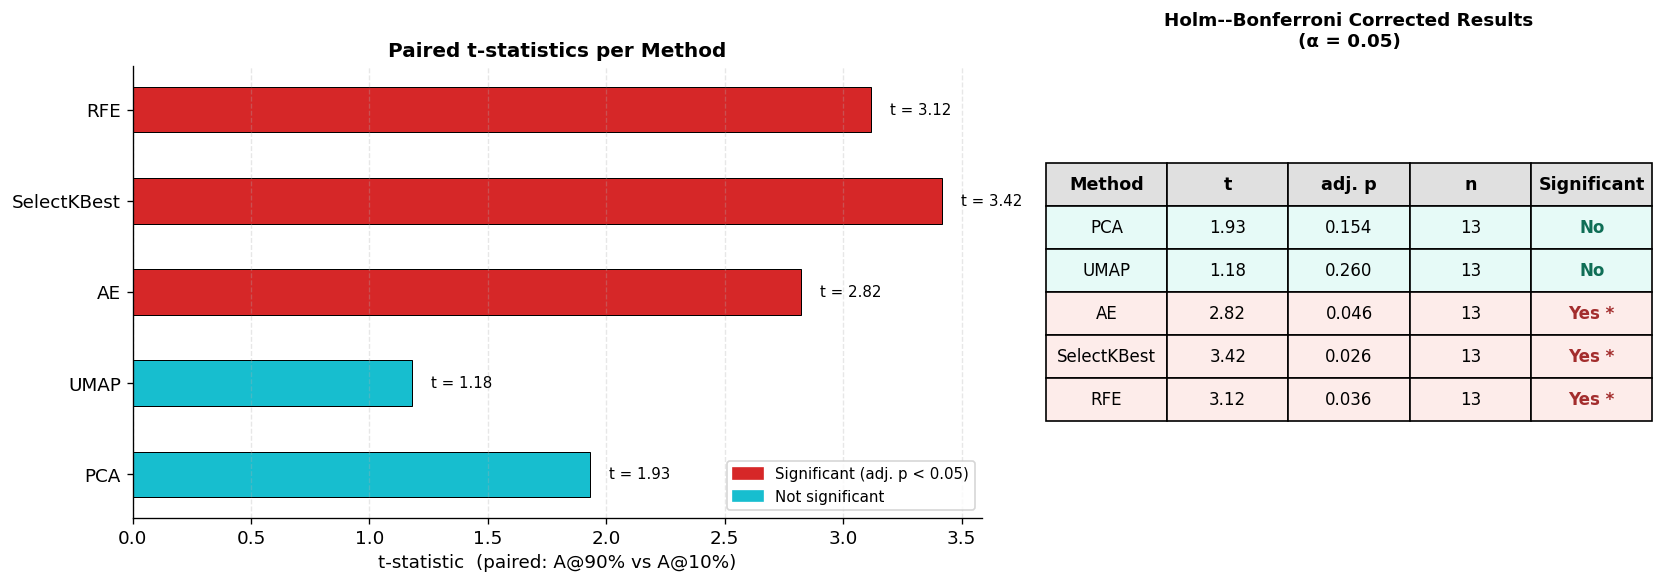


Saved: figure6_retention_ttests.png

Section 5.8 outputs complete.


In [24]:
# =============================================================================
# SECTION 5.8 - STATISTICAL EVALUATION OF RETENTION EFFECTS ACROSS METHODS
# Produces: Figure 6 (paired t-test bar chart + results table)
# Requires: raw, RANK_CONSTRAINED already defined.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.stats.multitest import multipletests

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
ok = raw[raw["status"] == "OK"].copy()

# Exclude rank-constrained datasets
ok = ok[~ok["dataset_id"].isin(RANK_CONSTRAINED)]

METHODS = ["PCA", "UMAP", "AE", "SelectKBest", "RFE"]

# -----------------------------------------------------------------------------
# HELPER: robust method matching (handles PCA_or_SVD)
# -----------------------------------------------------------------------------
def get_method_subset(df, method_name):
    if method_name == "PCA":
        return df[df["method"].isin(["PCA", "PCA_or_SVD", "TruncatedSVD"])]
    return df[df["method"] == method_name]

# =============================================================================
# SECTION 5.8 - PAIRED T-TESTS
# =============================================================================
print("=" * 70)
print("Section 5.8 - Statistical Evaluation of Retention Effects")
print("=" * 70)

# -----------------------------------------------------------------------------
# DEBUG: available method names
# -----------------------------------------------------------------------------
print("\nAvailable methods in filtered data:")
print(ok["method"].value_counts().to_string())

# -----------------------------------------------------------------------------
# COMPUTE PAIRED T-TESTS
# -----------------------------------------------------------------------------
raw_pvals   = []
tstats      = []
method_names = []
ns          = []
mean_diffs  = []

print("\n[Paired t-test computation]")
print("-" * 60)

for m in METHODS:
    pairs_10, pairs_90 = [], []

    for did in sorted(ok["dataset_id"].unique()):
        sub = get_method_subset(ok, m)
        sub = sub[sub["dataset_id"] == did]

        if sub.empty:
            continue

        a10 = sub[np.isclose(sub["retention_ratio_requested"], 0.10)]["accuracy"].mean()
        a90 = sub[np.isclose(sub["retention_ratio_requested"], 0.90)]["accuracy"].mean()

        if not np.isnan(a10) and not np.isnan(a90):
            pairs_10.append(a10)
            pairs_90.append(a90)

    n_pairs = len(pairs_10)
    print(f"\n{m}: valid dataset pairs = {n_pairs}")

    if n_pairs < 3:
        print(f"  WARNING: skipping {m} (fewer than 3 valid pairs)")
        continue

    t_stat, p_raw = stats.ttest_rel(pairs_90, pairs_10)
    mean_diff = np.mean(np.array(pairs_90) - np.array(pairs_10))

    print(f"  t = {t_stat:.4f},  raw p = {p_raw:.4f},  mean diff = {mean_diff:.4f}")

    tstats.append(t_stat)
    raw_pvals.append(p_raw)
    method_names.append(m)
    ns.append(n_pairs)
    mean_diffs.append(mean_diff)

# -----------------------------------------------------------------------------
# HOLM-BONFERRONI CORRECTION
# -----------------------------------------------------------------------------
reject, p_adj, _, _ = multipletests(raw_pvals, method="holm")

# -----------------------------------------------------------------------------
# FINAL RESULTS PRINT
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL RESULTS (for paper text)")
print("=" * 70)
print(f"\n{'Method':<15} {'t':>8} {'raw_p':>10} {'adj_p':>10} {'n':>5} {'sig':>8}  {'mean_diff':>10}")
print("-" * 70)
for m, t, p_raw, p_corr, rej, n, md in zip(
        method_names, tstats, raw_pvals, p_adj, reject, ns, mean_diffs):
    sig = "Yes *" if rej else "No"
    print(f"{m:<15} {t:>8.4f} {p_raw:>10.4f} {p_corr:>10.4f} {n:>5} {sig:>8}  {md:>10.4f}")

# =============================================================================
# FIGURE 6 - PAIRED T-TEST BAR CHART + RESULTS TABLE
# =============================================================================
print("\n[Generating Figure 6]")

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 5),
    gridspec_kw={"width_ratios": [1.4, 1]}
)

# -----------------------------------------------------------------------------
# LEFT PANEL: BAR CHART
# -----------------------------------------------------------------------------
bar_colors = ["#d62728" if r else "#17becf" for r in reject]

bars = ax1.barh(
    method_names,
    tstats,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6,
    height=0.5
)

ax1.axvline(0, color="black", lw=1)

# Value labels on bars
for bar, t in zip(bars, tstats):
    offset = 0.08 if t >= 0 else -0.08
    ha = "left" if t >= 0 else "right"
    ax1.text(
        t + offset,
        bar.get_y() + bar.get_height() / 2,
        f"t = {t:.2f}",
        va="center", ha=ha, fontsize=9
    )

ax1.set_xlabel("t-statistic  (paired: A@90% vs A@10%)", fontsize=11)
ax1.set_title("Paired t-statistics per Method", fontsize=12, fontweight="bold")
ax1.grid(True, axis="x", alpha=0.3, linestyle="--")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

sig_patch   = mpatches.Patch(color="#d62728", label="Significant (adj. p < 0.05)")
nosig_patch = mpatches.Patch(color="#17becf", label="Not significant")
ax1.legend(handles=[sig_patch, nosig_patch], fontsize=9, loc="lower right")

# -----------------------------------------------------------------------------
# RIGHT PANEL: RESULTS TABLE
# -----------------------------------------------------------------------------
ax2.axis("off")

col_labels_t = ["Method", "t", "adj. p", "n", "Significant"]
table_data   = []
row_colors   = []

for m, t, p, rej, n in zip(method_names, tstats, p_adj, reject, ns):
    sig_label = "Yes *" if rej else "No"
    table_data.append([m, f"{t:.2f}", f"{p:.3f}", str(n), sig_label])
    row_colors.append(["#FDECEA" if rej else "#E6FAF7"] * len(col_labels_t))

table = ax2.table(
    cellText=table_data,
    colLabels=col_labels_t,
    cellLoc="center",
    loc="center",
    cellColours=row_colors
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Header styling
for j in range(len(col_labels_t)):
    table[0, j].set_facecolor("#E0E0E0")
    table[0, j].set_text_props(fontweight="bold", fontsize=10.5)

# Significance column coloring
for i, rej in enumerate(reject):
    c = "#A32D2D" if rej else "#0F6E56"
    table[i + 1, 4].set_text_props(color=c, fontweight="bold")

ax2.set_title(
    "Holm--Bonferroni Corrected Results\n(\u03b1 = 0.05)",
    fontsize=11, fontweight="bold", pad=12
)

plt.tight_layout()
plt.savefig("figure6_retention_ttests.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: figure6_retention_ttests.png")
print("\nSection 5.8 outputs complete.")

Section 5.9 - Table 10 (Plateau Analysis)

ID    Name                Type      Acc@90  Plateau@      r*  RC
-----------------------------------------------------------------
D1    Pima Diabetes       Type I    0.7383       75%     90%  
D2    Heart Disease       Type I    0.5669       25%     25%  
D3    Adult Income        Type II   0.8502       25%     75%  
D4    Parkinson's         Type II   0.8605       50%     90%  
D5    Credit Default      Type III  0.8153       10%     50%  
D6    Coupon Rec.         Type I    0.6886       50%     90%  
D7    Breast Cancer       Type II   0.9654       25%     75%  
D8    QSAR Biodeg.        Type I    0.8528       75%     90%  
D9    Spambase            Type I    0.9187       50%     90%  
D10   MADELON             Type III  0.5979       10%     10%  
D11   ISOLET              Type III  0.9860       10%     75%  
D12   Colon Cancer        Type III  0.7856       10%     10%  †
D13   AG News             Type II   0.7514       50%     75%  
D14   

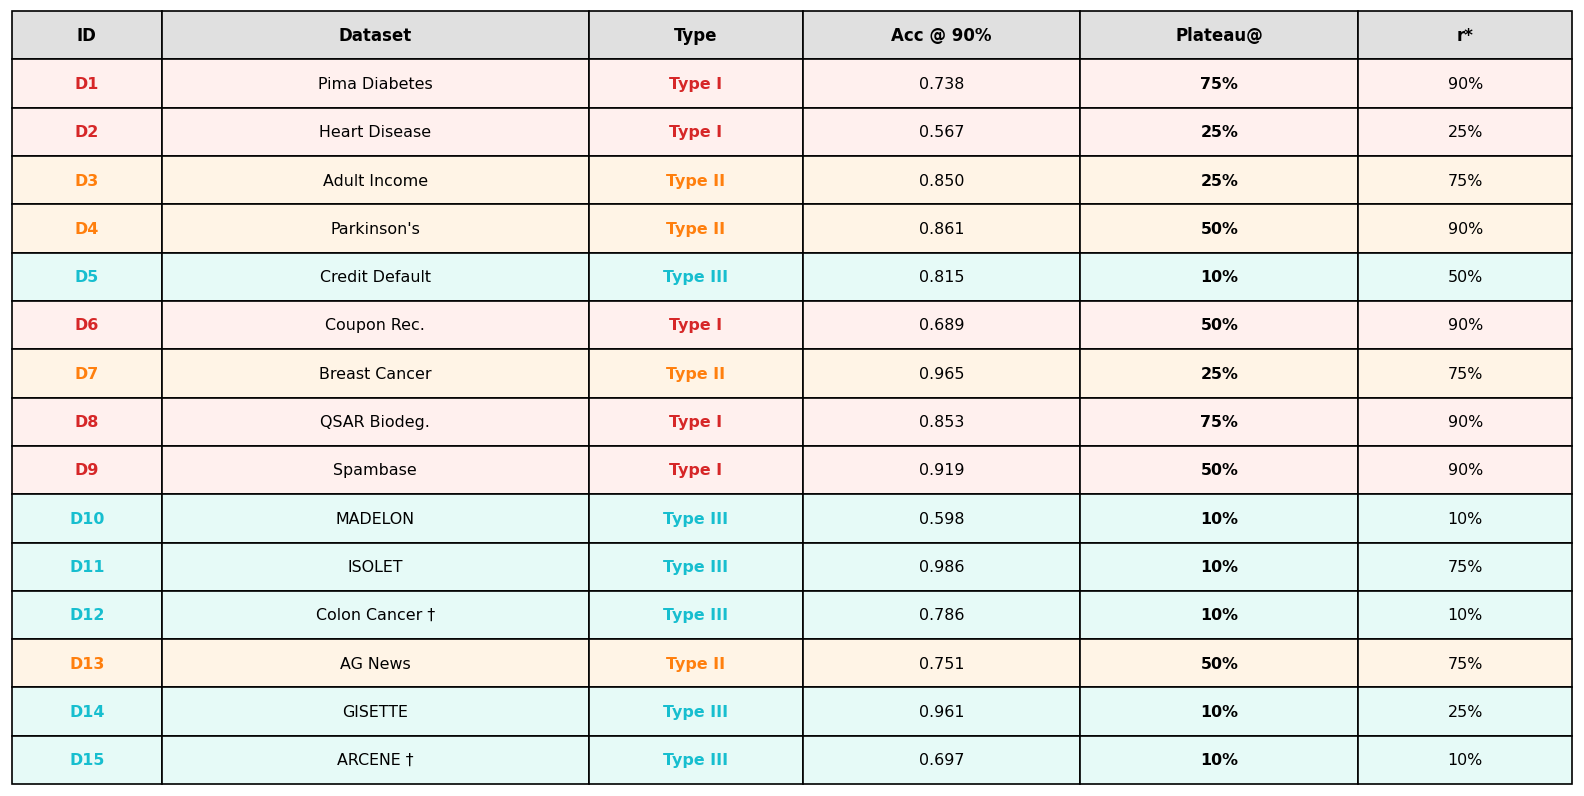


Saved: table10_plateau.png

Section 5.9 outputs complete.


In [25]:
# =============================================================================
# SECTION 5.9 - PERFORMANCE PLATEAUS AND RETENTION EFFICIENCY
# Produces: Table 9 (Plateau@ and r* per dataset)
# Requires: raw, RANK_CONSTRAINED, type_I, type_II, type_III already defined.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
ok = raw[raw["status"] == "OK"]
RETENTION_LEVELS = [0.10, 0.25, 0.50, 0.75, 0.90]

# -----------------------------------------------------------------------------
# TYPE MAP (built from regime lists for robustness)
# -----------------------------------------------------------------------------
type_map = {}
for d in type_I:   type_map[d] = "I"
for d in type_II:  type_map[d] = "II"
for d in type_III: type_map[d] = "III"

# -----------------------------------------------------------------------------
# DATASET FULL NAMES
# -----------------------------------------------------------------------------
DATASET_FULLNAMES = {
    "D1":  "Pima Diabetes",   "D2":  "Heart Disease",  "D3":  "Adult Income",
    "D4":  "Parkinson's",     "D5":  "Credit Default", "D6":  "Coupon Rec.",
    "D7":  "Breast Cancer",   "D8":  "QSAR Biodeg.",   "D9":  "Spambase",
    "D10": "MADELON",         "D11": "ISOLET",         "D12": "Colon Cancer",
    "D13": "AG News",         "D14": "GISETTE",        "D15": "ARCENE",
}

# -----------------------------------------------------------------------------
# COLOR SCHEME
# -----------------------------------------------------------------------------
type_row_colors = {"I": "#FFF0EE", "II": "#FFF4E6", "III": "#E6FAF7"}
type_txt_colors = {"I": "#d62728", "II": "#ff7f0e", "III": "#17becf"}

# =============================================================================
# TABLE 9 - PLATEAU ANALYSIS
# =============================================================================
print("=" * 70)
print("Section 5.9 - Table 10 (Plateau Analysis)")
print("=" * 70)

# -----------------------------------------------------------------------------
# HELPER: mean accuracy at one retention level for one dataset
# -----------------------------------------------------------------------------
def get_acc(did, r):
    vals = ok[(ok["dataset_id"] == did) &
              np.isclose(ok["retention_ratio_requested"], r)]["accuracy"].dropna()
    return vals.mean() if not vals.empty else np.nan

# -----------------------------------------------------------------------------
# COMPUTE PER-DATASET PLATEAU@ AND r*
# -----------------------------------------------------------------------------
rows = []
for did in [f"D{i}" for i in range(1, 16)]:
    dtype = type_map.get(did, "?")

    accs   = {r: get_acc(did, r) for r in RETENTION_LEVELS}
    acc90  = accs[0.90]
    r_star = max(accs, key=lambda r: accs[r] if not np.isnan(accs[r]) else -1)

    # Plateau@ = lowest r where acc >= acc90 - 0.01
    plateau = None
    for r in RETENTION_LEVELS:
        if not np.isnan(accs[r]) and accs[r] >= acc90 - 0.01:
            plateau = r
            break

    rows.append({
        "did":     did,
        "name":    DATASET_FULLNAMES[did],
        "type":    dtype,
        "acc90":   acc90,
        "plateau": plateau,
        "r_star":  r_star,
        "accs":    accs,
        "rc":      did in RANK_CONSTRAINED,
    })

# -----------------------------------------------------------------------------
# VERIFICATION PRINT
# -----------------------------------------------------------------------------
print(f"\n{'ID':<6}{'Name':<20}{'Type':<8}{'Acc@90':>8}{'Plateau@':>10}{'r*':>8}  RC")
print("-" * 65)
for r in rows:
    rc_tag = "†" if r["rc"] else ""
    print(f"{r['did']:<6}{r['name']:<20}{'Type '+r['type']:<8}"
          f"{r['acc90']:>8.4f}"
          f"{int(r['plateau']*100):>9}%"
          f"{int(r['r_star']*100):>7}%  {rc_tag}")

# -----------------------------------------------------------------------------
# SUMMARY STATS FOR PAPER TEXT
# -----------------------------------------------------------------------------
print("\n--- SUMMARY STATS FOR SECTION 5.9 TEXT ---")

non_rc = [r for r in rows if not r["rc"]]

plateau_counts = {}
for r in non_rc:
    p = int(r["plateau"] * 100)
    plateau_counts[p] = plateau_counts.get(p, []) + [r["did"]]

print("\nPlateau@ distribution (non-rank-constrained datasets):")
for p in sorted(plateau_counts.keys()):
    dids = plateau_counts[p]
    print(f"  {p}%: n={len(dids)}  {dids}")

plateau_at_or_below_50 = [r for r in non_rc if r["plateau"] <= 0.50]
plateau_require_75_plus = [r for r in non_rc if r["plateau"] > 0.50]

print(f"\nDatasets reaching plateau at or below 50%: "
      f"{len(plateau_at_or_below_50)} of {len(non_rc)}")
print(f"Datasets requiring above 50%: "
      f"{len(plateau_require_75_plus)}  "
      f"{[r['did'] for r in plateau_require_75_plus]}")

# Plateau@ <= r* check
print("\nPlateau@ vs r* relationship:")
for r in non_rc:
    rel = "=" if r["plateau"] == r["r_star"] else "<"
    print(f"  {r['did']}: Plateau@={int(r['plateau']*100)}%  "
          f"r*={int(r['r_star']*100)}%  "
          f"Plateau@ {rel} r*")

# Datasets where plateau == r* (optimal = aggressive)
coincide = [r for r in non_rc if r["plateau"] == r["r_star"]]
print(f"\nDatasets where Plateau@ == r* (compression sufficient AND optimal): "
      f"n={len(coincide)}  {[r['did'] for r in coincide]}")

# -----------------------------------------------------------------------------
# BUILD TABLE DATA
# -----------------------------------------------------------------------------
col_labels = ["ID", "Dataset", "Type", "Acc @ 90%", "Plateau@", "r*"]

table_data = []
for r in rows:
    rc_tag = " \u2020" if r["rc"] else ""
    table_data.append([
        r["did"],
        r["name"] + rc_tag,
        f"Type {r['type']}",
        f"{r['acc90']:.3f}",
        f"{int(r['plateau']*100)}%",
        f"{int(r['r_star']*100)}%",
    ])

cell_colors = [
    [type_row_colors.get(r["type"], "white")] * len(col_labels)
    for r in rows
]

# -----------------------------------------------------------------------------
# RENDER TABLE 10
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_position([0, 0.05, 1, 0.92])
ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=cell_colors,
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)

# Column widths
col_widths = [0.07, 0.20, 0.10, 0.13, 0.13, 0.10]
for j, w in enumerate(col_widths):
    for i in range(len(table_data) + 1):
        table[i, j].set_width(w)

# Header styling
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#E0E0E0")
    table[0, j].set_text_props(fontweight="bold", fontsize=10)

# ID and Type column coloring
for i, r in enumerate(rows):
    c = type_txt_colors.get(r["type"], "black")
    table[i + 1, 0].set_text_props(color=c, fontweight="bold")
    table[i + 1, 2].set_text_props(color=c, fontweight="bold")

# Plateau@ column bold
for i in range(len(rows)):
    table[i + 1, 4].set_text_props(fontweight="bold")

plt.savefig("table10_plateau.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: table10_plateau.png")
print("\nSection 5.9 outputs complete.")

Section 5.10 - Table 11 (Mean Fit Time per Method)

ID    Type                 PCA          UMAP            AE   SelectKBest           RFE
--------------------------------------------------------------------------------
D1    Type I              0.001         0.618         0.207         0.000         0.003
D2    Type I              0.001         0.316         0.109         0.000         0.003
D3    Type II             0.166        26.261         7.583         0.010         0.413
D4    Type II             0.001         0.288         0.075         0.000         0.002
D5    Type III            0.183        18.471         4.576         0.007         0.613
D6    Type I              0.123         6.717         1.869         0.002         0.114
D7    Type II             0.001         0.564         0.127         0.000         0.003
D8    Type I              0.006         1.396         0.181         0.000         0.010
D9    Type I              0.241         8.697         0.683         0.001   

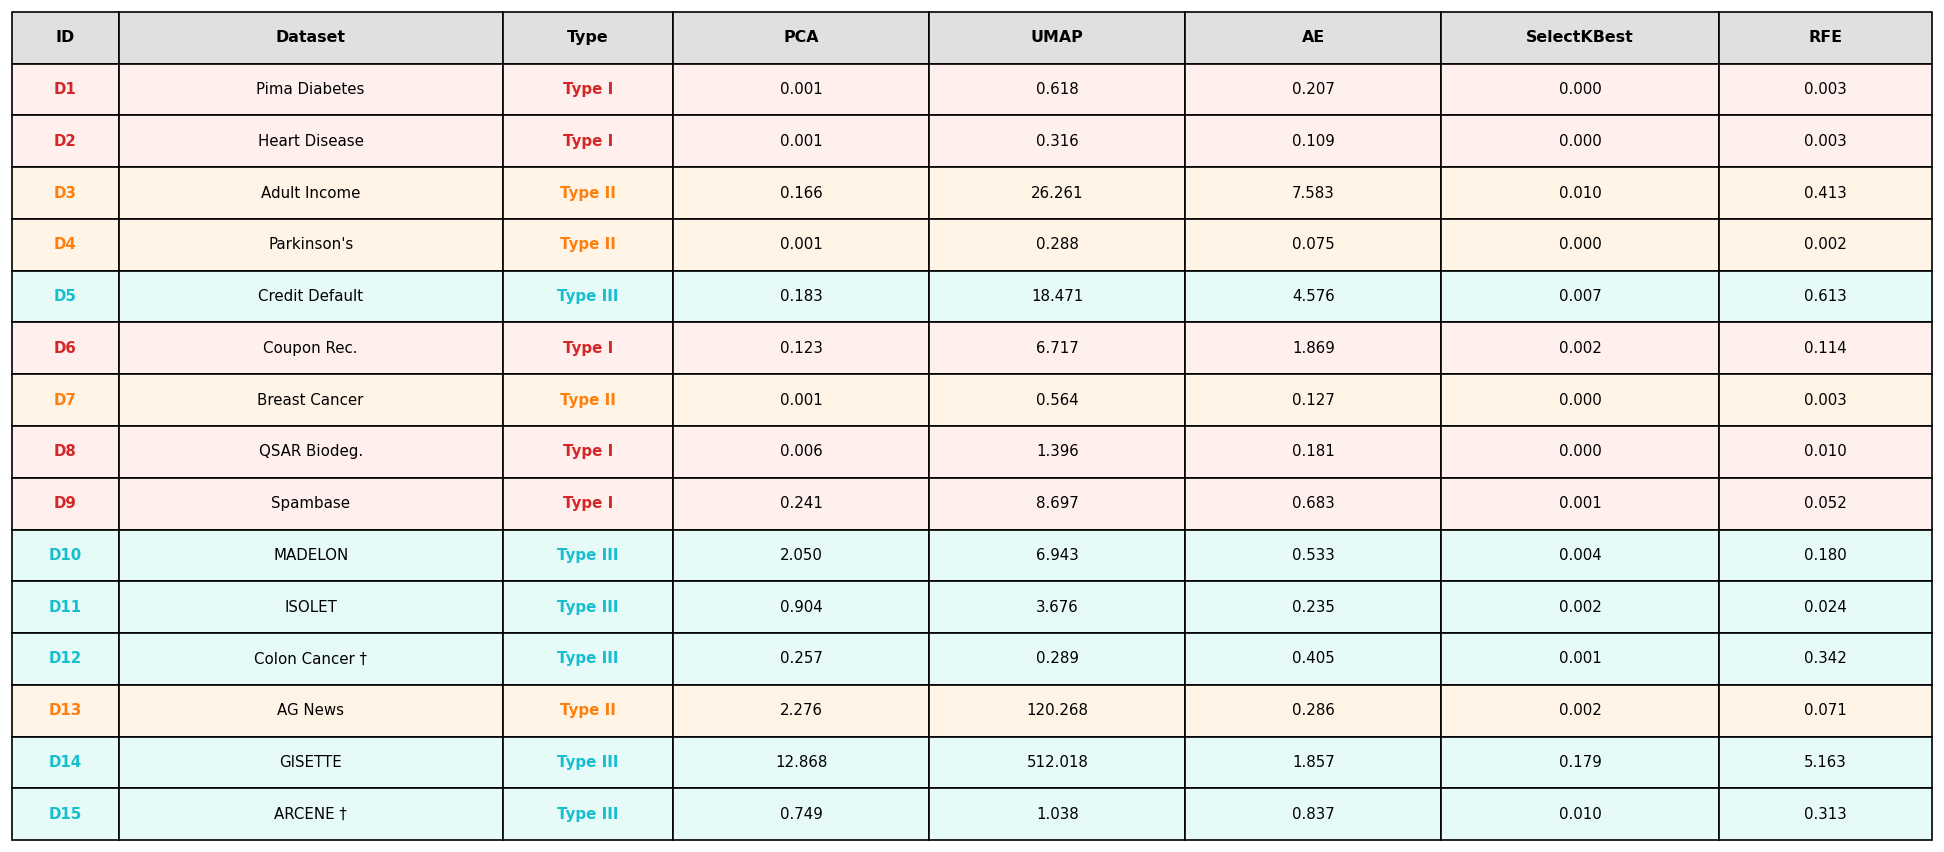


Saved: table11_fit_time.png

Section 5.10 outputs complete.


In [26]:
# =============================================================================
# SECTION 5.10 - METHOD COMPARISON: ACCURACY-COST TRADE-OFFS
# Produces: Table 10 (mean fit time per method per dataset)
#           + verification output for paper text
# Paste this as a new cell AFTER your Section 5.9 cell.
# Requires: raw, RANK_CONSTRAINED, type_I, type_II, type_III already defined.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
ok = raw[raw["status"] == "OK"]
METHODS_DISPLAY = ["PCA", "UMAP", "AE", "SelectKBest", "RFE"]

# -----------------------------------------------------------------------------
# TYPE MAP (built from regime lists for robustness)
# -----------------------------------------------------------------------------
type_map = {}
for d in type_I:   type_map[d] = "I"
for d in type_II:  type_map[d] = "II"
for d in type_III: type_map[d] = "III"

# -----------------------------------------------------------------------------
# DATASET FULL NAMES (consistent with prior sections)
# -----------------------------------------------------------------------------
DATASET_FULLNAMES = {
    "D1":  "Pima Diabetes",   "D2":  "Heart Disease",  "D3":  "Adult Income",
    "D4":  "Parkinson's",     "D5":  "Credit Default", "D6":  "Coupon Rec.",
    "D7":  "Breast Cancer",   "D8":  "QSAR Biodeg.",   "D9":  "Spambase",
    "D10": "MADELON",         "D11": "ISOLET",         "D12": "Colon Cancer",
    "D13": "AG News",         "D14": "GISETTE",        "D15": "ARCENE",
}

# -----------------------------------------------------------------------------
# COLOR SCHEME (consistent across paper)
# -----------------------------------------------------------------------------
type_row_colors = {"I": "#FFF0EE", "II": "#FFF4E6", "III": "#E6FAF7"}
type_txt_colors = {"I": "#d62728", "II": "#ff7f0e", "III": "#17becf"}

# -----------------------------------------------------------------------------
# HELPER: robust method matching (handles PCA_or_SVD and TruncatedSVD)
# -----------------------------------------------------------------------------
def get_method_rows(df, method_display):
    if method_display == "PCA":
        return df[df["method"].isin(["PCA", "PCA_or_SVD", "TruncatedSVD"])]
    return df[df["method"] == method_display]

# =============================================================================
# TABLE 10 - MEAN FIT TIME PER METHOD PER DATASET
# =============================================================================
print("=" * 70)
print("Section 5.10 - Table 11 (Mean Fit Time per Method)")
print("=" * 70)

# -----------------------------------------------------------------------------
# BUILD TABLE DATA
# -----------------------------------------------------------------------------
all_dids = [f"D{i}" for i in range(1, 16)]
rows_data = []

for did in all_dids:
    sub = ok[ok["dataset_id"] == did]
    dtype = type_map.get(did, "?")
    name  = DATASET_FULLNAMES[did]
    rc_tag = " \u2020" if did in RANK_CONSTRAINED else ""

    row = {"ID": did, "Dataset": name + rc_tag, "Type": f"Type {dtype}"}

    for m in METHODS_DISPLAY:
        vals = get_method_rows(sub, m)["fit_time_sec"].dropna()
        row[m] = round(vals.mean(), 3) if not vals.empty else np.nan

    rows_data.append(row)

df = pd.DataFrame(rows_data)

# -----------------------------------------------------------------------------
# VERIFICATION PRINT
# -----------------------------------------------------------------------------
print(f"\n{'ID':<6}{'Type':<10}" + "".join(f"{m:>14}" for m in METHODS_DISPLAY))
print("-" * 80)
for _, row in df.iterrows():
    vals = "".join(
        f"{row[m]:>14.3f}" if not pd.isna(row[m]) else f"{'—':>14}"
        for m in METHODS_DISPLAY
    )
    print(f"{row['ID']:<6}Type {type_map.get(row['ID'], '?'):<6}{vals}")

# =============================================================================
# GLOBAL MEAN FIT TIME (for paper text)
# =============================================================================
print("\n--- GLOBAL MEAN FIT TIME (seconds) ---")
for m in METHODS_DISPLAY:
    print(f"  {m:<15}: {df[m].mean():.4f}")

# =============================================================================
# MEAN ACCURACY COMPARISON (all vs non-rank-constrained)
# =============================================================================
print("\n--- MEAN ACCURACY: ALL DATASETS ---")
for m in METHODS_DISPLAY:
    vals = get_method_rows(ok, m)["accuracy"].dropna()
    print(f"  {m:<15}: {vals.mean():.4f}")

print("\n--- MEAN ACCURACY: EXCLUDING RANK-CONSTRAINED ---")
ok_non_rc = ok[~ok["dataset_id"].isin(RANK_CONSTRAINED)]
for m in METHODS_DISPLAY:
    vals = get_method_rows(ok_non_rc, m)["accuracy"].dropna()
    print(f"  {m:<15}: {vals.mean():.4f}")

# =============================================================================
# RENDER TABLE 10
# =============================================================================
col_labels = ["ID", "Dataset", "Type"] + METHODS_DISPLAY

table_display = df[col_labels].copy()

# Format numbers for display
for m in METHODS_DISPLAY:
    table_display[m] = table_display[m].apply(
        lambda x: f"{x:.3f}" if not pd.isna(x) else "\u2014"
    )

cell_colors = []
for did in all_dids:
    dtype = type_map.get(did, "?")
    base  = type_row_colors.get(dtype, "white")
    cell_colors.append([base] * len(col_labels))

fig, ax = plt.subplots(figsize=(16, 7.5))
ax.set_position([0, 0.05, 1, 0.92])
ax.axis("off")

table = ax.table(
    cellText=table_display.values,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=cell_colors,
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

# Column widths
col_widths = [0.05, 0.18, 0.08, 0.12, 0.12, 0.12, 0.13, 0.10]
for j, w in enumerate(col_widths):
    for i in range(len(all_dids) + 1):
        table[i, j].set_width(w)

# Header styling
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#E0E0E0")
    table[0, j].set_text_props(fontweight="bold", fontsize=9.5)

# ID and Type column coloring
for i, did in enumerate(all_dids):
    dtype = type_map.get(did, "?")
    c = type_txt_colors.get(dtype, "black")
    table[i + 1, 0].set_text_props(color=c, fontweight="bold")
    table[i + 1, 2].set_text_props(color=c, fontweight="bold")

plt.savefig("table11_fit_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: table11_fit_time.png")
print("\nSection 5.10 outputs complete.")

Section 5.11 - Figure 7 (Classifier Consistency)

Method                   LR          GB     SVM_RBF
---------------------------------------------------
PCA                  0.8210      0.8068      0.8255
UMAP                 0.7803      0.7646      0.7540
AE                   0.7617      0.7785      0.7774
SelectKBest          0.8074      0.8149      0.8211
RFE                  0.8064      0.8076      0.8130

[Best method per classifier]
  LR: PCA (0.8210)
  GB: SelectKBest (0.8149)
  SVM_RBF: PCA (0.8255)

Spearman Rank Correlations (on raw accuracy vectors)
  LR vs GB: rho = 0.6000,  p = 0.2848
  LR vs SVM_RBF: rho = 0.9000,  p = 0.0374
  GB vs SVM_RBF: rho = 0.7000,  p = 0.1881

[Generating Figure 7]


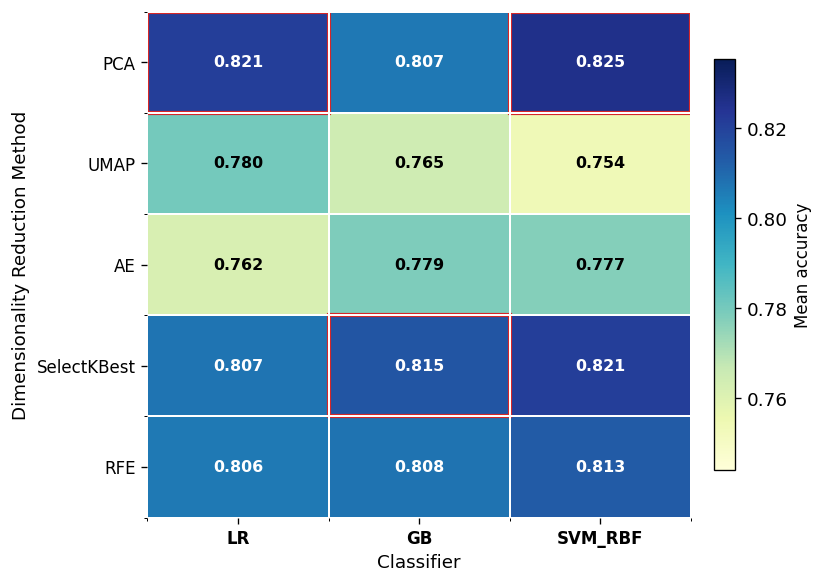


Saved: figure7_classifier_consistency.png

Section 5.11 outputs complete.


In [27]:
# =============================================================================
# SECTION 5.11 - CLASSIFIER CONSISTENCY
# Produces: Figure 7 (accuracy heatmap across methods and classifiers)
# Paste this as a new cell AFTER your Section 5.10 cell.
# Requires: raw, RANK_CONSTRAINED already defined.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
ok = raw[raw["status"] == "OK"]
METHODS     = ["PCA", "UMAP", "AE", "SelectKBest", "RFE"]
CLASSIFIERS = ["LR", "GB", "SVM_RBF"]

# -----------------------------------------------------------------------------
# HELPER: robust method matching (handles PCA_or_SVD and TruncatedSVD)
# -----------------------------------------------------------------------------
def get_method_rows(df, method_display):
    if method_display == "PCA":
        return df[df["method"].isin(["PCA", "PCA_or_SVD", "TruncatedSVD"])]
    return df[df["method"] == method_display]

# =============================================================================
# SECTION 5.11 - COMPUTE ACCURACY MATRIX
# =============================================================================
print("=" * 70)
print("Section 5.11 - Figure 7 (Classifier Consistency)")
print("=" * 70)

# -----------------------------------------------------------------------------
# BUILD METHOD x CLASSIFIER MATRIX
# -----------------------------------------------------------------------------
matrix = []
for m in METHODS:
    row = []
    for clf in CLASSIFIERS:
        vals = get_method_rows(ok, m)
        vals = vals[vals["classifier"] == clf]["accuracy"].dropna()
        row.append(vals.mean() if not vals.empty else np.nan)
    matrix.append(row)

values = np.array(matrix)

# -----------------------------------------------------------------------------
# VERIFICATION PRINT
# -----------------------------------------------------------------------------
print(f"\n{'Method':<15}" + "".join(f"{c:>12}" for c in CLASSIFIERS))
print("-" * 51)
for i, m in enumerate(METHODS):
    row_str = "".join(f"{values[i,j]:>12.4f}" for j in range(len(CLASSIFIERS)))
    print(f"{m:<15}{row_str}")

# Best per classifier
print("\n[Best method per classifier]")
for j, clf in enumerate(CLASSIFIERS):
    best_i = int(np.argmax(values[:, j]))
    print(f"  {clf}: {METHODS[best_i]} ({values[best_i, j]:.4f})")

# =============================================================================
# RANKING CONSISTENCY - SPEARMAN ON RAW VALUES (correct approach)
# =============================================================================
print("\n" + "=" * 70)
print("Spearman Rank Correlations (on raw accuracy vectors)")
print("=" * 70)

spearman_results = {}
for i in range(len(CLASSIFIERS)):
    for j in range(i + 1, len(CLASSIFIERS)):
        c1, c2 = CLASSIFIERS[i], CLASSIFIERS[j]
        # Correct: pass raw accuracy vectors, not rank indices
        r, p = spearmanr(values[:, i], values[:, j])
        spearman_results[(c1, c2)] = (r, p)
        print(f"  {c1} vs {c2}: rho = {r:.4f},  p = {p:.4f}")

# =============================================================================
# FIGURE 7 - HEATMAP
# =============================================================================
print("\n[Generating Figure 7]")

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    values,
    cmap=plt.cm.YlGnBu,
    aspect="auto",
    vmin=values.min() - 0.01,
    vmax=values.max() + 0.01
)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Mean accuracy", fontsize=10)

# Axis labels
ax.set_xticks(range(len(CLASSIFIERS)))
ax.set_xticklabels(CLASSIFIERS, fontsize=10, fontweight="bold")
ax.set_yticks(range(len(METHODS)))
ax.set_yticklabels(METHODS, fontsize=10)
ax.set_xlabel("Classifier", fontsize=11)
ax.set_ylabel("Dimensionality Reduction Method", fontsize=11)

# Cell annotations
for i in range(len(METHODS)):
    for j in range(len(CLASSIFIERS)):
        val = values[i, j]
        norm = (val - values.min()) / (values.max() - values.min() + 1e-9)
        color = "white" if norm > 0.6 else "black"
        ax.text(j, i, f"{val:.3f}",
                ha="center", va="center",
                fontsize=9.5, color=color, fontweight="bold")

# Highlight best per classifier
for j in range(len(CLASSIFIERS)):
    best_i = int(np.argmax(values[:, j]))
    ax.add_patch(plt.Rectangle(
        (j - 0.5, best_i - 0.5), 1, 1,
        fill=False, edgecolor="#d62728", linewidth=2.5
    ))

# Grid styling
ax.set_xticks(np.arange(-0.5, len(CLASSIFIERS)), minor=True)
ax.set_yticks(np.arange(-0.5, len(METHODS)), minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.spines[:].set_visible(False)

plt.tight_layout()
plt.savefig("figure7_classifier_consistency.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: figure7_classifier_consistency.png")
print("\nSection 5.11 outputs complete.")

Section 5.12 - Meta-Feature Analysis

[Spearman Correlations with RS]
Feature                                  rho         p
-------------------------------------------------------
n/d  (sample-to-feature ratio)       +0.4615    0.1124 
log n  (log sample size)             -0.1429    0.6415 
log d  (log dimensionality)          -0.3956    0.1809 
V₁₀  (PCA variance at 10%)           -0.3242    0.2799 
V₂₅ − V₁₀  (early variance gain)     +0.3297    0.2713 

[LOOCV Linear Regression]
  R²  = -2.6934
  MAE = 0.0384
  Interpretation: worse than mean predictor

[Generating Table 12]
  -> wrote ./table12_metafeatures.tex  (5 rows)


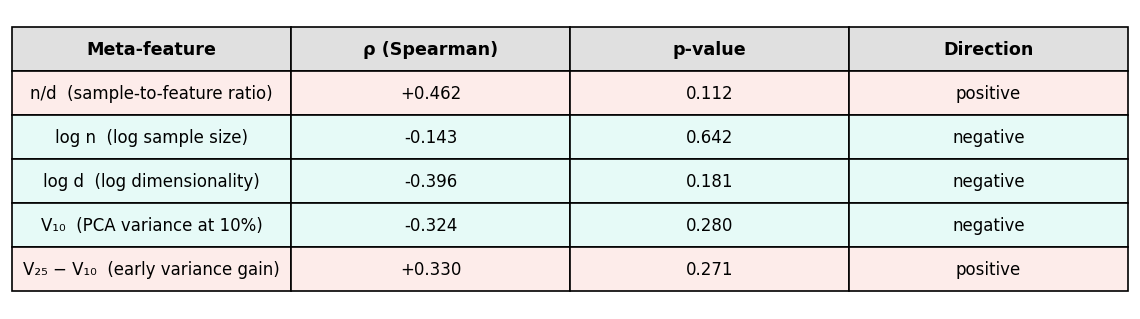

Saved: table12_metafeatures.png

[Generating Figure 8 - Multi-panel scatter]


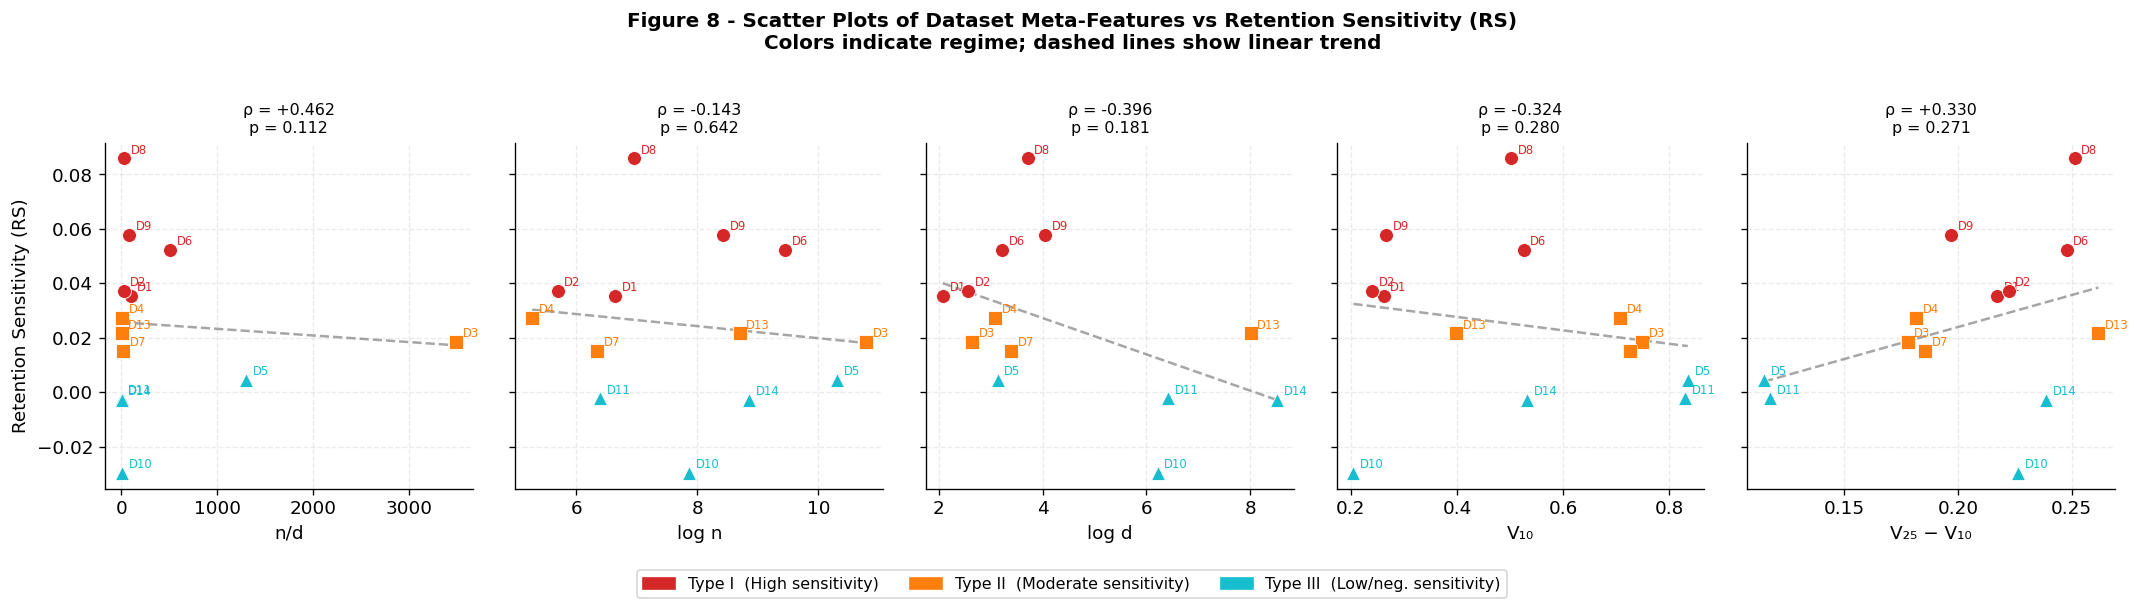

Saved: figure8_metafeature_scatter.png

[Generating Figure 9 - Parallel coordinates]


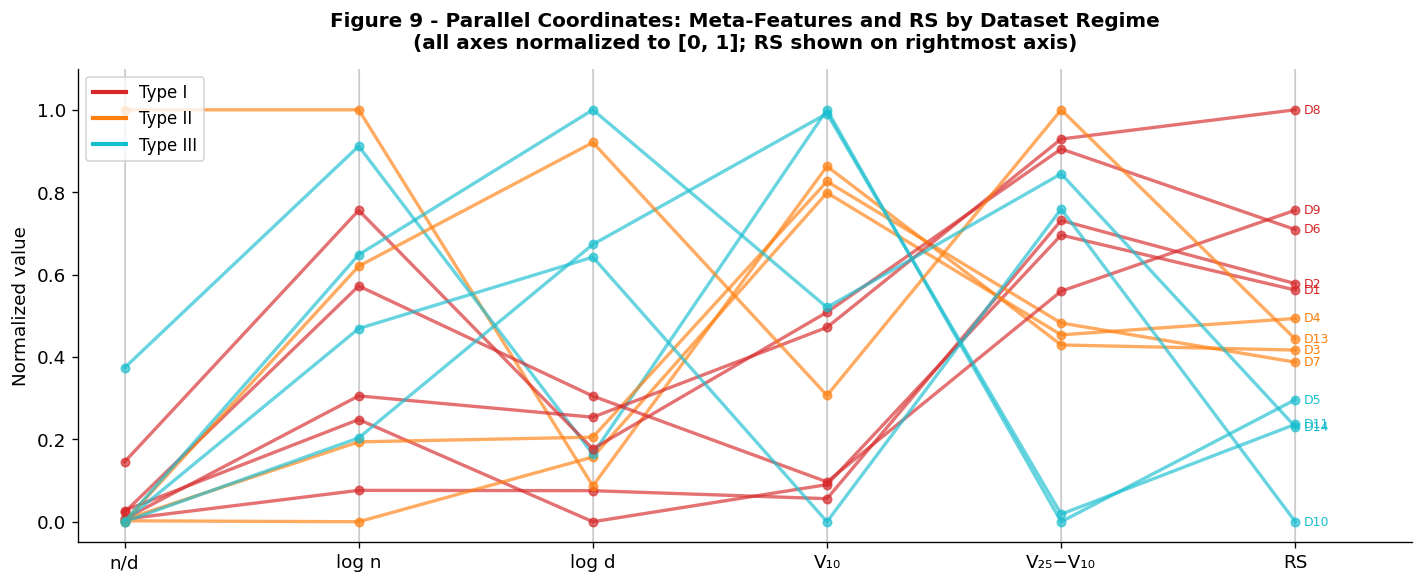

Saved: figure9_parallel_coordinates.png

--- FINAL SUMMARY FOR PAPER TEXT ---
n datasets analyzed: 13
LOOCV R² = -2.6934,  MAE = 0.0384

Spearman correlations:
  n/d  (sample-to-feature ratio): rho=+0.4615, p=0.1124
  log n  (log sample size): rho=-0.1429, p=0.6415
  log d  (log dimensionality): rho=-0.3956, p=0.1809
  V₁₀  (PCA variance at 10%): rho=-0.3242, p=0.2799
  V₂₅ − V₁₀  (early variance gain): rho=+0.3297, p=0.2713


In [28]:
# =============================================================================
# SECTION 5.12 - PREDICTING RETENTION SENSITIVITY FROM DATASET META-FEATURES
# Produces:
#   Table 12  — Spearman correlations (meta-features vs RS)
#   Figure 8  — Multi-panel scatter plots (all meta-features vs RS)
#   Figure 9  — Regime-colored parallel coordinates plot
# Paste this as a new cell AFTER your Section 5.11 cell.
# Requires: raw, RANK_CONSTRAINED, DATASETS, type_I, type_II, type_III defined.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
ok = raw[raw["status"] == "OK"]
VAR_COL = "var_explained"

# Exclude rank-constrained datasets
valid_datasets = [f"D{i}" for i in range(1, 16) if f"D{i}" not in RANK_CONSTRAINED]

# -----------------------------------------------------------------------------
# TYPE MAP (built from regime lists for robustness)
# -----------------------------------------------------------------------------
type_map = {}
for d in type_I:   type_map[d] = "I"
for d in type_II:  type_map[d] = "II"
for d in type_III: type_map[d] = "III"

type_txt_colors = {"I": "#d62728", "II": "#ff7f0e", "III": "#17becf"}
type_markers    = {"I": "o",       "II": "s",       "III": "^"}

DATASET_FULLNAMES = {
    "D1":  "Pima Diabetes",   "D2":  "Heart Disease",  "D3":  "Adult Income",
    "D4":  "Parkinson's",     "D5":  "Credit Default", "D6":  "Coupon Rec.",
    "D7":  "Breast Cancer",   "D8":  "QSAR Biodeg.",   "D9":  "Spambase",
    "D10": "MADELON",         "D11": "ISOLET",         "D12": "Colon Cancer",
    "D13": "AG News",         "D14": "GISETTE",        "D15": "ARCENE",
}

# =============================================================================
# BUILD META-FEATURE DATASET
# =============================================================================
print("=" * 70)
print("Section 5.12 - Meta-Feature Analysis")
print("=" * 70)

rows = []
for did in valid_datasets:
    sub  = ok[ok["dataset_id"] == did]

    # n = number of unique seed x split combinations (proxy for sample size)
    # Read n and d from k_requested and retention_ratio columns
    # k_requested = floor(r * d), so d = round(k_requested / r)
    # Use r=0.10 to get best estimate of d
    sub_10 = sub[np.isclose(sub["retention_ratio_requested"], 0.10)]
    if not sub_10.empty and "k_requested" in sub_10.columns:
        k_req_10 = sub_10["k_requested"].median()
        d = round(k_req_10 / 0.10)
    elif not sub_10.empty and "k_used" in sub_10.columns:
        k_req_10 = sub_10["k_used"].median()
        d = round(k_req_10 / 0.10)
    else:
        d = np.nan

    # n from k_used ceiling (k_used = min(k_req, n_tr-1))
    # At r=0.90, if k_used < k_req then n_tr-1 = k_used, so n_tr = k_used+1
    sub_90 = sub[np.isclose(sub["retention_ratio_requested"], 0.90)]
    if not sub_90.empty and "k_used" in sub_90.columns and "k_requested" in sub_90.columns:
        k_used_90 = sub_90["k_used"].median()
        k_req_90  = sub_90["k_requested"].median()
        if k_used_90 < k_req_90:
            # rank-constrained at 90%: n_tr = k_used_90 + 1
            n = (k_used_90 + 1) / 0.80  # reverse 80/20 split
        else:
            n = np.nan
    else:
        n = np.nan

    # Fallback: read n and d from DATASETS if available
    info = DATASETS.get(did, ())
    for idx_n, idx_d in [(2,3), (1,2), (3,4)]:
        try:
            n_candidate = float(info[idx_n])
            d_candidate = float(info[idx_d])
            if n_candidate > 1 and d_candidate > 1:
                n = n_candidate
                d = d_candidate
                break
        except (IndexError, TypeError, ValueError):
            continue

    # Final fallback: use known values from Table 1
    nd_lookup = {
        "D1": (768, 8),    "D2": (297, 13),   "D3": (48842, 14),
        "D4": (195, 22),   "D5": (30000, 23),  "D6": (12684, 25),
        "D7": (569, 30),   "D8": (1054, 41),   "D9": (4601, 57),
        "D10": (2600, 500),"D11": (600, 617),  "D12": (62, 2000),
        "D13": (6000, 3000),"D14": (7000, 5000),"D15": (200, 10000),
    }
    if np.isnan(n) or np.isnan(d) or d < 1:
        n, d = nd_lookup.get(did, (np.nan, np.nan))
    n = float(n)
    d = float(d)

    # RS
    a90 = sub[np.isclose(sub["retention_ratio_requested"], 0.90)]["accuracy"].mean()
    a10 = sub[np.isclose(sub["retention_ratio_requested"], 0.10)]["accuracy"].mean()
    rs  = a90 - a10

    # PCA variance features
    pca_sub = sub[sub["method"].isin(["PCA", "PCA_or_SVD", "TruncatedSVD"])]
    v10 = pca_sub[np.isclose(pca_sub["retention_ratio_requested"], 0.10)][VAR_COL].mean()
    v25 = pca_sub[np.isclose(pca_sub["retention_ratio_requested"], 0.25)][VAR_COL].mean()
    v50 = pca_sub[np.isclose(pca_sub["retention_ratio_requested"], 0.50)][VAR_COL].mean()

    rows.append({
        "dataset":    did,
        "name":       DATASET_FULLNAMES[did],
        "type":       type_map.get(did, "?"),
        "RS":         rs,
        "n_d":        n / d,
        "log_n":      np.log(n),
        "log_d":      np.log(d),
        "V10":        v10,
        "early_var":  v25 - v10,
        "mid_var":    v50 - v25,
        "n":          n,
        "d":          d,
    })

df = pd.DataFrame(rows)

# =============================================================================
# SPEARMAN CORRELATIONS
# =============================================================================
features      = ["n_d", "log_n", "log_d", "V10", "early_var"]
feature_names = {
    "n_d":       "n/d  (sample-to-feature ratio)",
    "log_n":     "log n  (log sample size)",
    "log_d":     "log d  (log dimensionality)",
    "V10":       "V\u2081\u2080  (PCA variance at 10%)",
    "early_var": "V\u2082\u2085 \u2212 V\u2081\u2080  (early variance gain)",
}

print("\n[Spearman Correlations with RS]")
print(f"{'Feature':<35} {'rho':>8}  {'p':>8}")
print("-" * 55)

spearman_rows = []
for f in features:
    rho, p = spearmanr(df[f], df["RS"])
    sig = "*" if p < 0.05 else ""
    print(f"{feature_names[f]:<35} {rho:>+8.4f}  {p:>8.4f} {sig}")
    spearman_rows.append((feature_names[f], rho, p))

# =============================================================================
# LOOCV REGRESSION
# =============================================================================
X_meta = df[features].values
y_rs   = df["RS"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_meta)

loo    = LeaveOneOut()
y_true_list, y_pred_list = [], []

for train_idx, test_idx in loo.split(X_scaled):
    model = LinearRegression()
    model.fit(X_scaled[train_idx], y_rs[train_idx])
    y_pred_list.append(model.predict(X_scaled[test_idx])[0])
    y_true_list.append(y_rs[test_idx][0])

r2  = r2_score(y_true_list, y_pred_list)
mae = mean_absolute_error(y_true_list, y_pred_list)

print(f"\n[LOOCV Linear Regression]")
print(f"  R\u00b2  = {r2:.4f}")
print(f"  MAE = {mae:.4f}")
print(f"  Interpretation: {'worse than mean predictor' if r2 < 0 else 'better than mean predictor'}")

# =============================================================================
# TABLE 11 - SPEARMAN CORRELATIONS
# =============================================================================
print("\n[Generating Table 12]")

col_labels_t11 = ["Meta-feature", "\u03c1 (Spearman)", "p-value", "Direction"]
table_data_t11 = []
row_colors_t11 = []

for name, rho, p in spearman_rows:
    direction = "positive" if rho > 0 else "negative"
    sig_str   = f"{p:.3f} *" if p < 0.05 else f"{p:.3f}"
    table_data_t11.append([name, f"{rho:+.3f}", sig_str, direction])
    row_colors_t11.append(["#FDECEA" if rho > 0 else "#E6FAF7"] * 4)

fig_t, ax_t = plt.subplots(figsize=(12, 3.2))
ax_t.axis("off")

table = ax_t.table(
    cellText=table_data_t11,
    colLabels=col_labels_t11,
    cellLoc="center",
    loc="center",
    cellColours=row_colors_t11
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

for j in range(len(col_labels_t11)):
    table[0, j].set_facecolor("#E0E0E0")
    table[0, j].set_text_props(fontweight="bold", fontsize=10.5)

plt.savefig("table12_metafeatures.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: table12_metafeatures.png")

# =============================================================================
# FIGURE 8 - MULTI-PANEL SCATTER (ALL META-FEATURES VS RS)
# =============================================================================
print("\n[Generating Figure 8 - Multi-panel scatter]")

feature_plot_labels = {
    "n_d":       "n/d",
    "log_n":     "log n",
    "log_d":     "log d",
    "V10":       "V\u2081\u2080",
    "early_var": "V\u2082\u2085 \u2212 V\u2081\u2080",
}

fig8, axes = plt.subplots(1, 5, figsize=(18, 4.5), sharey=True)

for ax, f in zip(axes, features):
    rho, p = spearmanr(df[f], df["RS"])

    for _, row in df.iterrows():
        dtype = row["type"]
        ax.scatter(
            row[f], row["RS"],
            color=type_txt_colors.get(dtype, "gray"),
            marker=type_markers.get(dtype, "o"),
            s=70, zorder=3, edgecolors="white", linewidth=0.5
        )
        ax.annotate(
            row["dataset"],
            (row[f], row["RS"]),
            textcoords="offset points",
            xytext=(4, 3),
            fontsize=7,
            color=type_txt_colors.get(dtype, "gray")
        )

    # Trend line
    x_vals = df[f].values
    coef   = np.polyfit(x_vals, df["RS"].values, 1)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    ax.plot(x_line, np.polyval(coef, x_line),
            color="gray", lw=1.5, ls="--", alpha=0.7)

    ax.set_xlabel(feature_plot_labels[f], fontsize=11)
    ax.set_title(f"\u03c1 = {rho:+.3f}\np = {p:.3f}",
                 fontsize=9.5, color="black")
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Retention Sensitivity (RS)", fontsize=11)

# Legend
patches = [
    mpatches.Patch(color=type_txt_colors["I"],   label="Type I  (High sensitivity)"),
    mpatches.Patch(color=type_txt_colors["II"],  label="Type II  (Moderate sensitivity)"),
    mpatches.Patch(color=type_txt_colors["III"], label="Type III  (Low/neg. sensitivity)"),
]
fig8.legend(handles=patches, loc="lower center", ncol=3,
            fontsize=9.5, bbox_to_anchor=(0.5, -0.08), frameon=True)

fig8.suptitle(
    "Figure 8 - Scatter Plots of Dataset Meta-Features vs Retention Sensitivity (RS)\n"
    "Colors indicate regime; dashed lines show linear trend",
    fontsize=12, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("figure8_metafeature_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure8_metafeature_scatter.png")

# =============================================================================
# FIGURE 9 - REGIME-COLORED PARALLEL COORDINATES
# =============================================================================
print("\n[Generating Figure 9 - Parallel coordinates]")

from matplotlib.lines import Line2D

# Normalize all features + RS to [0,1] for parallel coords
plot_features = ["n_d", "log_n", "log_d", "V10", "early_var", "RS"]
plot_labels   = ["n/d", "log n", "log d", "V\u2081\u2080",
                 "V\u2082\u2085\u2212V\u2081\u2080", "RS"]

df_norm = df[plot_features].copy()
for col in plot_features:
    col_min = df_norm[col].min()
    col_max = df_norm[col].max()
    if col_max > col_min:
        df_norm[col] = (df_norm[col] - col_min) / (col_max - col_min)
    else:
        df_norm[col] = 0.5

fig9, ax9 = plt.subplots(figsize=(12, 5))

for _, row_data in df.iterrows():
    did   = row_data["dataset"]
    dtype = row_data["type"]
    norm_vals = df_norm.loc[_ if isinstance(_, int) else
                            df[df["dataset"] == did].index[0], plot_features].values

    ax9.plot(
        range(len(plot_features)),
        norm_vals,
        color=type_txt_colors.get(dtype, "gray"),
        alpha=0.65,
        lw=2,
        marker="o",
        markersize=5
    )
    # Label RS endpoint
    ax9.annotate(
        did,
        (len(plot_features) - 1, norm_vals[-1]),
        textcoords="offset points",
        xytext=(5, 0),
        fontsize=7.5,
        color=type_txt_colors.get(dtype, "gray"),
        va="center"
    )

ax9.set_xticks(range(len(plot_features)))
ax9.set_xticklabels(plot_labels, fontsize=11)
ax9.set_ylabel("Normalized value", fontsize=11)
ax9.set_xlim(-0.2, len(plot_features) - 0.5)
ax9.set_ylim(-0.05, 1.10)
ax9.grid(True, axis="x", alpha=0.3)
ax9.spines["top"].set_visible(False)
ax9.spines["right"].set_visible(False)

# Vertical axis lines
for x in range(len(plot_features)):
    ax9.axvline(x, color="lightgray", lw=1, zorder=0)

# Legend
legend_elements = [
    Line2D([0], [0], color=type_txt_colors["I"],   lw=2.5, label="Type I"),
    Line2D([0], [0], color=type_txt_colors["II"],  lw=2.5, label="Type II"),
    Line2D([0], [0], color=type_txt_colors["III"], lw=2.5, label="Type III"),
]
ax9.legend(handles=legend_elements, fontsize=10, loc="upper left")

ax9.set_title(
    "Figure 9 - Parallel Coordinates: Meta-Features and RS by Dataset Regime\n"
    "(all axes normalized to [0, 1]; RS shown on rightmost axis)",
    fontsize=12, fontweight="bold", pad=12
)

plt.tight_layout()
plt.savefig("figure9_parallel_coordinates.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure9_parallel_coordinates.png")

# =============================================================================
# FINAL SUMMARY PRINT
# =============================================================================
print("\n--- FINAL SUMMARY FOR PAPER TEXT ---")
print(f"n datasets analyzed: {len(df)}")
print(f"LOOCV R\u00b2 = {r2:.4f},  MAE = {mae:.4f}")
print("\nSpearman correlations:")
for name, rho, p in spearman_rows:
    print(f"  {name}: rho={rho:+.4f}, p={p:.4f}")

In [29]:
# =============================================================================
# SECTION 5.13 - VARIANCE-THRESHOLD SELECTION VS EMPIRICAL RETENTION
# Produces: Table 13 + summary numbers for paper text
# Requires: raw, RANK_CONSTRAINED
# =============================================================================
import numpy as np, pandas as pd

ok  = raw[raw["status"] == "OK"]
RET = [0.10, 0.25, 0.50, 0.75, 0.90]
THRESHOLDS = [0.90, 0.95, 0.99]
EXCLUDE = set(RANK_CONSTRAINED) | {"D13"}   # V=1.000 trivially / TruncatedSVD

NAMES = {"D1":"Pima Diabetes","D2":"Heart Disease","D3":"Adult Income","D4":"Parkinson's",
         "D5":"Credit Default","D6":"Coupon Rec.","D7":"Breast Cancer","D8":"QSAR Biodeg.",
         "D9":"Spambase","D10":"MADELON","D11":"ISOLET","D14":"GISETTE"}

rows = []
for did in [f"D{i}" for i in range(1, 16)]:
    if did in EXCLUDE:
        continue
    pca = ok[(ok["dataset_id"] == did) & (ok["method"] == "PCA")]
    if pca.empty:
        continue

    V, A = {}, {}
    for r in RET:
        m = np.isclose(pca["retention_ratio_requested"], r)
        V[r] = pca.loc[m, "var_explained"].dropna().mean()
        A[r] = pca.loc[m, "accuracy"].dropna().mean()

    best   = max(A.values())
    r_star = min([r for r in RET if np.isclose(A[r], best)])   # smallest-r tie-break

    rec = {"ID": did, "Dataset": NAMES.get(did, did),
           "r*": r_star, "Acc(r*)": A[r_star]}
    for tau in THRESHOLDS:
        cand  = [r for r in RET if V[r] >= tau]
        r_tau = min(cand) if cand else np.nan
        acc   = A[r_tau] if cand else np.nan
        rec[f"r@{int(tau*100)}"]   = r_tau
        rec[f"gap@{int(tau*100)}"] = (A[r_star] - acc) * 100 if cand else np.nan
    rows.append(rec)

T13 = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print(T13.round(4).to_string(index=False))

print("\n" + "=" * 70)
for tau in THRESHOLDS:
    t, g = f"r@{int(tau*100)}", f"gap@{int(tau*100)}"
    sub = T13.dropna(subset=[t])
    print(f"\n--- tau = {tau:.2f}  (n = {len(sub)} datasets) ---")
    print(f"  selects r != r*      : {(~np.isclose(sub[t], sub['r*'])).sum()} / {len(sub)}")
    print(f"  OVER-retains (r>r*)  : {(sub[t] > sub['r*']).sum()}")
    print(f"  UNDER-retains (r<r*) : {(sub[t] < sub['r*']).sum()}")
    print(f"  mean accuracy gap    : {sub[g].mean():.3f} pp")
    print(f"  median gap           : {sub[g].median():.3f} pp")
    print(f"  max gap              : {sub[g].max():.3f} pp  ({sub.loc[sub[g].idxmax(),'Dataset']})")
    print(f"  gap > 1 pp in        : {(sub[g] > 1.0).sum()} datasets")
    print(f"  mean excess retention: {(sub[t] - sub['r*']).mean():+.3f}")

 ID        Dataset   r*  Acc(r*)  r@90  gap@90  r@95  gap@95  r@99  gap@99
 D1  Pima Diabetes 0.90   0.7437  0.90  0.0000   NaN     NaN   NaN     NaN
 D2  Heart Disease 0.75   0.5856  0.90  1.0000   NaN     NaN   NaN     NaN
 D3   Adult Income 0.75   0.8550  0.25  0.2532  0.50  0.0430  0.50  0.0430
 D4    Parkinson's 0.50   0.8786  0.50  0.0000  0.50  0.0000  0.75  0.1709
 D5 Credit Default 0.75   0.8183  0.25  0.1533  0.50  0.0444  0.50  0.0444
 D6    Coupon Rec. 0.75   0.7123  0.50  0.4861  0.50  0.4861  0.75  0.0000
 D7  Breast Cancer 0.50   0.9696  0.25  0.4678  0.50  0.0000  0.75  0.1170
 D8   QSAR Biodeg. 0.90   0.8768  0.50  1.8325  0.75  0.1896  0.90  0.0000
 D9       Spambase 0.90   0.9291  0.90  0.0000  0.90  0.0000   NaN     NaN
D10        MADELON 0.10   0.6578  0.75  4.7564  0.90  5.2051   NaN     NaN
D11         ISOLET 0.10   0.9894  0.25  0.2778  0.50  0.5000  0.50  0.5000
D14        GISETTE 0.10   0.9686  0.50  0.0143  0.50  0.0143  0.75  0.1524


--- tau = 0.90  (n = 12

In [30]:
# =============================================================================
# RANK-BOUND FOOTPRINT — how many configurations the imposed ceiling touches
# =============================================================================
import numpy as np, pandas as pd

ok = raw[raw["status"] == "OK"].copy()
ok["bound_active"] = ok["k_requested"] > ok["k_used"]

order = [f"D{i}" for i in range(1, 16)]
per = ok.groupby("dataset_id")["bound_active"].mean().reindex(order)

print("Fraction of runs with the ceiling active, per dataset:")
print(per.round(3).to_string())
print("\nDatasets where bound NEVER  active :", int((per == 0).sum()), "/ 15")
print("Datasets where bound ALWAYS active :", int((per == 1).sum()))
print("Datasets where bound PARTLY active :", int(((per > 0) & (per < 1)).sum()))
print("Share of ALL evaluated runs affected: %.4f" % ok["bound_active"].mean())

print("\nBy dataset x retention level (1.00 = ceiling active):")
print(ok.pivot_table(index="dataset_id", columns="retention_ratio_requested",
                     values="bound_active", aggfunc="mean")
        .reindex(order).round(2).to_string())

#  For 3.4 sentence: is the ceiling ever active for D11 only at high r?
print("\nD11 detail:")
print(ok[ok["dataset_id"]=="D11"]
      .groupby("retention_ratio_requested")[["k_requested","k_used"]].max().to_string())

Fraction of runs with the ceiling active, per dataset:
dataset_id
D1     0.0
D2     0.0
D3     0.0
D4     0.0
D5     0.0
D6     0.0
D7     0.0
D8     0.0
D9     0.0
D10    0.0
D11    0.2
D12    1.0
D13    0.0
D14    0.0
D15    1.0

Datasets where bound NEVER  active : 12 / 15
Datasets where bound ALWAYS active : 2
Datasets where bound PARTLY active : 1
Share of ALL evaluated runs affected: 0.1467

By dataset x retention level (1.00 = ceiling active):
retention_ratio_requested  0.10  0.25  0.50  0.75  0.90
dataset_id                                             
D1                          0.0   0.0   0.0   0.0   0.0
D2                          0.0   0.0   0.0   0.0   0.0
D3                          0.0   0.0   0.0   0.0   0.0
D4                          0.0   0.0   0.0   0.0   0.0
D5                          0.0   0.0   0.0   0.0   0.0
D6                          0.0   0.0   0.0   0.0   0.0
D7                          0.0   0.0   0.0   0.0   0.0
D8                          0.0   0.0   0

  -> wrote ./table13_variance_threshold.tex  (12 rows)


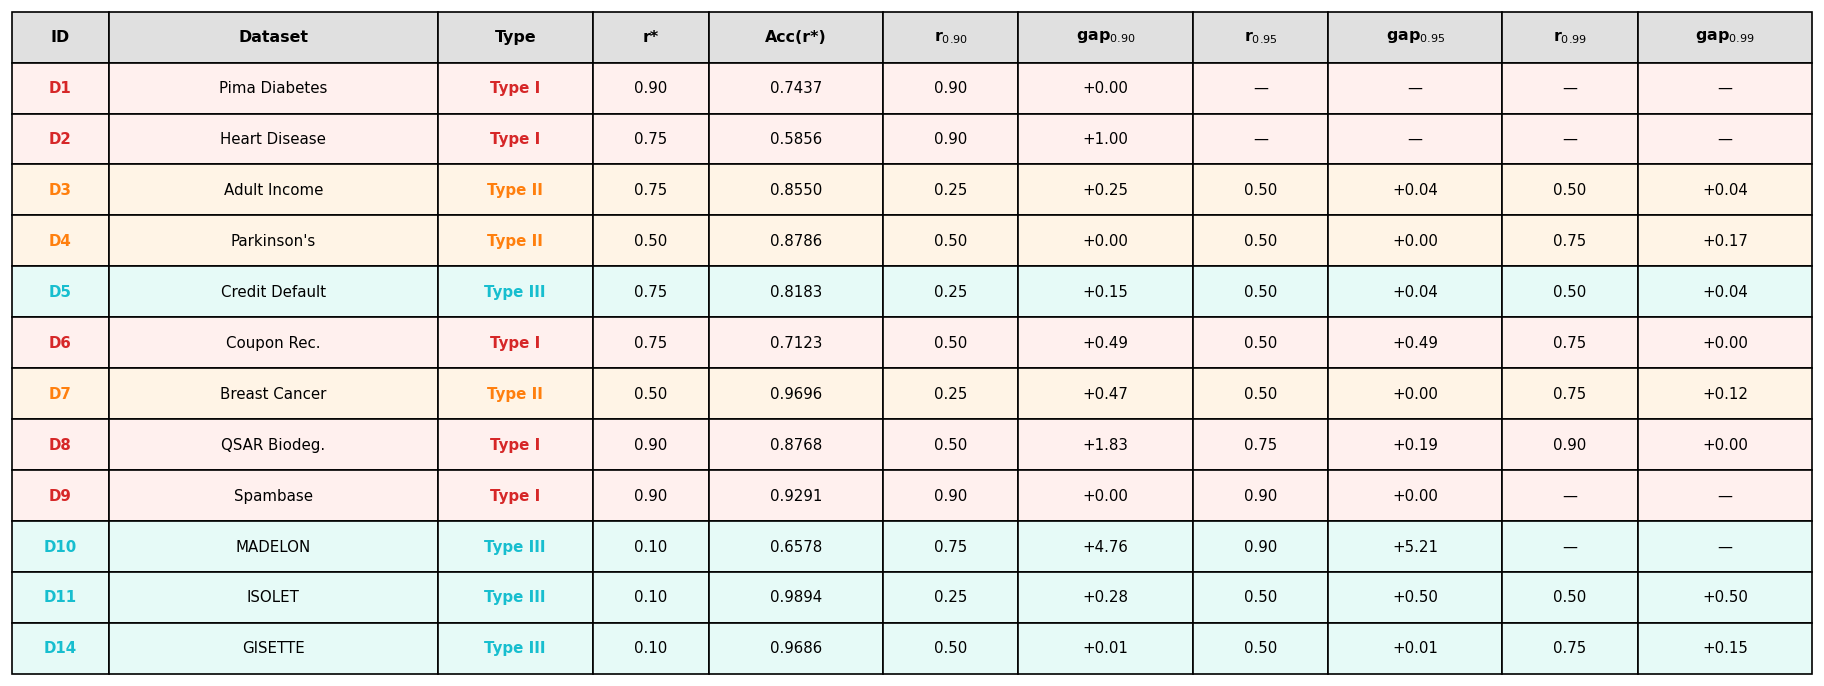

Saved: table13_variance_threshold.png


In [31]:
# =============================================================================
# TABLE 13 RENDER — Variance-threshold selection vs empirical optimum
# Requires: T13 (from Cell A)
# =============================================================================
import numpy as np, matplotlib.pyplot as plt

TYPE_OF = {"D1":"I","D2":"I","D6":"I","D8":"I","D9":"I",
           "D3":"II","D4":"II","D7":"II",
           "D5":"III","D10":"III","D11":"III","D14":"III"}
row_bg  = {"I":"#FFF0EE","II":"#FFF4E6","III":"#E6FAF7"}
txt_col = {"I":"#d62728","II":"#ff7f0e","III":"#17becf"}

def fr(v):  return "\u2014" if (v is None or (isinstance(v,float) and np.isnan(v))) else f"{v:.2f}"
def fg(v):  return "\u2014" if (v is None or (isinstance(v,float) and np.isnan(v))) else f"{v:+.2f}"

cells, colours = [], []
for _, r in T13.iterrows():
    t = TYPE_OF.get(r["ID"], "III")
    cells.append([r["ID"], r["Dataset"], f"Type {t}", fr(r['r*']), f"{r['Acc(r*)']:.4f}",
                  fr(r["r@90"]), fg(r["gap@90"]),
                  fr(r["r@95"]), fg(r["gap@95"]),
                  fr(r["r@99"]), fg(r["gap@99"])])
    colours.append([row_bg[t]] * 11)

cols = ["ID","Dataset","Type","r*","Acc(r*)",
        "r$_{0.90}$","gap$_{0.90}$","r$_{0.95}$","gap$_{0.95}$","r$_{0.99}$","gap$_{0.99}$"]

fig, ax = plt.subplots(figsize=(15, 6))
ax.set_position([0, 0.05, 1, 0.92]); ax.axis("off")
tb = ax.table(cellText=cells, colLabels=cols, cellLoc="center",
              loc="center", cellColours=colours, bbox=[0, 0, 1, 1])
tb.auto_set_font_size(False); tb.set_fontsize(9)

widths = [0.05,0.17,0.08,0.06,0.09,0.07,0.09,0.07,0.09,0.07,0.09]
for j, w in enumerate(widths):
    for i in range(len(cells) + 1):
        tb[i, j].set_width(w)

for j in range(len(cols)):
    tb[0, j].set_facecolor("#E0E0E0")
    tb[0, j].set_text_props(fontweight="bold", fontsize=9.5)

for i, r in enumerate(T13["ID"]):
    c = txt_col[TYPE_OF.get(r, "III")]
    tb[i+1, 0].set_text_props(color=c, fontweight="bold")
    tb[i+1, 2].set_text_props(color=c, fontweight="bold")

plt.savefig("table13_variance_threshold.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: table13_variance_threshold.png")